# <u>Treiber und Auswirkungen der Energiewende in Europa: <br> Eine datenbasierte Analyse von Strommärkten, erneuerbaren Energien und der Elektrifizierung von Mobilität und Wärme

# 1. Einleitung

## 1.1 Motivation und Projektziel

Die europäischen Energiesysteme befinden sich in einem tiefgreifenden Transformationsprozess. Der Ausbau erneuerbarer Energien sowie die zunehmende Elektrifizierung von Mobilität und Wärme verändern sowohl Stromerzeugung als auch Stromnachfrage.  
Ziel dieses Projekts ist es, mithilfe öffentlich verfügbarer Energiemarktdaten zentrale Treiber der Energiewende zu analysieren und mögliche Zusammenhänge zwischen:  
- Stromangebot: Ausbau der erneuerbaren Energien
- Stromnachfrage: Elektrifizierung von Mobilität und Wärme durch Elektroautos und Wärmepumpen
- Auswirkung: Entwicklung von Strompreisen und deren Volatilität<br>

in europäischen Ländern zu untersuchen.

Das Projekt liefert datenbasierte Einblicke in:  
- Unterschiede zwischen europäischen Energiemärkten
- zentrale Treiber der Energiewende
- mögliche Zusammenhänge zwischen Elektrifizierung und Strommarktentwicklung

## 1.2 Stakeholder

Die Ergebnisse können wertvolle Informationen für die folgenden Stakeholder liefern:  
- Unternehmen: z.B. Investitionsentscheidungen über Markteintritte in bestimmte Märkte
- Energieanalysten: Datengetriebene Informationen über die Marktstruktur des Strommarktes und die Energiewende
- Politische Entscheidungsträger: Informationen zur Änderung/Anpassung bzw. Neuerstellung von Regularien/Gesetzen

## 1.3 Fragestellungen:

Ziel der Analysen ist es, den Zusammenhang zwischen Energiewende und Strommarkt genauer zu untersuchen: 

Besteht ein Zusammenhang zwischen:
- der Erzeugung der erneuerbaren Energien (speziell variable erneuerbare Energien: Wind, Solar)
- der Elektrifizierung der Wirtschaft (Nutzung bzw. Nachfrage durch Wärmepumpen/Elektroautos) und
- der Entwicklung der Strompreise und deren Schwankungen?

Zur Bearbeitung der Fragestellung wird diese in 2 Teile getrennt. Es werden unabhängig voneinander Fragen der Marktdifferenzierung als auch Fragen des Einflusses der verschiedenen Technologien auf der Erzeugungs- als auch der Verbrauchsseite untersucht:

Im Bereich **Marktsegmentierung** werden folgende Fragen untersucht:
- Wie lassen sich die Strommärkte der verschiedenen Ländern in Cluster einteilen?
- Lassen sich Länder mit ähnlichen Transformationsmustern identifizieren?

Auf der **technologischen Seite** werden diese Fragestellungen betrachtet:
- Erzeugerseite: Gibt es einen Einfluss von erneuerbaren Energien / variablen erneuerbaren Energien auf den Strompreis und dessen Volatilität?
- Verbraucherseite: Gibt es einen Einfluss von Wärmepumpen / Elektroautos auf den Strompreis und dessen Volatilität?
- Ausgleich zwischen Erzeugung und Verbrauch: Gibt es einen Einfluss der Strompreisvolatilität auf den Batteriespeicherausbau?

## 1.4 Implikationen:

- Identifikation der Länder, welche die Transformation bereits erfolgreich durchgeführt haben: Diese Länder können als case-studies für die Länder dienen, welche noch am Beginn des Transformationsprozesses sind

- Zusammenhänge zwischen Stromerzeugung, Elektrifizierung von Wärme und Mobilität und dem Strommarkt: Dies kann Auswirkungen auf die weitere technische und regulatorische Gestaltung des Transformationsprozesses haben

- Wachstumspotential in den verschiedenen Sektoren der Energiewende: Dadurch lassen sich Länder und Märkte identifizieren, die attraktiv für Unternehmen und Investoren sind

# 2. Datenvorbereitung und -bereinigung

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import kurtosis, skew

from sqlalchemy import create_engine

import glob
import os
import math

!pip install pymysql
import pymysql

In [3]:
# Einstellung der Darstellung

# Erlaubt beliebig viele Spalten in der Breite anzuzeigen
pd.set_option('display.max_columns', None)

# Verhindert den automatischen Zeilenumbruch der Tabelle
pd.set_option('display.expand_frame_repr', False)

## 2.1 Datenquellen

**ENTSO-E: Strompreise**
- Day-ahead Strompreise
- EU ex. Malta, Zypern, inkl. Schweiz, Norwegen, Serbien, Montenegro, Nordmazedonien, Ukraine
- Monatlich, seit 2015
- Download als csv
- https://transparency.entsoe.eu/fileLibrary/fileBrowserMode?appState=%7B%22path%22%3A%22%2FTP_export%2FEnergyPrices_12.1.D_r3%2F%22%7D

**ENTSO-E: Stromerzeugung durch Windkraft- und Solaranlagen**
- Stromerzeugung nach Technologie (Kohle, Gas, Wind, PV u.v.m.)
- EU ex. Malta, Zypern, inkl. Schweiz, Norwegen, Serbien, Montenegro, Nordmazedonien, Ukraine
- Monatlich, seit 2015
- Download als csv
- https://transparency.entsoe.eu/fileLibrary/fileBrowserMode?appState=%7B%22path%22%3A%22%2FTP_export%2FAggregatedGenerationPerType_16.1.B_C_r3%2F%22%7D

**Eurostat: Elektrofahrzeuge**
- Bestand
- Alle EU-Länder inkl. diverser anderer europäische Länder 
- 2018 - 2024, Jahreswerte
- Download als csv
- https://ec.europa.eu/eurostat/databrowser/view/tran_r_elvehst/default/table?lang=en

**Eurostat: Wärmepumpen**
- Aus der Umwelt aufgenommene Wärmemenge in Terajoule
- Alle EU-Länder inkl. diverser anderer europäische Länder 
- 2015 - 2024, Jahreswerte
- Download als csv
- https://ec.europa.eu/eurostat/databrowser/view/nrg_ind_hpind/default/table?lang=en

Aus der Daten ergibt sich die erste Einschränkung: Da die Daten für Elektrofahrzeuge erst ab 2018 und bis 2024 verfügbar sind, muss die Analyse auf diesen Zeitraum eingeschränkt werden.

## 2.2 Generelles Vorgehen: Daten importieren, zusammen führen, Datenqualität überprüfen

- Laden der Daten in einen Data Frame (speziell bei Daten, die in mehreren csv-Dateien vorliegen)
- Prüfung auf Vollständigkeit (keine Datenlücken, Duplikate etc.)
- Prüfung, ob für alle Jahre alle Länder Daten gemeldet haben, oder teilweise Nullwerte gemeldet wurden
- Aggregation aller verschiedenen Datensätze auf einen einheitlichen zeitlichen und geographischen Rahmen
- Normierung von Wärmepumpen- und Elektroautodaten auf die Bevölkerung (zur besseren Vergleichbarkeit zwischen den Ländern)

### 2.2.1 Strompreise

In [4]:
# Die Strompreise liegen wie in Kapitel 2.1 beschrieben nach dem Download als einzelne csv-Datei pro Monat vor
# Damit ergeben sich für die 7 Jahre (2018-2024): 7 x 12 Monate = 84 Monats-Dateien
# Zuerst werden diese 84 Dateien in einen Data Frame geladen

# Pfad zu den 84 csv-Dateien

# BITTE HIER DEN DATEIPFAD ZU DEN HERUNTER GELADENEN CSV-DATEIEN EINFÜGEN
# path = xyz
all_files = glob.glob(os.path.join(path, "*"))

# Da die 84 Dateien insgesamt 428MB groß sind, werden gleich beim zusammen führen nur die relevanten Spalten behalten
keep_cols = ['DateTime(UTC)', 'AreaDisplayName', 'MapCode', 'ContractType', 'Price[Currency/MWh]', 'Currency']

# Umbenennung der relevanten Spalten
new_names = ['Date_Time', 'Land_Name', 'Land_Code', 'Contract_Type', 'Price', 'Currency']

li = []

for filename in all_files:
    # usecols=keep_cols sorgt dafür, dass nur diese Spalten eingelesen werden
    df = pd.read_csv(filename, sep='\t', encoding='utf-8', usecols=keep_cols)
    
    # Spalten direkt umbenennen
    df.columns = new_names
    
    li.append(df)

# Zusammenführen der vorgefilterten DataFrames
energy_prices_df = pd.concat(li, axis=0, ignore_index=True)

print("Zusammenführung abgeschlossen (optimiert).")
print(energy_prices_df.head())
print()

# Überprüfen des DataFrames: Anzahl der Zeilen, Datentypen
energy_prices_df.info()

Zusammenführung abgeschlossen (optimiert).
             Date_Time     Land_Name Land_Code Contract_Type  Price Currency
0  2018-01-01 00:00:00  Austria (AT)        AT     Day-ahead -20.00      EUR
1  2018-01-01 00:15:00  Austria (AT)        AT     Day-ahead -33.90      EUR
2  2018-01-01 00:30:00  Austria (AT)        AT     Day-ahead -26.81      EUR
3  2018-01-01 00:45:00  Austria (AT)        AT     Day-ahead -41.30      EUR
4  2018-01-01 01:00:00  Austria (AT)        AT     Day-ahead -20.00      EUR

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3247111 entries, 0 to 3247110
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Date_Time      object 
 1   Land_Name      object 
 2   Land_Code      object 
 3   Contract_Type  object 
 4   Price          float64
 5   Currency       object 
dtypes: float64(1), object(5)
memory usage: 148.6+ MB


In [5]:
# Optimierung der Datentypen: Date-Time
energy_prices_df['Date_Time'] = pd.to_datetime(energy_prices_df['Date_Time'])

In [6]:
# Überprüfen auf Duplikate
duplicates = energy_prices_df.duplicated().sum()
print(f"Gefundene Duplikate: {duplicates}")

Gefundene Duplikate: 34


In [7]:
# Anzeige der Duplikate
duplicate_rows = energy_prices_df[energy_prices_df.duplicated(keep=False)]

# Sortieren nach Zeitraum und Land, damit die Doppelgänger zum besseren Vergleich direkt untereinander stehen
print(duplicate_rows.sort_values(by=['Date_Time', 'Land_Code']).head())

                 Date_Time     Land_Name Land_Code Contract_Type  Price Currency
446843 2019-01-08 14:00:00  Austria (AT)        AT     Day-ahead   64.0      EUR
448133 2019-01-08 14:00:00  Austria (AT)        AT     Day-ahead   64.0      EUR
491769 2019-02-16 12:00:00         DE-LU     DE_LU     Day-ahead   36.0      EUR
493557 2019-02-16 12:00:00         DE-LU     DE_LU     Day-ahead   36.0      EUR
565898 2019-04-19 05:00:00         DE-LU     DE_LU     Day-ahead   40.5      EUR


In [8]:
# Duplikate entfernen: keep='first' behält den ersten Eintrag und löscht alle weiteren identischen Kopien
energy_prices_df.drop_duplicates(keep='first', inplace=True)

# Index zurücksetzen: Da durch das Löschen Lücken in den Zeilennummern entstehen, wird der Index neu erstellt
energy_prices_df.reset_index(drop=True, inplace=True)

In [9]:
# Untersuchung, ob alle Länder die gleiche zeitliche Aufösung haben: wie viele Datenpunkte hat jedes Land pro Jahr?

# Hilfs-Spalte für das Jahr erstellen
energy_prices_df['Year'] = energy_prices_df['Date_Time'].dt.year

# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix = energy_prices_df.pivot_table(index='Land_Code', 
                                            columns='Year', 
                                            values='Price', 
                                            aggfunc='count'
                                            ).fillna(0).astype(int)

print("Anzahl der Datenpunkte pro Land und Jahr energy_prices_df:")
print()
print(count_matrix)

Anzahl der Datenpunkte pro Land und Jahr energy_prices_df:

Year          2018   2019   2020   2021   2022   2023   2024
Land_Code                                                   
AT           28606  43796  43915  43792  43798  43796  43919
BE            8760   8760   8784   8760   8760   8760   8784
BG            8760   8760   8784   8760   8760   8760   8784
CH            8760   8760   8784   8760   8760   8760   8784
CZ            8760   8760   8784   8760   8760   8760   8784
DE_AT_LU      6550      0      0      0      0      0      0
DE_LU        10950  43796  43917  43799  43799  43799  43920
DK1           8760   8760   8784   8760   8760   8760   8784
DK2           8760   8760   8784   8760   8760   8760   8784
EE            8760   8760   8784   8760   8760   8760   8784
ES            8760   8760   8784   8760   8760   8760   8784
FI            8760   8760   8784   8760   8760   8760   8784
FR            8760   8760   8784   8760   8760   8760   8784
GB            8760   8736

Die Länder weisen unterschiedlich viele Datenpunkte auf:  
- 8784/8760 Datenpunkte => Strompreis-reporting im Stundentakt (Schaltjahr/kein Schaltjahr)  
- 43915/43796 Datenpunkte => Strompreis-reporting im 15-Minuten-Takt (Schaltjahr/kein Schaltjahr)

**Zudem ergeben sich die folgenden Erkenntnisse:**  
- DE_AT_LU: die Gebotszone wurde ab 2019 beendet
- DE_LU: Deutschland und Luxemburg sind in einer Gebotszone zusammen gefasst, da diese nicht zu trennen ist müssen bei allen zukünftigen Datensätzen und Analysen diese beiden Länder aufaddiert und zusammen betrachtet werden
- GB: ist durch den EU-Austritt seit 2021 nicht mehr im Datensatz enthalten
- IT: mehrere Gebotszonen (Brindisi, Calabria, Foggia, Priolo, Rossano) wurden zu unterschiedlichen Zeitpunkten mit anderen Gebotszonen zusammen geführt oder neu eingeführt
- NO2NSL: Für den North Sea Link zwischen Norwegen und Großbritannien stehen Daten erst ab 2021 zur Verfügung

In [13]:
# Überprüfung auf fehlende Werte in den Spalten
print("Fehlende Werte pro Spalte:")
print()
print(energy_prices_df.isnull().sum())

Fehlende Werte pro Spalte:

Date_Time        0
Land_Name        0
Land_Code        0
Contract_Type    0
Price            0
Currency         0
Year             0
dtype: int64


Es fehlen keine Werte in den Daten, die Datenqualität ist also sehr hoch.

GB, ME, MK, UA_BEI/UA_IPS sowie DE_AT_LU werden aufgrund der lückenhaften Datenlage aus dem Datensatz entfernt.

Nur die Gebotszone DE_LU und AT haben die Strompreise im 15-Minuten-Takt berichtet, alle anderen Länder und Gebotszonen im Stundentakt.  
Zur besseren Vergleichbarkeit werden daher DE_LU und AT ebenfalls auf Stundenwerte aggregiert.

In [14]:
# Unerwünschte Länder entfernen
drop_list = ['GB', 'ME', 'MK', 'UA_BEI', 'UA_IPS', 'DE_AT_LU']
# Arbeit mit einer Kopie, um das Original nicht zu korrumpieren
temp_df = energy_prices_df[~energy_prices_df['Land_Code'].isin(drop_list)].copy()

# Check: Ist Date_Time noch eine Spalte? Wenn ja, umwandeln und als Index setzen
if 'Date_Time' in temp_df.columns:
    temp_df['Date_Time'] = pd.to_datetime(temp_df['Date_Time'])
    temp_df.set_index('Date_Time', inplace=True)

# Aggregation auf Stundenwerte (1h): .resample('h') bezieht sich automatisch auf den Datetime-Index
energy_prices_hourly_df = temp_df.groupby('Land_Code')['Price'].resample('h').mean().reset_index()

# Spalte Year wieder auf Date_Time formatieren
energy_prices_hourly_df['Year'] = energy_prices_hourly_df['Date_Time'].dt.year

print("Aggregation erfolgreich abgeschlossen.")
print(f"Neue Zeilenanzahl: {len(energy_prices_hourly_df)}")

Aggregation erfolgreich abgeschlossen.
Neue Zeilenanzahl: 2687065


In [15]:
# Überprüfung der Aggregation auf Stundenwerte
# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix_2 = energy_prices_hourly_df.pivot_table(index='Land_Code', 
                                                     columns='Year', 
                                                     values='Price', 
                                                     aggfunc='count'
                                                     ).fillna(0).astype(int)

print("Anzahl der Datenpunkte pro Land und Jahr energy_prices_hourly_df:")
print()
print(count_matrix_2)

Anzahl der Datenpunkte pro Land und Jahr energy_prices_hourly_df:

Year         2018  2019  2020  2021  2022  2023  2024
Land_Code                                            
AT           8760  8760  8784  8760  8760  8760  8784
BE           8760  8760  8784  8760  8760  8760  8784
BG           8760  8760  8784  8760  8760  8760  8784
CH           8760  8760  8784  8760  8760  8760  8784
CZ           8760  8760  8784  8760  8760  8760  8784
DE_LU        2210  8760  8784  8760  8760  8760  8784
DK1          8760  8760  8784  8760  8760  8760  8784
DK2          8760  8760  8784  8760  8760  8760  8784
EE           8760  8760  8784  8760  8760  8760  8784
ES           8760  8760  8784  8760  8760  8760  8784
FI           8760  8760  8784  8760  8760  8760  8784
FR           8760  8760  8784  8760  8760  8760  8784
GR           8760  8760  8784  8760  8760  8760  8784
HR           8760  8760  8784  8760  8760  8760  8784
HU           8760  8760  8784  8760  8760  8760  8784
IE_SEM       87

Sämtliche Gebotszonen weisen nun einheitlich Stundenwerte auf.

Für einen späteren Vergleich müssen jedoch die einzelnen Länder-Gebotszonen auf einen einzigen Länderwert aggregiert werden.  
Da ein einfacher Mittelwert die Größe der Gebotszonen außer Acht lassen würde, müssen die Mittelwerte anhand der tatsächlichen Last in der Gebotszone gewichtet ermittelt werden.  
Hierzu wird ebenfalls von ENTSO-E analog zu den Strompreis-Datensätzen die Datensätze zur Last herunter geladen und aufbereitet.

In [16]:
# Die Daten zur Stromlast können ebenso wie die Strompreise als monatliche csv-Dateien herunter geladen werden
# Damit ergeben sich für die 7 Jahre (2018-2024): 7 x 12 Monate = 84 Monats-Dateien
# Zuerst werden diese 84 Dateien in einen Data Frame geladen

# Pfad zu den 84 csv-Dateien

# BITTE HIER DEN DATEIPFAD ZU DEN HERUNTER GELADENEN CSV-DATEIEN EINFÜGEN
# path = xyz
all_files = glob.glob(os.path.join(path, "*"))

# Da die 84 Dateien insgesamt 601MB groß sind, werden gleich beim zusammen führen nur die relevanten Spalten behalten
keep_cols = ['DateTime(UTC)', 'AreaDisplayName', 'AreaMapCode', 'TotalLoad[MW]']

# Umbenennung der relevanten Spalten
new_names = ['Date_Time', 'Land_Name', 'Land_Code', 'Total_Load']

li = []

for filename in all_files:
    # usecols sorgt dafür, dass nur diese Spalten eingelesen werden
    df = pd.read_csv(filename, sep='\t', encoding='utf-8', usecols=keep_cols)
    
    # Spalten direkt umbenennen
    df.columns = new_names
    
    li.append(df)

# Zusammenführen der vorgefilterten DataFrames
load_df = pd.concat(li, axis=0, ignore_index=True)

print("Zusammenführung abgeschlossen (optimiert).")
print(load_df.head())
print()

# Überprüfen des DataFrames: Anzahl der Zeilen, Datentypen
load_df.info()

Zusammenführung abgeschlossen (optimiert).
             Date_Time     Land_Name Land_Code  Total_Load
0  2018-01-01 00:00:00  Austria (AT)        AT      6060.4
1  2018-01-01 00:15:00  Austria (AT)        AT      5971.2
2  2018-01-01 00:30:00  Austria (AT)        AT      5875.2
3  2018-01-01 00:45:00  Austria (AT)        AT      5830.8
4  2018-01-01 01:00:00  Austria (AT)        AT      5872.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6526826 entries, 0 to 6526825
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Date_Time   object 
 1   Land_Name   object 
 2   Land_Code   object 
 3   Total_Load  float64
dtypes: float64(1), object(3)
memory usage: 199.2+ MB


In [17]:
# Optimierung der Datentypen: Date-Time
load_df['Date_Time'] = pd.to_datetime(load_df['Date_Time'])

In [18]:
# Überprüfen auf Duplikate
duplicates = load_df.duplicated().sum()
print(f"Gefundene Duplikate: {duplicates}")

Gefundene Duplikate: 0


In [19]:
# Untersuchung, ob alle Länder die gleiche zeitliche Aufösung haben: wie viele Datenpunkte hat jedes Land pro Jahr?

# Hilfs-Spalte für das Jahr erstellen
load_df['Year'] = load_df['Date_Time'].dt.year

# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix_3 = load_df.pivot_table(index='Land_Code', 
                                     columns='Year', 
                                     values='Total_Load', 
                                     aggfunc='count'
                                     ).fillna(0).astype(int)

pd.set_option('display.max_rows', None)

print("Anzahl der Datenpunkte pro Land und Jahr load_df:")
print()
print(count_matrix_3)

Anzahl der Datenpunkte pro Land und Jahr load_df:

Year            2018   2019   2020   2021   2022   2023   2024
Land_Code                                                     
AL                 0      0      0   5956  34364  34460  35136
AT             35040  35040  35136  35040  35040  35040  35136
BA              8760   8760   8784   8760   8747   8743   8659
BE             35040  35040  35136  35040  35040  35040  35136
BG              8760   8760   8784   8760   8760   8760   8784
CH              8760   8760   8784   8760   8760   8760   8784
CY             17152  14969  15280  17084   7590      2   2234
CZ              8753   8756   8784   8760   8760   8760  22104
DE             35040  35040  35136  35040  35040  35040  35136
DE_50HzT       35040  35040  35136  35040  35040  35040  35136
DE_AT_LU       26180      0      0      0      0      0      0
DE_Amprion     35040  35040  35136  35040  35040  35040  35136
DE_LU           8824  35040  35136  35040  35040  35040  35136
DE_T

In [20]:
# Überprüfung auf fehlende Werte in den Spalten
print("Fehlende Werte pro Spalte:")
print()
print(load_df.isnull().sum())

Fehlende Werte pro Spalte:

Date_Time     0
Land_Name     0
Land_Code     0
Total_Load    0
Year          0
dtype: int64


Zunächst werden alle Länder und Gebotszonen entfernt, die nicht in der Strompreisliste vorhanden sind.  
Zusätzlich wird die Gebotszone DE_LU durch Addition von DE und LU erzeugt.

In [21]:
# Extrahieren der Liste der Ländercodes aus dem Strompreis-df (energy_prices_hourly_df)
target_codes = energy_prices_hourly_df['Land_Code'].unique().tolist()


# DE_LU erzeugen
# Extrahieren von DE und LU
de_load = load_df[load_df['Land_Code'] == 'DE'].copy()
lu_load = load_df[load_df['Land_Code'] == 'LU'].copy()

# Zusammenführen von DE und LU in den df de_lu_combined
de_lu_combined = pd.merge(de_load, lu_load, on='Date_Time', suffixes=('_de', '_lu'))

# Aufsummieren von Total_Load_de und Total_load_lu
de_lu_combined['Total_Load'] = de_lu_combined['Total_Load_de'] + de_lu_combined['Total_Load_lu']

# Benennen mit DE_LU bzw. Germany/Luxembourg
de_lu_combined['Land_Code'] = 'DE_LU'
de_lu_combined['Land_Name'] = 'Germany/Luxembourg'


# Nur die relevanten Spalten behalten
de_lu_final = de_lu_combined[['Date_Time', 'Land_Name', 'Land_Code', 'Total_Load']]

# Den originalen load_df nach den target_codes filtern und die neue DE_LU Zone (de_lu_final) hinzufügen
load_filtered_df = load_df[load_df['Land_Code'].isin(target_codes)].copy()
load_filtered_df = pd.concat([load_filtered_df, de_lu_final], ignore_index=True)

Danach werden die Werte wie in der Lastliste ebenfalls auf Stundenwerte aggregiert:

In [22]:
# Sicherstellen, dass Date_Time ein Datetime-Objekt ist (nur wenn Spalte existiert)
if 'Date_Time' in load_filtered_df.columns:
    load_filtered_df['Date_Time'] = pd.to_datetime(load_filtered_df['Date_Time'])
    # Setzen des Index NICHT permanent mit inplace=True, um den KeyError bei wiederholter Ausführung zu vermeiden.
    temp_df = load_filtered_df.set_index('Date_Time')
else:
    # Nutzung von Date_Time als Index, falls schon vorhanden
    temp_df = load_filtered_df

# Aggregation auf Stundenbasis: gruppieren nach Land_Code und Resampling auf den Index
load_filtered_hourly_df = (temp_df.groupby('Land_Code')['Total_Load'].resample('h').mean().reset_index())

# Die 'Year' Spalte für die spätere Pivot-Analyse erstellen
load_filtered_hourly_df['Year'] = load_filtered_hourly_df['Date_Time'].dt.year

In [23]:
# Überprüfung
# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix_4 = load_filtered_hourly_df.pivot_table(index='Land_Code', 
                                                     columns='Year', 
                                                     values='Total_Load', 
                                                     aggfunc='count'
                                                     ).fillna(0).astype(int)

pd.set_option('display.max_rows', None)

print("Anzahl der Datenpunkte pro Land und Jahr load_filtered_hourly_df:")
print()
print(count_matrix_4)

Anzahl der Datenpunkte pro Land und Jahr load_filtered_hourly_df:

Year         2018  2019  2020  2021  2022  2023  2024
Land_Code                                            
AT           8760  8760  8784  8760  8760  8760  8784
BE           8760  8760  8784  8760  8760  8760  8784
BG           8760  8760  8784  8760  8760  8760  8784
CH           8760  8760  8784  8760  8760  8760  8784
CZ           8753  8756  8784  8760  8760  8760  8784
DE_LU        8752  8760  8784  8760  8760  8760  8784
DK1          8760  8760  8784  8760  8760  8760  8784
DK2          8760  8760  8784  8760  8760  8760  8784
EE           8628  8760  8784  8760  8760  8760  8784
ES           8758  8760  8784  8760  8760  8760  8784
FI           8757  8760  8784  8760  8760  8760  8784
FR           8743  8752  8782  8751  8739  8755  8784
GR           8760  8760  8784  8760  8760  8760  8783
HR           8760  8760  8784  8760  8760  8760  8784
HU           8760  8760  8784  8760  8760  8758  8784
IE_SEM       87

In [24]:
# Überprüfung: sind alle Ländercodes von der Strompreisliste in der Lastliste?
price_codes = set(energy_prices_hourly_df['Land_Code'].unique())
load_codes = set(load_filtered_hourly_df['Land_Code'].unique())

print(f"Codes nur in Strompreise: {price_codes - load_codes}")
print(f"Codes nur in Last:        {load_codes - price_codes}")
print(f"Gemeinsame Codes:         {len(price_codes.intersection(load_codes))}")

Codes nur in Strompreise: {'IT-SACODC', 'IT-Rossano', 'IT-Foggia', 'NO2NSL', 'IT-Priolo', 'IT-SACOAC', 'IT-Brindisi'}
Codes nur in Last:        set()
Gemeinsame Codes:         41


Die sieben Gebotszonenen (6 aus Italien, 1 aus Norwegen), die zwar in der Strompreisliste vorhanden sind, nicht aber in der Lastliste, müssen entfernt werden:

In [25]:
# Die Schnittmenge der Land_Codes bestimmen
common_codes = set(energy_prices_hourly_df['Land_Code'].unique()).intersection(set(load_filtered_hourly_df['Land_Code'].unique()))

# Die 7 Gebotszonen aus der Strompreisliste filtern
energy_prices_cleaned_df = energy_prices_hourly_df[energy_prices_hourly_df['Land_Code'].isin(common_codes)].copy()

print(f"Bereinigung abgeschlossen. Verbleibende Zonen: {len(energy_prices_cleaned_df['Land_Code'].unique())}")

Bereinigung abgeschlossen. Verbleibende Zonen: 41


In [26]:
# Überprüfung: sind alle Ländercodes von der Strompreisliste in der Lastliste?
price_codes = set(energy_prices_cleaned_df['Land_Code'].unique())
load_codes = set(load_filtered_hourly_df['Land_Code'].unique())

print(f"Codes nur in Strompreise: {price_codes - load_codes}")
print(f"Codes nur in Last:        {load_codes - price_codes}")
print(f"Gemeinsame Codes:         {len(price_codes.intersection(load_codes))}")

Codes nur in Strompreise: set()
Codes nur in Last:        set()
Gemeinsame Codes:         41


Die sieben Gebotszonen wurden erfolgreich aus der Strompreisliste entfernt.

Nun erfolgt die Skalierung der Gebotszonen-Strompreise aus der gefilterten und bereinigten Strompreisliste auf einen einzigen Landeswert:

In [27]:
# Mapping der Unterzonen auf das Haupt-Länderkürzel
# Dictionary der zusammen zu legenden Länder
zone_to_main_code = {
    'IT-NORTH': 'IT', 'IT-SOUTH': 'IT', 'IT-CNORTH': 'IT', 'IT-CSOUTH': 'IT', 'IT-Sardinia': 'IT', 'IT-Sicily': 'IT', 'IT-Calabria': 'IT',
    'NO1': 'NO', 'NO2': 'NO', 'NO3': 'NO', 'NO4': 'NO', 'NO5': 'NO',
    'SE1': 'SE', 'SE2': 'SE', 'SE3': 'SE', 'SE4': 'SE',
    'DK1': 'DK', 'DK2': 'DK',
    'IE_SEM': 'IE'
}

# Funktionsdefinition: Anhand des Länder-Subcodes (z.B. IT-NORTH) wird das Länder-Hauptkürzel (in diesem Fall IT) zurückgegeben, für alle nicht in in zone_to_main_code aufgeführten Länder wird weiterhin das normale Haupt-Länderkürzel verwendet
def get_main_code(code):
    return zone_to_main_code.get(code, code)

energy_prices_cleaned_df['Main_Code'] = energy_prices_cleaned_df['Land_Code'].apply(get_main_code)
load_filtered_hourly_df['Main_Code'] = load_filtered_hourly_df['Land_Code'].apply(get_main_code)

In [28]:
# Vor dem Merge: Umwandeln in Kategorien um RAM zu sparen
energy_prices_cleaned_df['Land_Code'] = energy_prices_cleaned_df['Land_Code'].astype('category')
energy_prices_cleaned_df['Main_Code'] = energy_prices_cleaned_df['Main_Code'].astype('category')
load_filtered_hourly_df['Land_Code'] = load_filtered_hourly_df['Land_Code'].astype('category')
load_filtered_hourly_df['Main_Code'] = load_filtered_hourly_df['Main_Code'].astype('category')

In [29]:
# Lastgewichtung berechnen
# Merge auf Zonen-Ebene
weighted_prep = pd.merge(
    energy_prices_cleaned_df[['Date_Time', 'Land_Code', 'Main_Code', 'Price']],
    load_filtered_hourly_df[['Date_Time', 'Land_Code', 'Total_Load']],
    on=['Date_Time', 'Land_Code'],
    how='inner'
)

# Hilfswert für die Gewichtung
weighted_prep['Price_x_Load'] = weighted_prep['Price'] * weighted_prep['Total_Load']

# Aggregation auf Länder-Haupt-Kürzel
energy_prices_final_df = weighted_prep.groupby(['Date_Time', 'Main_Code'], observed=True).agg({
    'Price_x_Load': 'sum',
    'Total_Load': 'sum'
}).reset_index()

# Lastgewichteter Preis
energy_prices_final_df['Weighted_Price'] = energy_prices_final_df['Price_x_Load'] / energy_prices_final_df['Total_Load']

# Spalten-Finish
energy_prices_final_df.rename(columns={'Main_Code': 'Land_Code', 'Total_Load': 'Actual_Load'}, inplace=True)
energy_prices_final_df['Year'] = energy_prices_final_df['Date_Time'].dt.year

print("Skalierung auf Basis der gemeinsamen Codes erfolgreich.")
print()
energy_prices_final_df.head()

Skalierung auf Basis der gemeinsamen Codes erfolgreich.



,Date_Time,Land_Code,Price_x_Load,Actual_Load,Weighted_Price,Year
0,2018-01-01,AT,-181014.03600,5934.4000,-30.5025,2018
1,2018-01-01,BE,38600.84175,8143.6375,4.7400,2018
2,2018-01-01,BG,71357.50000,3910.0000,18.2500,2018
3,2018-01-01,CH,228586.87320,7354.7900,31.0800,2018
4,2018-01-01,CZ,-104401.77000,5494.8300,-19.0000,2018


In [30]:
# Überprüfung
# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix_5 = energy_prices_final_df.pivot_table(index='Land_Code', 
                                                    columns='Year', 
                                                    values='Weighted_Price', 
                                                    aggfunc='count'
                                                    ).fillna(0).astype(int)

pd.set_option('display.max_rows', None)

print("Anzahl der Datenpunkte pro Land und Jahr energy_prices_final_df:")
print()
print(count_matrix_5)

Anzahl der Datenpunkte pro Land und Jahr energy_prices_final_df:

Year       2018  2019  2020  2021  2022  2023  2024
Land_Code                                          
AT         8760  8760  8784  8760  8760  8760  8784
BE         8760  8760  8784  8760  8760  8760  8784
BG         8760  8760  8784  8760  8760  8760  8784
CH         8760  8760  8784  8760  8760  8760  8784
CZ         8753  8756  8784  8760  8760  8760  8784
DE_LU      2207  8760  8784  8760  8760  8760  8784
DK         8760  8760  8784  8760  8760  8760  8784
EE         8628  8760  8784  8760  8760  8760  8784
ES         8758  8760  8784  8760  8760  8760  8784
FI         8757  8760  8784  8760  8760  8760  8784
FR         8743  8752  8782  8751  8739  8755  8784
GR         8760  8760  8784  8760  8760  8760  8783
HR         8760  8760  8784  8760  8760  8760  8784
HU         8760  8760  8784  8760  8760  8758  8784
IE         8751  8685  8616  8379  8261  7069  8488
IT         8760  8760  8784  8760  8760  8760  878

C:\Users\Matthias_unterwegs\AppData\Local\Temp\ipykernel_20604\2607746992.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_matrix_5 = energy_prices_final_df.pivot_table(index='Land_Code',


**Zusammenfassung:**  

Damit ist der Import, die Bereinigung (fehlende Werte) und Aufbereitung (Aggregation auf Stundenwerte, Reduktion der Gebotszonen auf ein einziges Länderkürzel) der Strompreisdaten abgeschlossen.

### 2.2.2 Stromerzeugungsleistung

In [31]:
# Die Daten zur Stromerzeugung nach Erzeugungstyp liegen wie in Kapitel 2.1 beschrieben nach dem Download als einzelne csv-Datei pro Monat vor
# Damit ergeben sich für die 7 Jahre (2018-2024): 7 x 12 Monate = 84 Monats-Dateien
# Zuerst werden diese 84 Dateien in einen Data Frame geladen

# Pfad zu den 84 csv-Dateien

# BITTE HIER DEN DATEIPFAD ZU DEN HERUNTER GELADENEN CSV-DATEIEN EINFÜGEN
# path = xyz
all_files = glob.glob(os.path.join(path, "*"))

# Da die 84 Dateien insgesamt 6,68GB groß sind, werden gleich beim zusammen führen nur die relevanten Spalten behalten
keep_cols = ['DateTime(UTC)', 'AreaDisplayName', 'AreaMapCode', 'ProductionType', 'ActualGenerationOutput[MW]']

# Umbenennung der relevanten Spalten
new_names = ['Date_Time', 'Land_Name', 'Land_Code', 'Production_Type', 'Generation_Output']

li = []

for filename in all_files:
    # usecols sorgt dafür, dass nur diese Spalten eingelesen werden
    df = pd.read_csv(filename, sep='\t', encoding='utf-8', usecols=keep_cols)

    # Spalten direkt umbenennen
    df.columns = new_names
    
    # Speicher sparen durch Kategorien
    df['Production_Type'] = df['Production_Type'].astype('category')
    df['Land_Code'] = df['Land_Code'].astype('category')
     
    li.append(df)

# Zusammenführen der DataFrames
generation_per_type_df = pd.concat(li, axis=0, ignore_index=True)

print("Zusammenführung abgeschlossen (optimiert).")
print()
print(generation_per_type_df.head())
print()

# Überprüfen des DataFrames: Anzahl der Zeilen, Datentypen
generation_per_type_df.info()

Zusammenführung abgeschlossen (optimiert).

             Date_Time     Land_Name Land_Code Production_Type  Generation_Output
0  2018-01-01 00:00:00  Austria (AT)        AT         Biomass              316.0
1  2018-01-01 00:15:00  Austria (AT)        AT         Biomass              316.0
2  2018-01-01 00:30:00  Austria (AT)        AT         Biomass              316.0
3  2018-01-01 00:45:00  Austria (AT)        AT         Biomass              316.0
4  2018-01-01 01:00:00  Austria (AT)        AT         Biomass              316.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63505858 entries, 0 to 63505857
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date_Time          object 
 1   Land_Name          object 
 2   Land_Code          object 
 3   Production_Type    object 
 4   Generation_Output  float64
dtypes: float64(1), object(4)
memory usage: 2.4+ GB


In [32]:
# Optimierung der Datentypen: Date-Time
generation_per_type_df['Date_Time'] = pd.to_datetime(generation_per_type_df['Date_Time'])

In [33]:
# Überprüfen auf Duplikate
duplicates = generation_per_type_df.duplicated().sum()
print(f"Gefundene Duplikate: {duplicates}")

Gefundene Duplikate: 0


In [34]:
# Untersuchung, ob alle Länder die gleiche zeitliche Aufösung haben: wie viele Datenpunkte hat jedes Land pro Jahr?

# Hilfs-Spalte für das Jahr erstellen
generation_per_type_df['Year'] = generation_per_type_df['Date_Time'].dt.year

# Pivot-Tabelle erstellen: Zeilen = Land_Code, Spalten = Jahr, Werte = Anzahl der Einträge
count_matrix_6 = generation_per_type_df.pivot_table(index='Land_Code', 
                                                    columns='Year', 
                                                    values='Generation_Output',
                                                    aggfunc='count'
                                                    ).fillna(0).astype(int)

print("Anzahl der Datenpunkte pro Land und Jahr generation_per_type_df:")
print()
print(count_matrix_6)

Anzahl der Datenpunkte pro Land und Jahr generation_per_type_df:

Year             2018    2019    2020    2021    2022    2023    2024
Land_Code                                                            
AT             455520  455520  456768  455520  455520  455520  456768
BA              30498   35112   35028   40246   44069   52355   59353
BE             100127   95607   91357   90583   91071   91456   90835
BG              96360   96360   96024   96349   96200   96360   96624
CH              52560   52560   52704   52560   52560   52560   52704
CY              34278   29890   30561   34172   15191       0       0
CZ             131359  131374  131760  131400  131400  131400  331560
DE             595296  581560  562176  560640  560644  570712  562176
DE_50HzT       490560  490560  491904  490560  490560  490560  491904
DE_AT_LU       445016       0       0       0       0       0       0
DE_Amprion     525216  511513  505736  525600  525604  535672  527040
DE_LU          150280  5

Entfernung der Länderkürzel, die nicht in der Strompreisliste enthalten sind, Aggregation auf Stundenwerte:

In [35]:
# Länderliste aus den Preisdaten
country_codes_energy_prices = energy_prices_final_df['Land_Code'].unique()

# Filtern auf Länderkürzel aus der Strompreisliste
generation_per_type_filtered_df = generation_per_type_df[generation_per_type_df['Land_Code'].isin(country_codes_energy_prices)].copy()

# Aggregation auf Stundenbasis pro Erzeugungsart
# Zeitstempel auf volle Stunden abrunden
generation_per_type_filtered_df['Date_Time'] = generation_per_type_filtered_df['Date_Time'].dt.floor('h')
                                                                                                     
# Nutzen von .mean(), um von 15-Minuten (falls vorhanden) auf 1-Stunde zu kommen
generation_per_type_filtered_hourly_df = (
    generation_per_type_filtered_df
    .groupby(['Date_Time', 'Land_Code', 'Production_Type'], observed=True)
    .agg({'Generation_Output': 'mean'})
    .reset_index()
)

# Spaltennamen vereinheitlichen & Jahr ergänzen
generation_per_type_filtered_hourly_df['Year'] = generation_per_type_filtered_hourly_df['Date_Time'].dt.year

print(f"Aggregation fertig.")
print(f"Anzahl der Zeilen im neuen Set: {len(generation_per_type_filtered_hourly_df)}")

Aggregation fertig.
Anzahl der Zeilen im neuen Set: 17116240


**Aggregation der Erzeugungsarten:**  
- Gesamterzeugung
- Erzeugung erneuerbare Energien (RE: renewable energy => Biomasse, Geothermie, Wasserkraft u.a.)
- Erzeugung variable erneuerbare Energien (VRE: variable renewable energy => Solar, Wind onshore/offshore)
- Solar, Wind onshore, Wind offshore einzeln

In [36]:
# Listen definieren
# re = renewable energy (im Folgenden immer mit RE abgekürzt): alle erneuerbare Energien ohne Wind und Solar 
re_all = ['Biomass', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Other renewable', 'Waste', 'Marine']

# vre = variable renewable energy (im Folgenden immer mit VRE abgekürzt): Wind offshore/onshore, Solar
vre_all = ['Wind Onshore', 'Wind Offshore', 'Solar'] 

# Kopie erstellen
gen_df = generation_per_type_filtered_hourly_df.copy()


# Erstellung der Hilfsspalten für RE, VRE, Solar, Wind onshore und Wind offshore und befüllen mit den Werten
gen_df['RE_Total'] = 0.0
gen_df.loc[gen_df['Production_Type'].isin(re_all), 'RE_Total'] = gen_df['Generation_Output']

gen_df['VRE_Total'] = 0.0
gen_df.loc[gen_df['Production_Type'].isin(vre_all), 'VRE_Total'] = gen_df['Generation_Output']

gen_df['Solar_Val'] = 0.0
gen_df.loc[gen_df['Production_Type'] == 'Solar', 'Solar_Val'] = gen_df['Generation_Output']

gen_df['Wind_Onshore_Val'] = 0.0
gen_df.loc[gen_df['Production_Type'] == 'Wind Onshore', 'Wind_Onshore_Val'] = gen_df['Generation_Output']

gen_df['Wind_Offshore_Val'] = 0.0
gen_df.loc[gen_df['Production_Type'] == 'Wind Offshore', 'Wind_Offshore_Val'] = gen_df['Generation_Output']


# Aggregation auf Land und Zeitstempel
generation_filtered_df = gen_df.groupby(['Land_Code', 'Date_Time'], observed=True).agg({
    'Generation_Output': 'sum',
    'RE_Total': 'sum',
    'VRE_Total': 'sum',
    'Solar_Val': 'sum',
    'Wind_Onshore_Val': 'sum',
    'Wind_Offshore_Val': 'sum'
}).reset_index()

# Umbenennen der Spalten
generation_filtered_df.columns = [
    'Land_Code',
    'Date_Time', 
    'Gen_Total_MW', 
    'Gen_RE_Total_MW', 
    'Gen_VRE_Total_MW', 
    'Gen_Solar_MW', 
    'Gen_Wind_Onshore_MW', 
    'Gen_Wind_Offshore_MW'
]

# Jahresspalte für Matrixdarstellung
generation_filtered_df['Year'] = generation_filtered_df['Date_Time'].dt.year

# Anteile berechnen
generation_filtered_df['RE_Share_Pct']      = (generation_filtered_df['Gen_RE_Total_MW']      / generation_filtered_df['Gen_Total_MW']) * 100
generation_filtered_df['VRE_Share_Pct']     = (generation_filtered_df['Gen_VRE_Total_MW']     / generation_filtered_df['Gen_Total_MW']) * 100
generation_filtered_df['Solar_Pct']         = (generation_filtered_df['Gen_Solar_MW']         / generation_filtered_df['Gen_Total_MW']) * 100
generation_filtered_df['Wind_Onshore_Pct']  = (generation_filtered_df['Gen_Wind_Onshore_MW']  / generation_filtered_df['Gen_Total_MW']) * 100
generation_filtered_df['Wind_Offshore_Pct'] = (generation_filtered_df['Gen_Wind_Offshore_MW'] / generation_filtered_df['Gen_Total_MW']) * 100

generation_filtered_df.fillna(0, inplace=True)

print("Zusammenfassung abgeschlossen.")
print()
print(generation_filtered_df.head())

Zusammenfassung abgeschlossen.

  Land_Code           Date_Time  Gen_Total_MW  Gen_RE_Total_MW  Gen_VRE_Total_MW  Gen_Solar_MW  Gen_Wind_Onshore_MW  Gen_Wind_Offshore_MW  Year  RE_Share_Pct  VRE_Share_Pct  Solar_Pct  Wind_Onshore_Pct  Wind_Offshore_Pct
0        AT 2018-01-01 00:00:00     4837.2575          3760.97          832.3875           0.0             832.3875                   0.0  2018     77.750047      17.207839        0.0         17.207839                0.0
1        AT 2018-01-01 01:00:00     4859.7300          3692.17          926.4600           0.0             926.4600                   0.0  2018     75.974797      19.064022        0.0         19.064022                0.0
2        AT 2018-01-01 02:00:00     4515.6150          3583.47          691.5450           0.0             691.5450                   0.0  2018     79.357297      15.314525        0.0         15.314525                0.0
3        AT 2018-01-01 03:00:00     4273.2850          3576.47          453.3150    

In [37]:
# Überprüfung
final_check_matrix = generation_filtered_df.pivot_table(index='Land_Code', 
                                                        columns='Year', 
                                                        values='Date_Time',
                                                        aggfunc='count'
                                                        ).fillna(0).astype(int)

print("Anzahl der Stunden pro Land und Jahr - generation_filtered_df:")
print()
print(final_check_matrix)

Anzahl der Stunden pro Land und Jahr - generation_filtered_df:

Year       2018  2019  2020  2021  2022  2023  2024
Land_Code                                          
AT         8760  8760  8784  8760  8760  8760  8784
BE         8760  8760  8784  8760  8760  8760  8784
BG         8760  8760  8784  8759  8759  8760  8784
CH         8760  8760  8784  8760  8760  8760  8784
CZ         8758  8759  8784  8760  8760  8760  8784
DE_LU      2210  8760  8784  8760  8760  8760  8784
DK         8760  8760  8783  8760  8760  8760  8784
EE         8554  8755  8784  8760  8760  8760  8784
ES         8759  8755  8783  8760  8760  8760  8784
FI         8758  8760  8784  8760  8760  8760  8784
FR         8759  8758  8784  8760  8759  8757  8784
GR         8758  8758  8782  8758  8758  8758  8782
HR            1  8760  8784  8760  8760  8760  8784
HU         8760  8760  8784  8760  8760  8760  8784
IE         8757  8748  8671  8748  8670  8706  8633
IT         8760  8760  8784  8760  8760  8760  8784


Alle Länder enthalten nun (mit geringfügigen Ausnahmen) 8760 bzw. 8784 (Schaltjahre) Datenpunkte.

DE_LU: die Zone wurde erst im Laufe des Jahres 2018 gebildet (aus der vorher existierenden DE_AT_LU)  
HR: für 2018 ist nur 1 Datenpunkt vorhanden

In [38]:
# Überprüfung auf fehlende Werte in den Spalten
print("Fehlende Werte pro Spalte:")
print(generation_filtered_df.isnull().sum())

Fehlende Werte pro Spalte:
Land_Code               0
Date_Time               0
Gen_Total_MW            0
Gen_RE_Total_MW         0
Gen_VRE_Total_MW        0
Gen_Solar_MW            0
Gen_Wind_Onshore_MW     0
Gen_Wind_Offshore_MW    0
Year                    0
RE_Share_Pct            0
VRE_Share_Pct           0
Solar_Pct               0
Wind_Onshore_Pct        0
Wind_Offshore_Pct       0
dtype: int64


Zur weiteren Überprüfung wird berechnet, ob es in einer Zeile eine Gesamterzeugung von 0.0 gibt, da es extrem unwahrscheinlich ist, dass in einem gesamten Land alle Stromerzeugungsarten in einem Stundenintervall keine Erzeugung haben, wern diese Zeilen aus dem Datensatz gelöscht:

In [39]:
# Summation aller Erzeugungsspalten horizontal
# Wenn die Summe 0.0 ist, hat das Land in dieser Stunde gar nichts gemeldet
gen_cols = [col for col in generation_filtered_df.columns if col not in ['Date_Time', 'Land_Code', 'Year']]

zero_rows = generation_filtered_df[gen_cols].sum(axis=1) == 0

print(f"Stunden mit absolut null Erzeugung (echte Datenlücken): {zero_rows.sum()}")
print()

# Wo treten diese Lücken auf?
if zero_rows.sum() > 0:
    print(generation_filtered_df[zero_rows]['Land_Code'].value_counts())

Stunden mit absolut null Erzeugung (echte Datenlücken): 44

Land_Code
RO    23
HR    18
SI     2
FR     1
Name: count, dtype: int64


In [40]:
# Nur die Zeilen behalten, in denen die Summe der Erzeugung > 0 ist
generation_final_df = generation_filtered_df[~zero_rows.values].copy()

print(f"Bereinigung abgeschlossen. Verbleibende Zeilen: {len(generation_final_df)}")
print()
generation_final_df.head(5)

Bereinigung abgeschlossen. Verbleibende Zeilen: 1640620



,Land_Code,Date_Time,Gen_Total_MW,Gen_RE_Total_MW,Gen_VRE_Total_MW,Gen_Solar_MW,Gen_Wind_Onshore_MW,Gen_Wind_Offshore_MW,Year,RE_Share_Pct,VRE_Share_Pct,Solar_Pct,Wind_Onshore_Pct,Wind_Offshore_Pct
0,AT,2018-01-01 00:00:00,4837.2575,3760.97,832.3875,0.0,832.3875,0.0,2018,77.750047,17.207839,0.0,17.207839,0.0
1,AT,2018-01-01 01:00:00,4859.7300,3692.17,926.4600,0.0,926.4600,0.0,2018,75.974797,19.064022,0.0,19.064022,0.0
2,AT,2018-01-01 02:00:00,4515.6150,3583.47,691.5450,0.0,691.5450,0.0,2018,79.357297,15.314525,0.0,15.314525,0.0
3,AT,2018-01-01 03:00:00,4273.2850,3576.47,453.3150,0.0,453.3150,0.0,2018,83.693692,10.608115,0.0,10.608115,0.0
4,AT,2018-01-01 04:00:00,4313.8725,3746.27,321.1025,0.0,321.1025,0.0,2018,86.842390,7.443486,0.0,7.443486,0.0


**Zusammenfassung:**  

Damit ist der Import, die Bereinigung (fehlende Werte) und Aufbereitung (Aggregation auf Stundenwerte, Reduktion der Gebotszonen auf ein einziges Länderkürzel, Aggregation auf Erzeugungskategorien RE/VRE) der Strompreisdaten abgeschlossen.

### 2.2.3 Wärmepumpen

In [41]:
# Die Wärmepumpen-Daten liegen wie in Kapitel 2.1 beschrieben in einer einzelnen csv-Datei vor

# Pfad zur csv-Datei

# BITTE HIER DEN DATEIPFAD ZU DER HERUNTER GELADENEN CSV-DATEI EINFÜGEN
# path = xyz
hp_df = pd.read_csv(path, sep=None, engine='python')
print(f"Datei erfolgreich geladen: {path}")
    
# Relevante Spalten filtern
relevant_cols = ['hp_tech', 'Heat pumps technologies', 'geo', 'TIME_PERIOD', 'OBS_VALUE']
    
# Prüfen, ob alle Spalten im df vorhanden sind
existing_cols = [col for col in relevant_cols if col in hp_df.columns]
hp_cleaned = hp_df[existing_cols].copy()

# Umbenennen für Konsistenz mit den anderen df
hp_cleaned.rename(columns={'geo': 'Land_Code', 'TIME_PERIOD': 'Year', 'OBS_VALUE': 'HP_Value'}, inplace=True)

# Land-Codes harmonisieren (Eurostat verwendet teilweise andere Ländercodes: EL -> GR, UK -> GB)
geo_mapping = {'EL': 'GR', 'UK': 'GB'}
hp_cleaned['Land_Code'] = hp_cleaned['Land_Code'].replace(geo_mapping)
    
print("Import und erste Bereinigung der Wärmepumpen-Daten abgeschlossen.")
print()
hp_cleaned.head()

Datei erfolgreich geladen: C:\Users\Matthias_unterwegs\Documents\to-do´s\04_Jobsuche, Weiterb., Freib\2026-01-19 - 05-xx Certified Data Analyst\Inhalt, Aufgaben\8_Modul 8 Capstone\2_Capstone\Daten\Eurostat\Heat pumps - ambient heat\nrg_ind_hpind$defaultview_linear_2_0.csv
Import und erste Bereinigung der Wärmepumpen-Daten abgeschlossen.



,hp_tech,Heat pumps technologies,Land_Code,Year,HP_Value
0,ATH,Aerothermal,AL,2023,0.00
1,ATH,Aerothermal,AL,2024,1658.45
2,ATH,Aerothermal,AT,2015,0.00
3,ATH,Aerothermal,AT,2016,0.00
4,ATH,Aerothermal,AT,2017,0.00


In [42]:
# In den Strompreisen gibt es nur die Gebotszone DE_LU, daher müssen DE und LU auf das gemeinsame Kürzel DE_LU gesetzt werden
hp_cleaned.loc[hp_cleaned['Land_Code'].isin(['DE', 'LU']), 'Land_Code'] = 'DE_LU'

# Werte summieren
# Gruppieren nach Jahr, Technologie und dem neuen Land_Code, damit DE und LU für jedes Jahr und jeden Typ addiert werden.
hp_aggregated = (
    hp_cleaned.groupby(['Year', 'Land_Code', 'hp_tech', 'Heat pumps technologies'], as_index=False)
    ['HP_Value'].sum()
)

print("Aggregation für DE_LU erfolgreich durchgeführt.")

Aggregation für DE_LU erfolgreich durchgeführt.


In [43]:
# Liste der Länder aus den Strompreisen
country_list = energy_prices_final_df['Land_Code'].unique()

# Filter anwenden
hp_filtered_df = hp_aggregated[hp_aggregated['Land_Code'].isin(country_list)].copy()

print(f"Anzahl der Länder im HP-Datensatz: {hp_filtered_df['Land_Code'].nunique()}")

Anzahl der Länder im HP-Datensatz: 26


In [45]:
# Filter auf die Gesamt-Technologie (Total)
# Nutzung von'TOTAL' als auch 'Total' zur Sicherheit
hp_total_df = hp_filtered_df[
    (hp_filtered_df['hp_tech'] == 'TOTAL') | 
    (hp_filtered_df['Heat pumps technologies'] == 'Total')
].copy()

# Datentyp sicherstellen (Coerce wandelt Fehler in NaN um, falls Textreste enthalten sind)
hp_total_df['HP_Value'] = pd.to_numeric(hp_total_df['HP_Value'], errors='coerce')

# Duplikate-Check & Aggregation
# Gruppieren nach Jahr und Land, um sicherzustellen, dass pro Zeit/Ort nur ein Wert existiert
hp_total_df = hp_total_df.groupby(['Year', 'Land_Code'])['HP_Value'].sum().reset_index()

# Umbenennung der Zielspalte für die spätere Analyse
hp_total_df.rename(columns={'HP_Value': 'HP_Value_TJ'}, inplace=True)

hp_total_df.head()

,Year,Land_Code,HP_Value_TJ
0,2015,AT,10652.582
1,2015,BE,2139.100
2,2015,BG,3134.164
3,2015,CZ,4495.612
4,2015,DE_LU,37898.323


In [46]:
# Überprüfen auf Duplikate
duplicates = hp_total_df.duplicated().sum()
print(f"Gefundene Duplikate: {duplicates}")

Gefundene Duplikate: 0


In [47]:
# Überprüfung auf fehlende Werte in den Spalten
print("Fehlende Werte pro Spalte:")
print()
print(hp_total_df.isnull().sum())

Fehlende Werte pro Spalte:

Year           0
Land_Code      0
HP_Value_TJ    0
dtype: int64


In [48]:
# Umrechnung der Wärmepumpen-Leistung von TJ im MWh, da die Erzeugungsdaten in MWh angegeben sind
TJ_to_MWh = 1000000 / 3600

# Umrechnung durchführen
hp_total_df['HP_Value_MWh'] = hp_total_df['HP_Value_TJ'] * TJ_to_MWh

# Runden auf 2 Dezimalstellen für die Lesbarkeit
hp_total_df['HP_Value_MWh'] = hp_total_df['HP_Value_MWh'].round(2)

print("Umrechnung von TJ in MWh erfolgreich.")
print()
hp_total_df.head()

Umrechnung von TJ in MWh erfolgreich.



,Year,Land_Code,HP_Value_TJ,HP_Value_MWh
0,2015,AT,10652.582,2959050.56
1,2015,BE,2139.100,594194.44
2,2015,BG,3134.164,870601.11
3,2015,CZ,4495.612,1248781.11
4,2015,DE_LU,37898.323,10527311.94


Im Folgenden wird der Datensatz auf die Jahre ab 2018 begrenzt.  

Zur Bestimmung der Vollständigkeit wird nach Nullwerten und fehlenden Werten (NaN) gefiltert, und dies übersichtlich dargestellt:

In [49]:
# Begrenzung des Wärmepumpen-Datensatzes auf den Zeitraum ab 2018
# Sicherstellen, dass 'Year' ein Integer ist, falls es noch als String vorliegt
hp_total_df['Year'] = hp_total_df['Year'].astype(int)
hp_final_df = hp_total_df[hp_total_df['Year'] >= 2018].copy()


# Prüfung auf Nullwerte oder Lücken (NaN)
# Gruppieren nach Land und Jahr, um die Gesamtsumme der Wärmepumpen-Energie zu sehen
hp_check = hp_final_df.groupby(['Land_Code', 'Year'])['HP_Value_MWh'].sum().reset_index()

# Suchen nach echten Nullen oder fehlenden Einträgen (NaN)
zero_hp = hp_check[(hp_check['HP_Value_MWh'] <= 0) | (hp_check['HP_Value_MWh'].isna())]


# Ergebnis-Ausgabe
print("Überprüfung Wärmepumpen-df ab 2018:")
print()
if not zero_hp.empty:
    print("⚠️ Folgende Länder/Jahre haben 0 oder fehlende Wärmepumpen-Werte:")
    print(zero_hp.groupby('Land_Code')['Year'].apply(list))
else:
    print(f"✅ Alle {len(hp_check)} Land-Jahr-Kombinationen ab 2018 enthalten plausible Werte (> 0).")

Überprüfung Wärmepumpen-df ab 2018:

⚠️ Folgende Länder/Jahre haben 0 oder fehlende Wärmepumpen-Werte:
Land_Code
EE          [2018, 2019, 2020, 2021, 2022, 2023]
RO                [2018, 2019, 2020, 2021, 2022]
RS    [2018, 2019, 2020, 2021, 2022, 2023, 2024]
SK                                        [2018]
Name: Year, dtype: object


Zudem muss überprüft werden, ob der Wärmepumpen-Datensatz weniger Länder aufweist, als die Strompreisliste. Diese Länder tauchen in der obigen Betrachtung erst gar nicht auf, da sie ja im Datensatz nicht enthalten sind:

In [50]:
set_prices = set(energy_prices_final_df['Land_Code'].unique())
set_hp = set(hp_final_df['Land_Code'].unique())

missing_in_hp = set_prices - set_hp
print(f"Länder in energy_prices_final_df: {len(set_prices)}")
print(f"Länder in hp_final_df: {len(set_hp)}")
print(f"Folgende Länder fehlen im Wärmepumpen-Datensatz komplett: {missing_in_hp}")

Länder in energy_prices_final_df: 27
Länder in hp_final_df: 26
Folgende Länder fehlen im Wärmepumpen-Datensatz komplett: {'CH'}


EE, RO und RS müssen aufgrund zu lückenhafter Jahre aus dem Wärmepumpen-Datensatz entfernt werden.  
CH fehlt komplett im Wärmepumpen-Datensatz.  

Daher muss der Strompreis- und der Stromerzeugungsdatensatz um diese Länder bereinigt werden, damit alle Datensätze eine einheitliche Länderbasis aufweisen.  
  
Da ggf. im Elektroauto-Datensatz weitere Länderlücken aufkommen, wird dies übersichtlich zum Schluss von Kapitel 2 für alle Datensätze einheitlich durchgeführt.

**Zusammenfassung:**  

Damit ist der Import, die Bereinigung (fehlende Werte) und Aufbereitung (Aggregation/Auswahl der Länderkürzel, Prüfung fehlender Länder und Jahre) der Wärmepumpendaten abgeschlossen.

### 2.2.4 Elektroautos

In [51]:
# Die Elekrofahrzeug-Daten liegen wie in Kapitel 2.1 beschrieben in einer einzelnen csv-Datei vor

# Pfad zur csv-Datei

# BITTE HIER DEN DATEIPFAD ZU DER HERUNTER GELADENEN CSV-DATEI EINFÜGEN
# path = xyz
e_veh_df = pd.read_csv(path, sep=None, engine='python')
print(f"Datei erfolgreich geladen: {path}")
    
# Relevante Spalten filtern
relevant_cols = ['vehicle: Vehicles', 'unit: Unit of measure', 'geo: Geopolitical entity (reporting)', 'TIME_PERIOD: Time', 'OBS_VALUE: Observation value']
    
# Wir prüfen kurz, ob alle Spalten im DF vorhanden sind
existing_cols = [col for col in relevant_cols if col in e_veh_df.columns]
e_veh_cleaned_df = e_veh_df[existing_cols].copy()

# Umbenennen für Konsistenz mit den anderen df
e_veh_cleaned_df.rename(columns={
        'vehicle: Vehicles': 'Vehicle_Type',
        'unit: Unit of measure': 'Unit',
        'geo: Geopolitical entity (reporting)': 'Land_Code',
        'TIME_PERIOD: Time': 'Year',
        'OBS_VALUE: Observation value': 'E_Vehicles'
    }, inplace=True)

# Land-Codes harmonisieren (Eurostat verwendet teilweise andere Ländercodes: EL -> GR, UK -> GB)
geo_mapping = {'EL': 'GR', 'UK': 'GB'}
e_veh_cleaned_df['Land_Code'] = e_veh_cleaned_df['Land_Code'].replace(geo_mapping)
    
print("Bereinigung der Wärmepumpen-Daten abgeschlossen.")
print()
e_veh_cleaned_df.head()

Datei erfolgreich geladen: C:\Users\Matthias_unterwegs\Documents\TO-DOS~1\04_JOB~1._FR\2026-0~1\INHALT~1\8_MODU~1\2_CAPS~1\Daten\Eurostat\STOCKO~1\TRAN_R~1.CSV
Bereinigung der Wärmepumpen-Daten abgeschlossen.



,Vehicle_Type,Unit,Land_Code,Year,E_Vehicles
0,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,AL: Albania,2024,3.0
1,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,AL0: Shqipëria,2024,3.0
2,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,AL02: Qender,2024,3.0
3,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,AT: Austria,2018,154.0
4,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,AT: Austria,2019,161.0


In [52]:
e_veh_cleaned_df["Land_Code"].unique()

array(['AL: Albania', 'AL0: Shqipëria', 'AL02: Qender', 'AT: Austria',
       'AT1: Ostösterreich', 'AT11: Burgenland', 'AT12: Niederösterreich',
       'AT13: Wien', 'AT2: Südösterreich', 'AT21: Kärnten',
       'AT22: Steiermark', 'AT3: Westösterreich', 'AT31: Oberösterreich',
       'AT32: Salzburg', 'AT33: Tirol', 'AT34: Vorarlberg',
       'BA: Bosnia and Herzegovina', 'BA0: Bosna i Hercegovina',
       'BE: Belgium',
       'BE1: Région de Bruxelles-Capitale/Brussels Hoofdstedelijk Gewest',
       'BE10: Région de Bruxelles-Capitale/Brussels Hoofdstedelijk Gewest',
       'BE2: Vlaams Gewest', 'BE21: Prov. Antwerpen',
       'BE22: Prov. Limburg (BE)', 'BE23: Prov. Oost-Vlaanderen',
       'BE24: Prov. Vlaams-Brabant', 'BE25: Prov. West-Vlaanderen',
       'BE3: Région wallonne', 'BE31: Prov. Brabant wallon',
       'BE32: Prov. Hainaut', 'BE33: Prov. Liège',
       'BE34: Prov. Luxembourg (BE)', 'BE35: Prov. Namur',
       'CH: Switzerland', 'CH0: Schweiz/Suisse/Svizzera',
     

Der Elektrofahrzeuge-Datensatz weist eine deutlich feinere regionale Aufteilung auf.
Von diesen werden nur die Gesamtländerkürzel (z.B. AT, FR etc.) behalten.
DE und LU muss analog zu dem Wärmepumpen-Datensatz zu einem Länderkürzel zusammen addiert werden.
Anschließend werden die Länderkürzel auf die Länderliste aus den Strompreisen reduziert.

In [53]:
# Vorbereitung: Kopie des Ursprungs-df erstellen
e_veh_countries_df = e_veh_cleaned_df.copy()


# Land_Code bereinigen (nur die ersten 2 Buchstaben behalten, z.B. "AT: Austria" => "AT", "AT" => bleibt "AT"
e_veh_countries_df['Land_Code'] = e_veh_countries_df['Land_Code'].astype(str).str.split(':').str[0].str.strip()

# Nur 2-stellige Codes behalten (entfernt Regionen wie DE1, AT11, AL0 etc.)
e_veh_countries_df = e_veh_countries_df[e_veh_countries_df['Land_Code'].str.len() == 2].copy()


# DE und LU zu DE_LU harmonisieren
e_veh_countries_df['Land_Code'] = e_veh_countries_df['Land_Code'].replace({'DE': 'DE_LU', 'LU': 'DE_LU'})

# Summieren von DE + LU
e_veh_countries_df = e_veh_countries_df.groupby(['Land_Code', 'Year', 'Vehicle_Type', 'Unit'], as_index=False)['E_Vehicles'].sum()


# Finaler Filter auf die Strompreis-df-Länderliste
country_list = energy_prices_final_df['Land_Code'].unique()
e_veh_countries_df = e_veh_countries_df[e_veh_countries_df['Land_Code'].isin(country_list)].copy()

print(f"Aggregation abgeschlossen: DE und LU zu 'DE_LU' aufaddiert.")
print(f"Anzahl Länder im Datensatz: {e_veh_countries_df['Land_Code'].nunique()}")
print()
e_veh_countries_df.head()

Aggregation abgeschlossen: DE und LU zu 'DE_LU' aufaddiert.
Anzahl Länder im Datensatz: 25



,Land_Code,Year,Vehicle_Type,Unit,E_Vehicles
12,AT,2018,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",NR: Number,154.00
13,AT,2018,"BUS_MCO_TRO: Buses, motor coaches, and trolley...",PC: Percentage,1.53
14,AT,2018,CAR: Passenger cars,NR: Number,20831.00
15,AT,2018,CAR: Passenger cars,PC: Percentage,0.42
16,AT,2018,VG_LE3P5: Goods road motor vehicles <= 3.5 tonnes,NR: Number,2141.00


Die Spalte "unit" wird auf die absoluten Zahlen der Elektrofahrzeuge gefiltert sowie der Vehicle-Type auf PKW´s:

In [54]:
# Nur die absoluten Zahlen behalten (Unit: NR), keine Prozente
e_veh_final_df = e_veh_countries_df[e_veh_countries_df['Unit'].str.contains('NR', na=False)].copy()

# Nur PKW filtern (Passenger cars)
e_veh_final_df = e_veh_final_df[e_veh_final_df['Vehicle_Type'].str.contains('Passenger cars', case=False, na=False)].copy()

# Spalten aufräumen & Aggregation: Gruppieren, um sicherzugehen, dass pro Land/Jahr nur ein Wert vorhanden ist
e_veh_final_df = e_veh_final_df.groupby(['Land_Code', 'Year'], as_index=False)['E_Vehicles'].sum()

# Umbenennen E_Vehicles => EV_Count_Total
e_veh_final_df.rename(columns={'E_Vehicles': 'EV_Count_Total'}, inplace=True)

# Kontrolle
e_veh_final_df.head()

,Land_Code,Year,EV_Count_Total
0,AT,2018,20831.0
1,AT,2019,29523.0
2,AT,2020,44507.0
3,AT,2021,76539.0
4,AT,2022,110225.0


Analog zum Wärmepumpen-Datensatz wird der Datensatz auf fehlende Werte überprüft:

In [55]:
# Erstellt eine Übersicht: Pro Land (Index) und Jahr (Spalte) den EV-Wert
final_check_matrix_2 = e_veh_final_df.pivot_table(index='Land_Code',
                                                  columns='Year',
                                                  values='EV_Count_Total'
                                                  )

# Zeigt alle Länder an, die nicht genau 7 Jahre (2018-2024) haben
missing_years = final_check_matrix_2.isnull().any(axis=1)
print("⚠️ Länder mit fehlenden Jahres-Daten:")
print()
print(final_check_matrix_2[missing_years])

⚠️ Länder mit fehlenden Jahres-Daten:

Year       2018  2019    2020     2021     2022      2023      2024
Land_Code                                                          
CZ          NaN   NaN     NaN      NaN      NaN   22441.0   36341.0
DK          NaN   NaN     NaN      NaN      NaN  200108.0  344440.0
FI          NaN   NaN  9818.0  23124.0  45161.0   84089.0  121842.0
RO          NaN   NaN  5803.0  12433.0  24691.0   39271.0   49594.0
RS          NaN  93.0   167.0    398.0    748.0    1556.0    2662.0


Tschechien und Dänemark weißen zu große Datenlücken auf und werden in der finalen Bereinigung der Länderliste entfernt.  
Da für Finnland nur die Werte für 2018 und 2019 fehlen, wird Finnland beibehalten.  
Rumänien und Serbien wurden bereits in der Wärmepumpenliste als zu entfernende Länder identifiziert.

Überprüfung, ob die Länder in dem Elektroauto-Datensatz weniger Länder aufweisen, als die Strompreisliste:

In [56]:
set_prices = set(energy_prices_final_df['Land_Code'].unique())
set_ev = set(e_veh_final_df['Land_Code'].unique())

missing_in_ev = set_prices - set_ev
print(f"Länder in energy_prices_final_df: {len(set_prices)}")
print(f"Länder in e_veh_final_df: {len(set_ev)}")
print(f"Folgende Länder fehlen im E-Auto-Datensatz komplett: {missing_in_ev}")

Länder in energy_prices_final_df: 27
Länder in e_veh_final_df: 25
Folgende Länder fehlen im E-Auto-Datensatz komplett: {'BG', 'GR'}


GR und BG fehlen komplett im Elektroauto-Datensatz.

Daher muss der Strompreis-, der Stromerzeugungs- und der Wärmepumpendatensatz um diese Länder bereinigt werden, damit alle Datensätze eine einheitliche Länderbasis aufweisen.  
  
Dies erfolgt, wie bereits im Wärmepumpendatensatz beschrieben, übersichtlich und einheitlich im Folgenden für alle Datensätze einheitlich.

**Zusammenfassung:**  

Damit ist der Import, die Bereinigung (fehlende Werte) und Aufbereitung (Aggregation/Auswahl der Länderkürzel, Prüfung fehlender Länder und Jahre) der Elektroautodaten abgeschlossen.

### 2.2.5 Zusammenfassung 

Wie im Verlauf genannt müssen aufgrund von fehlenden oder lückenhaften Ländern in einzelnen Datensätzen gewisse Länder aus allen Datensätzen entfernt werden. Strompreise und Stromerzeugung basieren auf der Länderliste in energy_prices_final_df und stellen die Basis dar, auf derer der Wärmepumpen- und der Elektrofahrzeuge-Datensatz gefiltert wurden.
  
Bei dem Import und der ersten Analyse der Wärmepumpen- und Elektofahrzeuge-Datensätze ergaben sich die folgenden Länder die entfernet werden müssen: 
- Nicht im Wärmepumpen-Datensatz enthalten:                CH
- Im Wärmepumpen-Datensatz mit zu vielen Lücken enthalten: EE, RO, RS
- Nicht im Elektroauto-Datensatz enthalten:                GR, BG
- Im Elektroauto-Datensatz mit zu vielen Lücken enthalten: CZ, DK

Diese 8 Länder müssen also aus allen 4 Datensätzen entfernt werden.

In [57]:
# Definition der Länder, die exkludiert werden müssen
exclude_countries = ['BG', 'CH', 'CZ', 'DK', 'EE', 'GR', 'RO', 'RS' ]

# Erstellen der Funktion apply_exclude_filter
def apply_exclude_filter(df, name=""):
    if df is None: return None

    # Mit Kopie des df arbeiten
    df = df.copy()

    # Sicherstellen, dass Land_Code ein String ist
    df['Land_Code'] = df['Land_Code'].astype(str)
    
    # Filtern: Behalten aller Länder, die nicht (~) in der exclude_list sind
    filtered_df = df[~df['Land_Code'].isin(exclude_countries)].copy()
    
    print(f"Filter angewendet auf {name:15}: {filtered_df['Land_Code'].nunique()} Länder verbleiben.")
    return filtered_df

# Filter auf alle 4 Basis-Datensätze anwenden
energy_prices_final_df = apply_exclude_filter(energy_prices_final_df, "Strompreise")
generation_final_df    = apply_exclude_filter(generation_final_df,    "Stromerzeugung")
hp_final_df            = apply_exclude_filter(hp_final_df,            "Wärmepumpen")
e_veh_final_df         = apply_exclude_filter(e_veh_final_df,         "E-Fahrzeuge")

# Kontroll-Check: Wer ist noch dabei?
final_list = sorted(energy_prices_final_df['Land_Code'].unique())
print()
print(f"Bereinigung abgeschlossen. Anzahl der Länder in allen Datensätzen: {len(final_list)} Länder.")
print(f"Liste der Länder: {final_list}")

Filter angewendet auf Strompreise    : 19 Länder verbleiben.
Filter angewendet auf Stromerzeugung : 19 Länder verbleiben.
Filter angewendet auf Wärmepumpen    : 19 Länder verbleiben.
Filter angewendet auf E-Fahrzeuge    : 19 Länder verbleiben.

Bereinigung abgeschlossen. Anzahl der Länder in allen Datensätzen: 19 Länder.
Liste der Länder: ['AT', 'BE', 'DE_LU', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LV', 'NL', 'NO', 'PL', 'PT', 'SE', 'SI', 'SK']


Um einen Überblick über diese Länder zu bekommen, wird bestimmt, welche Länder der EU27 in den Datensätzen vorhanden sind, und welche EU27-Länder fehlen. Zusätzlich wird geprüft, welche nicht-EU-Länder vorhanden sind:

In [58]:
# Eindeutige Land-Codes
unique_codes = sorted(energy_prices_final_df['Land_Code'].unique())

# Erweitertes Mapping
country_mapping = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CH': 'Switzerland',
    'CY': 'Cyprus', 'CZ': 'Czechia', 'DE': 'Germany', 'DE_LU': 'Germany-Luxembourg (Bidding Zone)', 
    'DK': 'Denmark', 'EE': 'Estonia', 'ES': 'Spain', 'FI': 'Finland',
    'FR': 'France', 'GR': 'Greece', 'HR': 'Croatia', 'HU': 'Hungary',
    'IE': 'Ireland', 'IT': 'Italy', 'LT': 'Lithuania', 'LU': 'Luxembourg', 
    'LV': 'Latvia', 'MT': 'Malta', 'NL': 'Netherlands', 'NO': 'Norway', 
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden', 
    'SI': 'Slovenia', 'SK': 'Slovakia', 'GB': 'United Kingdom', 'RS': 'Serbia'
}

# Liste der offiziellen EU-27 Länder (ISO-Codes)
eu27_codes = [
    'AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU',
    'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'DE_LU' 
]

# Tabelle erstellen
country_summary = pd.DataFrame({'ISO_Code': unique_codes, 'Country_Name': [country_mapping.get(code, 'Unknown') for code in unique_codes]})

# EU-Status Spalte hinzufügen
country_summary['EU_27'] = country_summary['ISO_Code'].apply(lambda x: '✅' if x in eu27_codes else '❌')

# Listen für die Textausgabe generieren
present_codes = set(unique_codes)
non_eu = [country_mapping.get(c, c) for c in unique_codes if c not in eu27_codes]
missing_eu = [country_mapping.get(c, c) for c in eu27_codes if c not in present_codes and c not in ['DE', 'LU']]

# Ausgabe
display(country_summary)
print(f"\nFehlende EU-Länder im Datensatz: {', '.join(missing_eu)}")
print(f"Nicht-EU Länder im Datensatz: {', '.join(non_eu)}")

,ISO_Code,Country_Name,EU_27
0,AT,Austria,✅
1,BE,Belgium,✅
2,DE_LU,Germany-Luxembourg (Bidding Zone),✅
3,ES,Spain,✅
4,FI,Finland,✅
5,FR,France,✅
6,HR,Croatia,✅
7,HU,Hungary,✅
8,IE,Ireland,✅
9,IT,Italy,✅



Fehlende EU-Länder im Datensatz: Bulgaria, Cyprus, Czechia, Denmark, Estonia, Greece, Malta, Romania
Nicht-EU Länder im Datensatz: Norway


**Zusammenfassung von Kapitel 2.2:**
- Die 4 Datensätze wurden importiert, auf fehlende Werte, Lücken und sonstige Artefakte überprüft und bereinigt
- Strompreise und Stromerzeugung: auf Stundenwerte aggregiert, erneuerbare Energien und variable erneuerbare Energien aufsummiert
- Wärmepumpen: aufgenommene Energie in MWh
- Elektroautos: PKW, Stückzahl
- Zeitraum aller Datensätze: 2018 - 2024
- Länder: EU27 ohne Bulgarien, Zypern, Tsechien, Dänemark, Estland, Griechenland, Malta, und Rumänien aber inkl. Norwegen; Deutschland und Luxemburg zusammengefasst

### 2.2.6 Bevölkerungsdaten

Für manche Analysen werden Bevölkerungsdaten zur Normalisierung der Zahlen benötigt, da  absolute Zahlen von Leistung, Energie oder Anzahl an E-Fahrzeugen nicht aussagekräftig für einen Vergleich zwischen Ländern unterschiedlicher Größe sind.  

Daher werden von EUROSTAT ein Bevölkerungsdatensatz importiert, analog zu den anderen Datensätzen gefiltert (z.B. Aggregation DE_LU) und eine Funktion erstellt, mit der ein einfacher Zugriff auf die Bevölkerungszahlen nach Jahr und Land möglich ist:

In [59]:
# Die Bevölkerungsdaten liegen wie beschrieben in einer einzelnen csv-Datei vor

# Pfad zur csv-Datei

# BITTE HIER DEN DATEIPFAD ZU DER HERUNTER GELADENEN CSV-DATEI EINFÜGEN
# path = xyz

# Laden des Datensatzes
pop_raw = pd.read_csv(path)

# Filter auf Gesamtwerte (Total sex, Total age)
pop_clean_df = pop_raw[
    (pop_raw['sex'] == 'T') & 
    (pop_raw['age'] == 'TOTAL')
].copy()

# Datentypen sicherstellen
pop_clean_df['TIME_PERIOD'] = pop_clean_df['TIME_PERIOD'].astype(int)
pop_clean_df['OBS_VALUE']   = pd.to_numeric(pop_clean_df['OBS_VALUE'], errors='coerce')

# Aggregation von DE und LU
# Pivotieren, um die Summe einfacher bilden zu können
pop_pivot = pop_clean_df.pivot(index='TIME_PERIOD',
                               columns='geo',
                               values='OBS_VALUE'
                               )

if 'DE' in pop_pivot.columns and 'LU' in pop_pivot.columns:
    # Summe bilden und in 'DE_LU' speichern
    pop_pivot['DE_LU'] = pop_pivot['DE'] + pop_pivot['LU']
    print("Check: DE und LU wurden erfolgreich für alle Jahre addiert.")

# Zurück in ein langes Format bringen für einfaches Mergen
pop_final_df = pop_pivot.melt(ignore_index=False, var_name='Land_Code', value_name='Population').reset_index()
pop_final_df.columns = ['Year', 'Land_Code', 'Population']

# Hilfsfunktion für schnellen Zugriff in späteren Analysen
def get_population(land, year):
    res = pop_final_df[(pop_final_df['Land_Code'] == land) & (pop_final_df['Year'] == year)]
    return res['Population'].values[0] if not res.empty else None

print("Zentraler Bevölkerungs-DF 'pop_final_df' ist bereit.")

Check: DE und LU wurden erfolgreich für alle Jahre addiert.
Zentraler Bevölkerungs-DF 'pop_final_df' ist bereit.


Berechnung der auf die Bevölkerungszahl normalisierten Werte für die folgenden df´s:
- Stromerzeugung
- Wärmepumpen
- E-Autos

In [60]:
# Stromerzeugung
# Vorbereitung & Merge
generation_final_pop_df = pd.merge(
    generation_final_df, 
    pop_final_df[['Year', 'Land_Code', 'Population']], 
    on=['Year', 'Land_Code'], 
    how='left'
)

# Liste der zu normalisierenden Spalten
gen_cols = ['Gen_Total_MW', 'Gen_RE_Total_MW', 'Gen_VRE_Total_MW', 'Gen_Solar_MW', 'Gen_Wind_Onshore_MW', 'Gen_Wind_Offshore_MW']

# Berechnung pro 1.000 Einwohner
for col in gen_cols:
    generation_final_pop_df[f"{col}_Pop"] = (generation_final_pop_df[col] / generation_final_pop_df['Population']) * 1000

print("✅ Erzeugungs-Daten (stündlich) pro 1.000 Einwohner berechnet.")
print(f"Neue Spalten: {[c + '_Pop' for c in gen_cols]}")

✅ Erzeugungs-Daten (stündlich) pro 1.000 Einwohner berechnet.
Neue Spalten: ['Gen_Total_MW_Pop', 'Gen_RE_Total_MW_Pop', 'Gen_VRE_Total_MW_Pop', 'Gen_Solar_MW_Pop', 'Gen_Wind_Onshore_MW_Pop', 'Gen_Wind_Offshore_MW_Pop']


In [61]:
# Wärmepumpen
# Vorbereitung & Merge
hp_final_pop_df = pd.merge(
    hp_final_df, 
    pop_final_df[['Year', 'Land_Code', 'Population']], 
    on=['Year', 'Land_Code'], 
    how='left'
)

# Berechnung pro 1.000 Einwohner
hp_final_pop_df['HP_Value_MWh_Pop'] = (hp_final_pop_df['HP_Value_MWh'] / hp_final_pop_df['Population']) * 1000

print("✅ Wärmepumpen-Daten (jährlich) pro 1.000 Einwohner berechnet.")
print(f"Neue Spalte: HP_Value_MWh_Pop")

✅ Wärmepumpen-Daten (jährlich) pro 1.000 Einwohner berechnet.
Neue Spalte: HP_Value_MWh_Pop


In [62]:
# E-Autos
# Vorbereitung & Merge
e_veh_final_pop_df = pd.merge(
    e_veh_final_df, 
    pop_final_df[['Year', 'Land_Code', 'Population']], 
    on=['Year', 'Land_Code'], 
    how='left'
)

# Berechnung pro 1.000 Einwohner
e_veh_final_pop_df['EV_Count_Total_Pop'] = (e_veh_final_pop_df['EV_Count_Total'] / e_veh_final_pop_df['Population']) * 1000

print("✅ E-Auto-Bestand (jährlich) pro 1.000 Einwohner berechnet.")
print(f"Neue Spalte: EV_Count_Total_Pop")

✅ E-Auto-Bestand (jährlich) pro 1.000 Einwohner berechnet.
Neue Spalte: EV_Count_Total_Pop


**Zusammenfassung:**  

Damit sind die auf die Bevölkerung normalisieten Datensätze von Stromerzeugung, Wärmepumpen und Elektroautos abgeschlossen.

# 3. Datenanalyse

Um einen ersten Einblick in die Datensätze zu gelangen, werden zuerst diese zuerst auf der Ebene aller Länder aggregiert betrachtet:  
- Wie ist die Entwicklung des durchschnittlichen Strompreises und der Volatilitäten aller Länder?
- Welche Korrelation gibt es zwischen dem Strompreis und der Volatilität?
- Wie haben sich die Wärmepumpen (aufgenommene Energie) entwickelt, wie hoch war die Wachstumsrate?
- Wie hat sich der Bestand an Elektroautos entwickelt, wie hoch war die Wachstumsrate?

Auf Basis dessen erfolgt in Kapitel 4 eine Marktsegmentierungs-Betrachtung für alle 19 Länder um zu untersuchen, welche Länder sich in welchem Status im Transformationsprozess befinden.  

Mit Hilfe dieser Marktsegmentierung in verschiedenen Cluster werden dann einzelne Zusammenhänge in Kapitel 5 genauer untersucht.

## 3.1 Strompreise

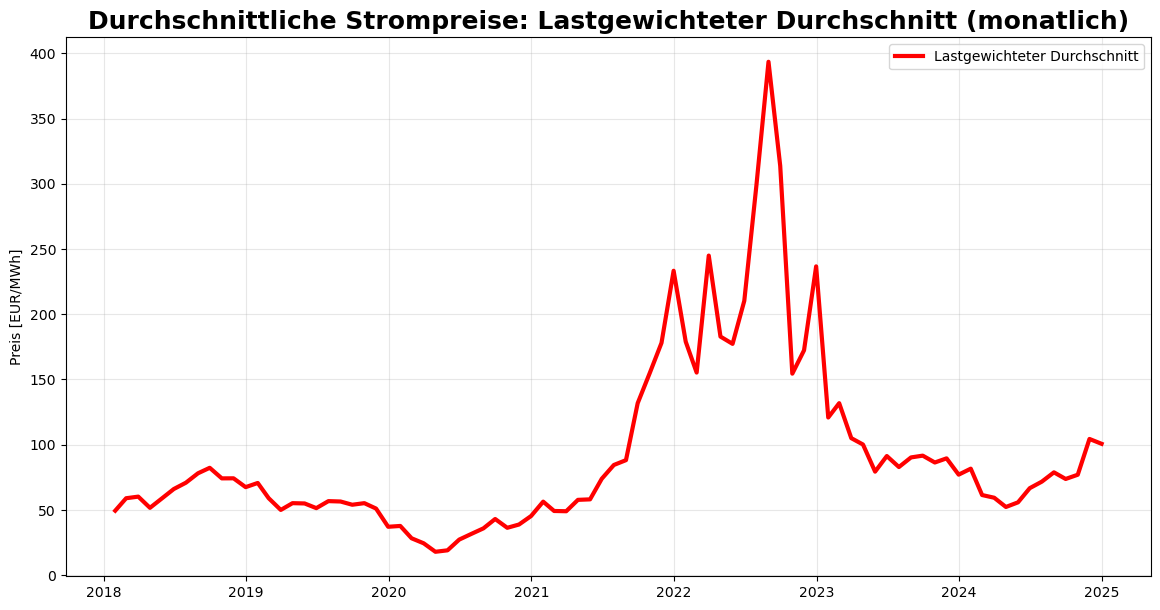

In [63]:
# Durchschnitt über alle Länder berechnen (lastgewichtet)
# Gruppieren nach Date_Time
avg_price_df = energy_prices_final_df.groupby('Date_Time').agg({
    'Price_x_Load': 'sum',
    'Actual_Load': 'sum'
}).reset_index()

avg_price_df['Weighted_Avg'] = avg_price_df['Price_x_Load'] / avg_price_df['Actual_Load']

plt.figure(figsize=(14, 7))

# Gewichteter Durchschnitt (mean)
plot_data = avg_price_df.set_index('Date_Time')['Weighted_Avg'].resample('ME').mean()
plt.plot(plot_data.index, plot_data.values, color='red', linewidth=3, label='Lastgewichteter Durchschnitt')

plt.title('Durchschnittliche Strompreise: Lastgewichteter Durchschnitt (monatlich)', fontsize=18, fontweight='bold')
plt.ylabel('Preis [EUR/MWh]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Analyse des durchschnittlichen Strompreises aller untersuchten Länder von 2018 - 2024:**  
- Von 2018 bis Ende 2019 hat sich der Strompreis zwischen ca. 20-80€/MWh bewegt, wobei er die meiste Zeit zwischen 50-80€/MWh lag
- Die Abweichung nach unten in diesem Zeitraum lag in der ersten Jahreshälfte 2020, in welcher der Strompreis auf sein Minimum der gesamten Betrachtungsperiode gefallen ist. Dies ist auf den Beginn der Coronaepidemie mitsamt der dadurch einhergenden kurzen Rezession zu erklären.
- Nachdem der Strompreis nach dem Coronaminimum Ende 2020 wieder auf sein Vor-Corona-Level von ca. 50€/MWh gestiegen ist, ist er in der zweiten Jahreshälfte 2021 stark weiter auf über 200€/MWh gestiegen
- 2022 hat sich der Strompreis nach Beginn des Ukrainekriegs zwischen 150€/MWh und 250€/MWh bewegt, mit einem kurzen starken Preisausschlag auf fast 400€/MWh im 2. Halbjahr
- Eine interessante Feststellung ist daher, dass die Strompreise bereits vor Beginn des Ukrainekrieges in der zweiten Jahreshälfte 2021 stark gestiegen sind. Dies kam durch das Zusammenspiel mehrerer Faktoren zustande: Die durch Corona ausgelöste Rezession war wider erwarten nur wenige Monate lang und die Wirtschaft wuchs bereits ab Mitte 2021 wieder sehr schnell. Zudem waren die Gasspeicher nach dem Winter 2020/21 auf historisch niedrigen Füllständen und die Kosten für CO2-Zertifikate haben sich im Jahr 2021 verdoppelt. Dadurch traf eine überraschend hohe Nachfrage auf ein verringertes Angebot (Gas) und höhere Erzeugungskosten für fossile Energieträger (über CO2-Zertifikate).
- Seit Anfang 2023 ist der Strompreis wieder schnell gesunken und befindet sich mittlerweile auf einem ähnlichen Niveau wie vor dem Ukrainekrieg. Gründe für den schnellen Rückgang waren nachfrageseitig (ein warmer Winter 2022/23, eine schwache wirtschaftliche Entwicklung, v.a. der größten Volkswirtschaft Deutschland) sowie angebotsseitig (alternative Gasversorgung über LNG).

Neben der Betrachtung des Preisverlaufs über die Zeit sollen nun einige Basis-Statistiken der Strompreise betrachtet werden. Dazu wird die Verteilung der Strompreise in einem Histogramm inklusive Mittelwert und Median dargestellt: 

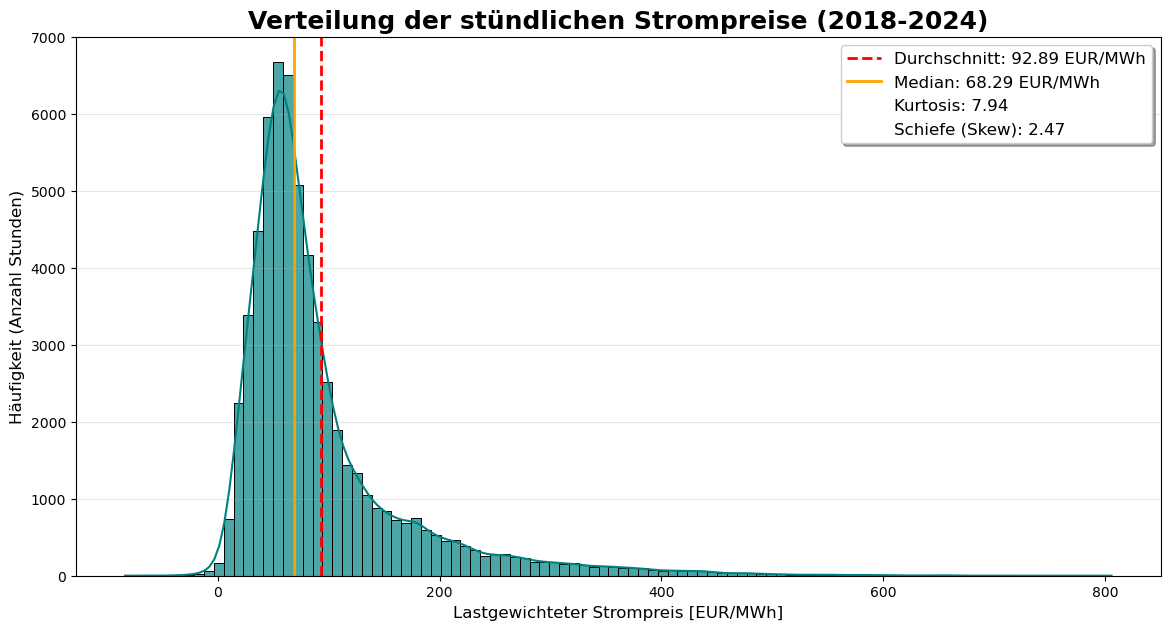

In [64]:
plt.figure(figsize=(14, 7))

# Histogramm erstellen
sns.histplot(avg_price_df['Weighted_Avg'], bins=100, kde=True, color='teal', edgecolor='black', alpha=0.7)

# Statistische Kennzahlen berechnen
mean_price     = avg_price_df['Weighted_Avg'].mean()
median_price   = avg_price_df['Weighted_Avg'].median()
price_kurtosis = kurtosis(avg_price_df['Weighted_Avg'])
price_skew     = skew(avg_price_df['Weighted_Avg'])

# Vertikale Linien für Durchschnitt und Median
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Durchschnitt: {mean_price:.2f} EUR/MWh')
plt.axvline(median_price, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_price:.2f} EUR/MWh')

# Dummy-Plots für die Legende (um Kurtosis und Skew ohne Linie anzuzeigen)
plt.plot([], [], ' ', label=f'Kurtosis: {price_kurtosis:.2f}')
plt.plot([], [], ' ', label=f'Schiefe (Skew): {price_skew:.2f}')

plt.title('Verteilung der stündlichen Strompreise (2018-2024)', fontsize=18, fontweight='bold')
plt.xlabel('Lastgewichteter Strompreis [EUR/MWh]', fontsize=12)
plt.ylabel('Häufigkeit (Anzahl Stunden)', fontsize=12)
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Analyse der Verteilung der Preise aller untersuchten Länder von 2018 - 2024:**  
- Die Verteilung ist mit einer Schiefe von 2,5 extrem rechtsschief: dies entsteht dadurch, dass sich die meisten Preise zwischen 0-100€/MWh verteilen, es aber einige sehr hohe Preisausschläge gibt (wie oben dargestellt)
- Die Verteilung ist mit einer Kurtosis von 8 extrem steilgipflig  (Normalverteilung: Kurtosis = 3), die Strompreis-Verteilung weißt also einen extremen Peak auf
- Besonders interessant ist eine Eigenschaft, die für andere wirtschaftliche Variablen kaum bzw. gar nicht vorkommt: die Verteilung der Strompreis hat keinen linken lower bound (normalerweise ist dieser bei 0). Es kommt also gelegentlich zu negativen Preisen. Dies kann durch einen mismatch von Angebot und Nachfrage geschehen: Da Strom nur bedingt gelagert werden kann (Battieren, Pumpspeicherkraftwerke) und die Erzeugung eine gewisse Trägheit aufweist, kann es zu kurzzeitigen Ungleichgewichten zwischen Erzeugung und Verbrauch kommen. Im Falle einer zu hohen Erzeugung/zu geringen Nachfrage führt dies zu negativen Preisen, der Stromabnehmer wird für seinen Kauf des Stromes zusätzlich bezahlt.

Um genauer zu untersuchen, wie häufig dieses Phänomen vorkommt, wird die Anzahl der Stunden mit Preisen <0€/MWh sowie deren Anteil an allen Stunden in dem Betrachtugnszeitraum berechnet:

In [65]:
# Berechnung der Negativstunden (Preis < 0)
neg_hours   = len(avg_price_df[avg_price_df['Weighted_Avg'] < 0])
total_hours = len(avg_price_df)
neg_pct     = (neg_hours / total_hours) * 100

print(f"Anzahl der Negativstunden: {neg_hours}")
print(f"Anteil an Gesamtstunden:   {neg_pct:.2f}%")

Anzahl der Negativstunden: 157
Anteil an Gesamtstunden:   0.26%


Mit 0,3% weist der lastgewichtete Durchschnitt nur sehr wenige Stunden mit negativen Preisen auf. Die Verwendung des lastgewichteten Durchschnitts über alle 19 Länder verzerrt aber die Aussagekraft, da ein lastgewichtete Strompreisdurchschnitt von <0€/MWh gleichzeit über alle 19 Länder entsprechend selten vorkommt.  

Um diesen Effekt zu umgehen, wird im Folgenden für jedes Land einzeln die Anzahl und der Anteil der Stunden mit negativen Preisen berechnet:

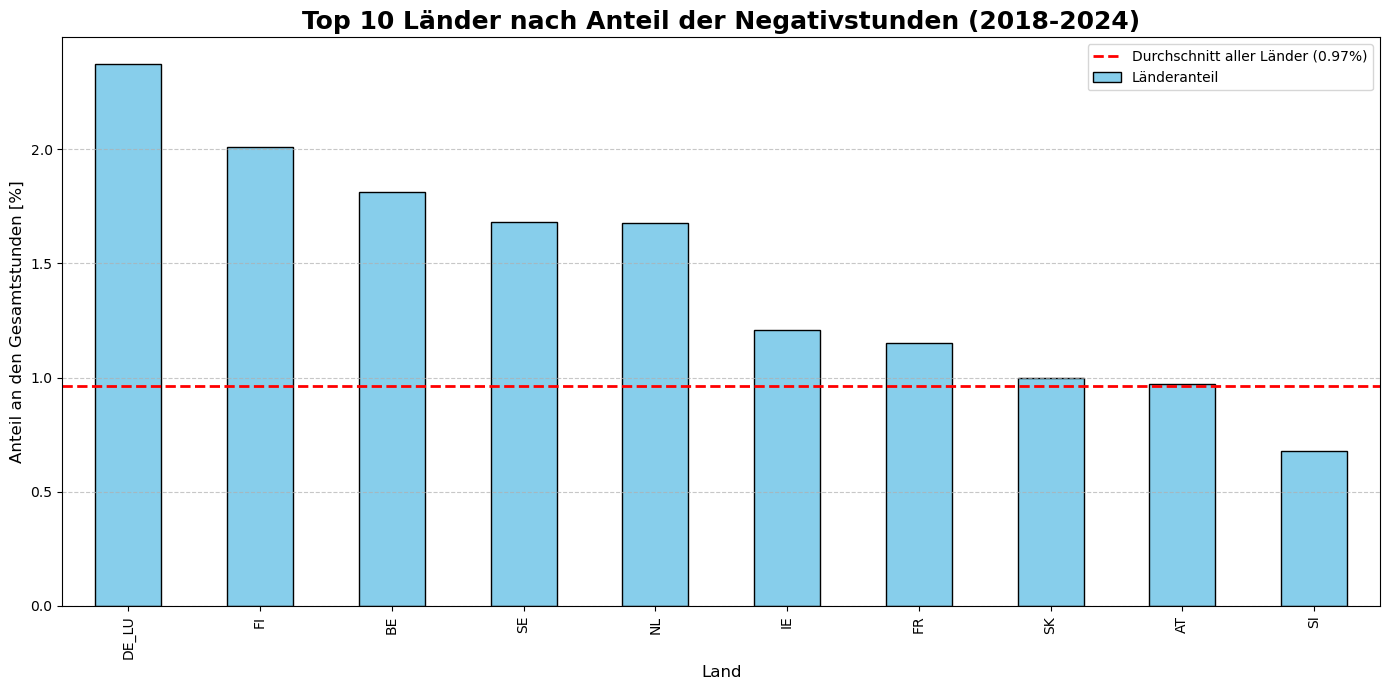

In [66]:
# Berechnung pro Land
country_neg_prices_df = energy_prices_final_df.groupby('Land_Code').agg(
    negativ_hours=('Weighted_Price', lambda x: (x < 0).sum()),
    total_hours=('Weighted_Price', 'count')
)

# Anteil in Prozent berechnen
country_neg_prices_df['share_neg_hours_pct'] = (country_neg_prices_df['negativ_hours'] / country_neg_prices_df['total_hours']) * 100

# Einfachen Durchschnitt berechnen (1/n über alle Länder)
simple_avg_pct = country_neg_prices_df['share_neg_hours_pct'].mean()

# Sortieren (höchster Anteil zuerst)
country_neg_prices_df = country_neg_prices_df.sort_values(by='share_neg_hours_pct', ascending=False)

# Visualisierung der Top 10
plt.figure(figsize=(14, 7))
ax = country_neg_prices_df['share_neg_hours_pct'].head(10).plot(kind='bar', color='skyblue', edgecolor='black', label='Länderanteil')

# Horizontale Linie für den einfachen Durchschnitt
plt.axhline(y=simple_avg_pct, color='red', linestyle='--', linewidth=2, label=f'Durchschnitt aller Länder ({simple_avg_pct:.2f}%)')

plt.title('Top 10 Länder nach Anteil der Negativstunden (2018-2024)', fontsize=18, fontweight='bold')
plt.ylabel('Anteil an den Gesamtstunden [%]', fontsize=12)
plt.xlabel('Land', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

**Analyse der Anteil der Negativstunden (Top 10):**  

- Die Gebotszone Deutschland/Luxemburg weist mit ca. 2,4% den höchsten Stundenanteil mit negativen Preisen auf, dieser ist fast 3x so hoch wie der Durchschnitt (nicht lastgewichtet) über alle untersuchten Länder
- Finnland, Belgien, Schweden, Niederlande, Irland und Frankreich weisen ebenfalls Werte über dem Durchschnitt auf
- Die anderen 12 Länder haben Werte auf bzw. deutlich unter dem Durchschnitt

### 3.1.1 Strompreis-Volatilität

Als nächstes wird untersucht, wie sich die Strompreisvolatilität im Betrachtungszeitraum entwickelt hat. Dafür wird die Standardabweichung des Strompreises über verschiedene rollierende Zeiträume berechnet: täglich, wöchentlich, monatlich und jährlich.

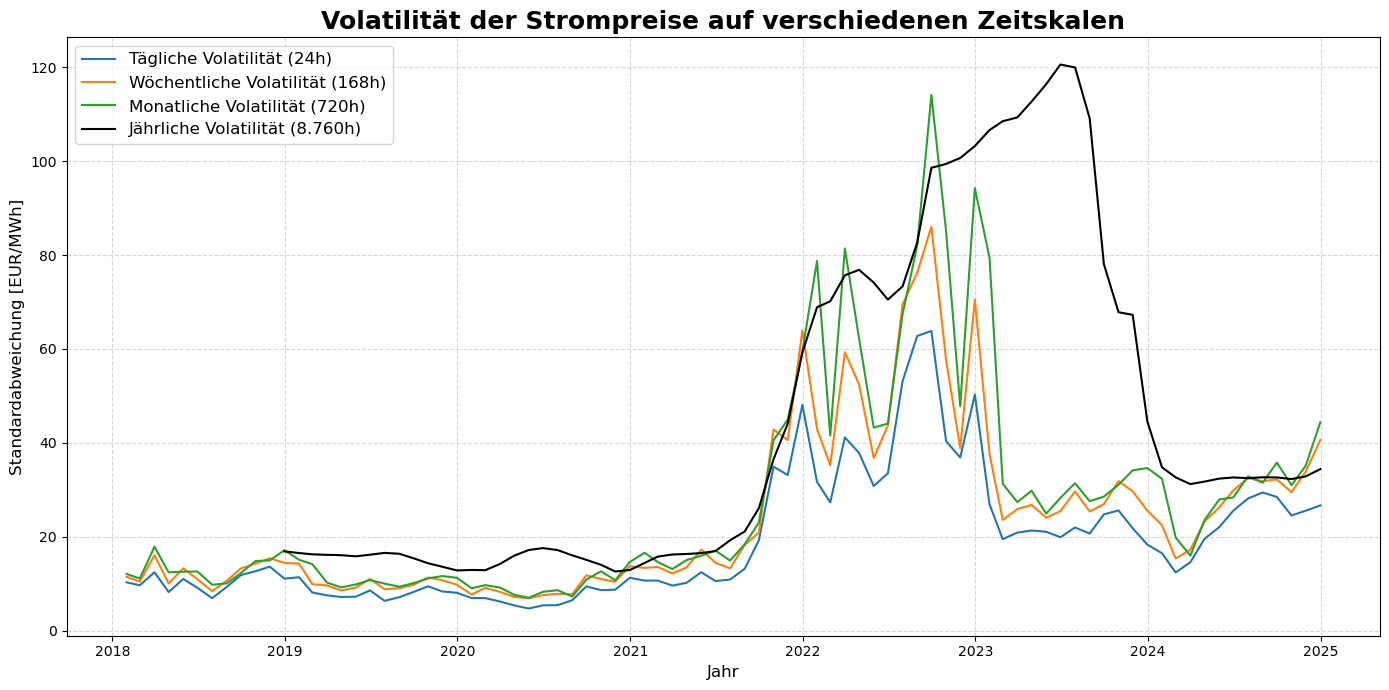

In [68]:
# Datenbasis
# Verwendung des bereits berechneten avg_price_df (stündlich)
vol_df = avg_price_df[['Date_Time', 'Weighted_Avg']].copy()
vol_df.set_index('Date_Time', inplace=True)

# Volatilitäts-Berechnung
# Berechnung der Standardabweichung für verschiedene Zeitfenster: 24h (täglich), 168h (wöchentlich), 720h (monatlich), 8760h (jährlich)

# Tägliche Volatilität (24h)
vol_df['Std_Daily'] = vol_df['Weighted_Avg'].rolling(window=24).std()

# Wöchentliche Volatilität (168h)
vol_df['Std_Weekly'] = vol_df['Weighted_Avg'].rolling(window=168).std()

# Monatliche Volatilität (720h)
vol_df['Std_Monthly'] = vol_df['Weighted_Avg'].rolling(window=720).std()

# Jährliche Volatilität (8760h)
vol_df['Std_Yearly'] = vol_df['Weighted_Avg'].rolling(window=8760).std()


# Visualisierung
plt.figure(figsize=(14, 7))

# Resampeln auf Monatsmittelwerte der Volatilität für eine saubere Darstellung
plot_data = vol_df.resample('ME').mean()

plt.plot(plot_data.index, plot_data['Std_Daily'], label='Tägliche Volatilität (24h)')
plt.plot(plot_data.index, plot_data['Std_Weekly'], label='Wöchentliche Volatilität (168h)')
plt.plot(plot_data.index, plot_data['Std_Monthly'], label='Monatliche Volatilität (720h)')
plt.plot(plot_data.index, plot_data['Std_Yearly'], label='Jährliche Volatilität (8.760h)', color='black')

plt.title('Volatilität der Strompreise auf verschiedenen Zeitskalen', fontsize=18, fontweight='bold')
plt.ylabel('Standardabweichung [EUR/MWh]', fontsize=12)
plt.xlabel('Jahr', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

**Analyse der Preisvolatilitäten aller untersuchten Länder von 2018 - 2024:**
- Die Entwicklung der Preisvolatilitäten folgt einem ähnlichen Muster wie die Preisentwicklung
- Alle Volatiltätskennzahlen haben sich bis Mitte 2021 in einem engen Band von ca. 10-20€/MWh bewegt
- Auch die Volatilität ist parallel zu den Strompreisen bereits ab Jahresmitte 2021 stark angestiegen
- Während des Jahres 2022 ist die Volatilität dann innerhalb eines großen Schwankungsbereiches sehr hoch geblieben
- Der Rückgang erfolgte dann - wie auch bei den Strompreisen - schlagartig am Jahresbeginn 2023 (aufgrund der rollierenden Berechnung erfolgt der Rückgang der jährlichen Volatilität entsprechend zeitverzögert)
- Seitdem bewegt sich die Volatiltät in einem Band zwischen 20-40€/MWh und ist damit ggü. dem Vor-Kriegs-Niveau weiterhin ca. doppelt so hoch
- Die Gründe für die Bewegungen der Volatilität sind dabei die gleichen wie für die Preisentwicklung: der Angebots-Nachfrage-mismatch seit Mitte 2021, die Ungewissheit der Auswirkungen des Ukrainekriges 2023, sowie die angebotsseitige Abkopplung vom Kriegsgeschehen seit 2023 durch den Aufbau alternativer Gas-Lieferketten

### 3.1.2 Korrelation Strompreise - Volatilität:

Auf Grundlage dieser ersten Analysen lässt sich nun untersuchen, ob und wenn ja wie stark die Strompreise und die Volatilität miteinander korrelieren:

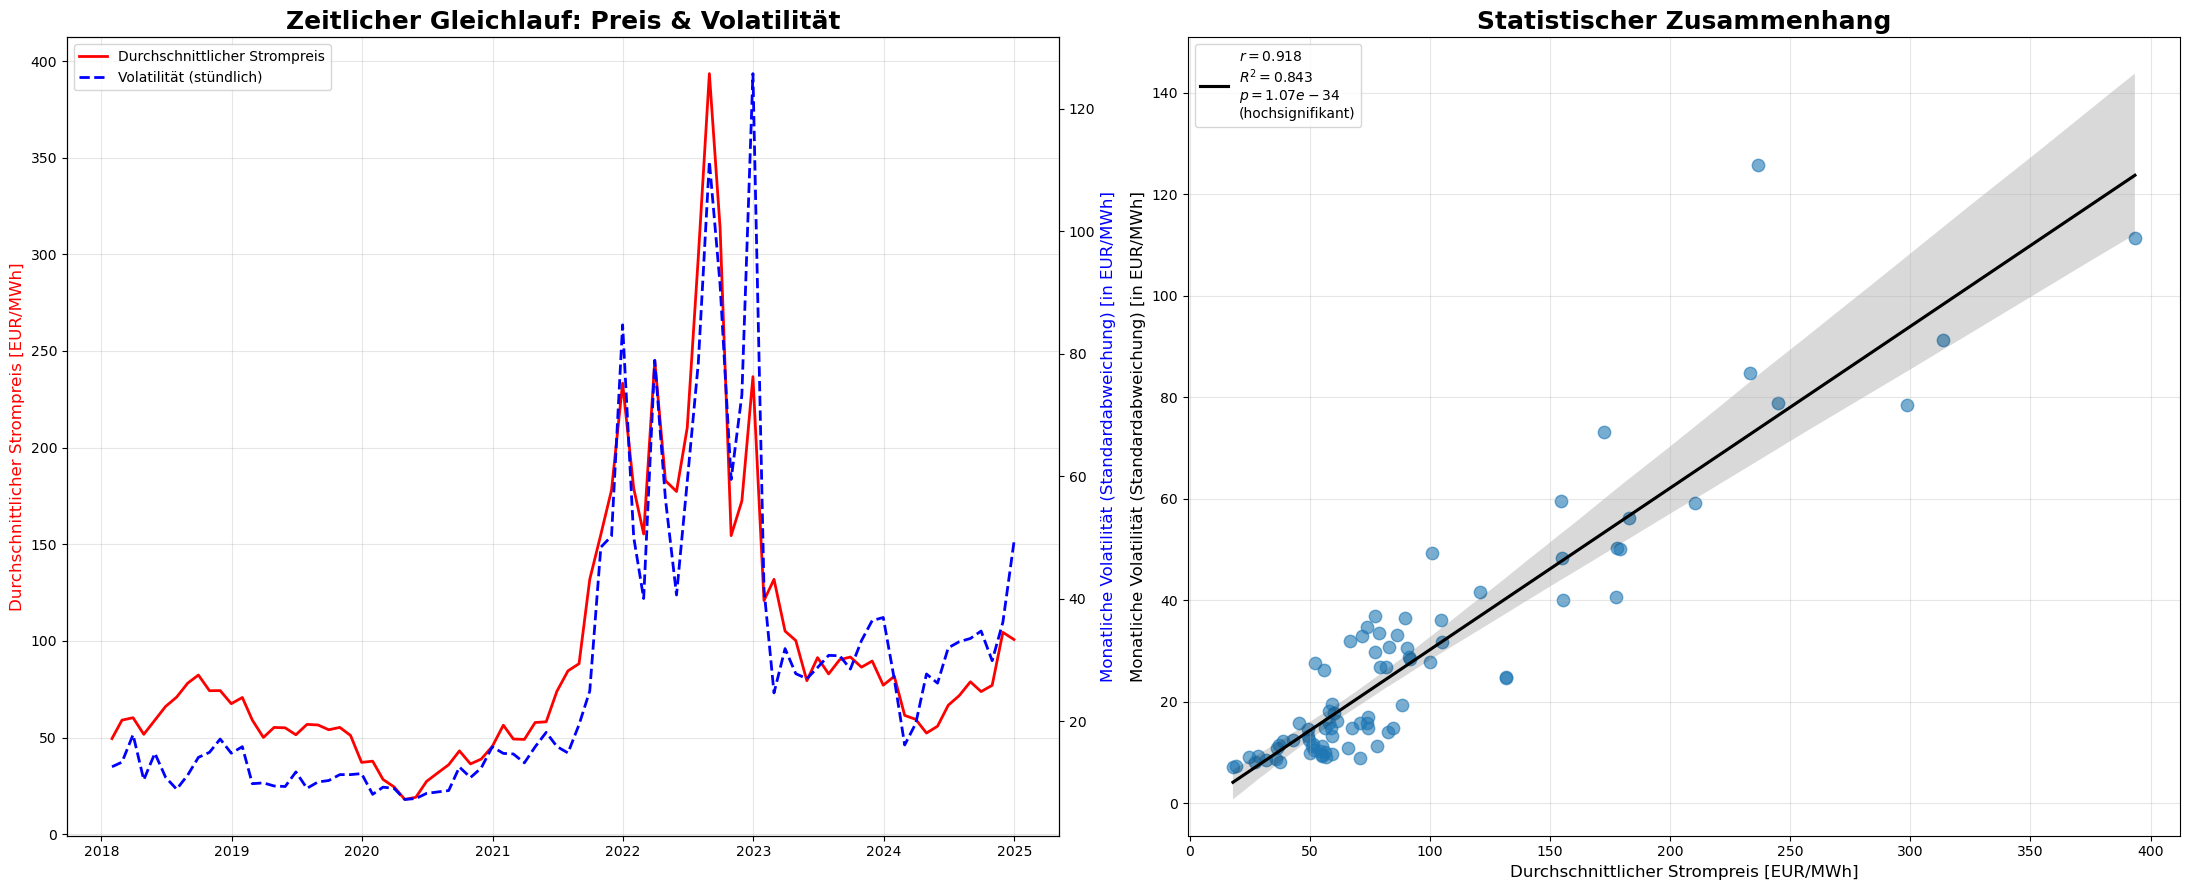

In [69]:
# Datenvorbereitung
# Nutzung der monatlichen Mittelwerte
corr_df = avg_price_df.set_index('Date_Time').resample('ME').agg({'Weighted_Avg': 'mean'})

# Hinzufügen der monatlichen Volatilität
corr_df['Monthly_Volatility'] = avg_price_df.set_index('Date_Time')['Weighted_Avg'].resample('ME').std()

# Berechnung der Korrelation
slope, intercept, r_value, p_value, std_err = stats.linregress(corr_df['Weighted_Avg'], corr_df['Monthly_Volatility'])

# Dynamische Abfrage der Signifikanz
sig_text = "hochsignifikant" if p_value < 0.001 else "signifikant" if p_value < 0.05 else "nicht signifikant"


# Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# Plot 1: Zeitlicher Verlauf (primäre und sekundäre Achse)
ax1_twin = ax1.twinx()
lns1 = ax1.plot(corr_df.index, corr_df['Weighted_Avg'], color='red', label='Durchschnittlicher Strompreis', linewidth=2)
lns2 = ax1_twin.plot(corr_df.index, corr_df['Monthly_Volatility'], color='blue', label='Volatilität (stündlich)', linewidth=2, linestyle='--')

ax1.set_title('Zeitlicher Gleichlauf: Preis & Volatilität', fontsize=18, fontweight='bold')
ax1.set_ylabel('Durchschnittlicher Strompreis [EUR/MWh]', color='red', fontsize=12)
ax1_twin.set_ylabel('Monatliche Volatilität (Standardabweichung) [in EUR/MWh]', color='blue', fontsize=12)
ax1.grid(True, alpha=0.3)

# Legenden kombinieren
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')

# Plot 2: Scatterplot mit Regression
sns.regplot(data=corr_df, x='Weighted_Avg', y='Monthly_Volatility', 
            scatter_kws={'alpha':0.6, 's':80}, 
            line_kws={'color':'black', 'label':f'$r = {r_value:.3f}$\n$R^2 = {r_value**2:.3f}$\n$p = {p_value:.2e}$\n({sig_text})'}, ax=ax2)

ax2.set_title('Statistischer Zusammenhang', fontsize=18, fontweight='bold')
ax2.set_xlabel('Durchschnittlicher Strompreis [EUR/MWh]', fontsize=12)
ax2.set_ylabel('Monatliche Volatilität (Standardabweichung) [in EUR/MWh]', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse der Korrelation von Strompreis und Volatilität aller Länder von 2018 - 2024:**
- Das Liniendiagramm zeigt einen deutlichen Gleichlauf zwischen der Strompreishöhe und der Volatilität auf
- Die Korrelation zwischen den beiden Variablen ist hochsignifikant und mit einem R² von 0,84 sehr hoch
- Eine Steigerung des Strompreises ist also sehr stark mit einer Erhöhung der Volatilität korreliert, bei steigenden Strompreisen steigt also die Schwankungsbreite ebenfalls an und vice versa

## 3.2 Stromerzeugung

Um einen Überblick über die Zusammensetzung der Stromerzeugung zu bekommen, werden zunächst die Gesamtstromerzeugung sowie die Erzeugung der erneuerbaren sowie der variablen erneuerbaren Energien dargestellt:

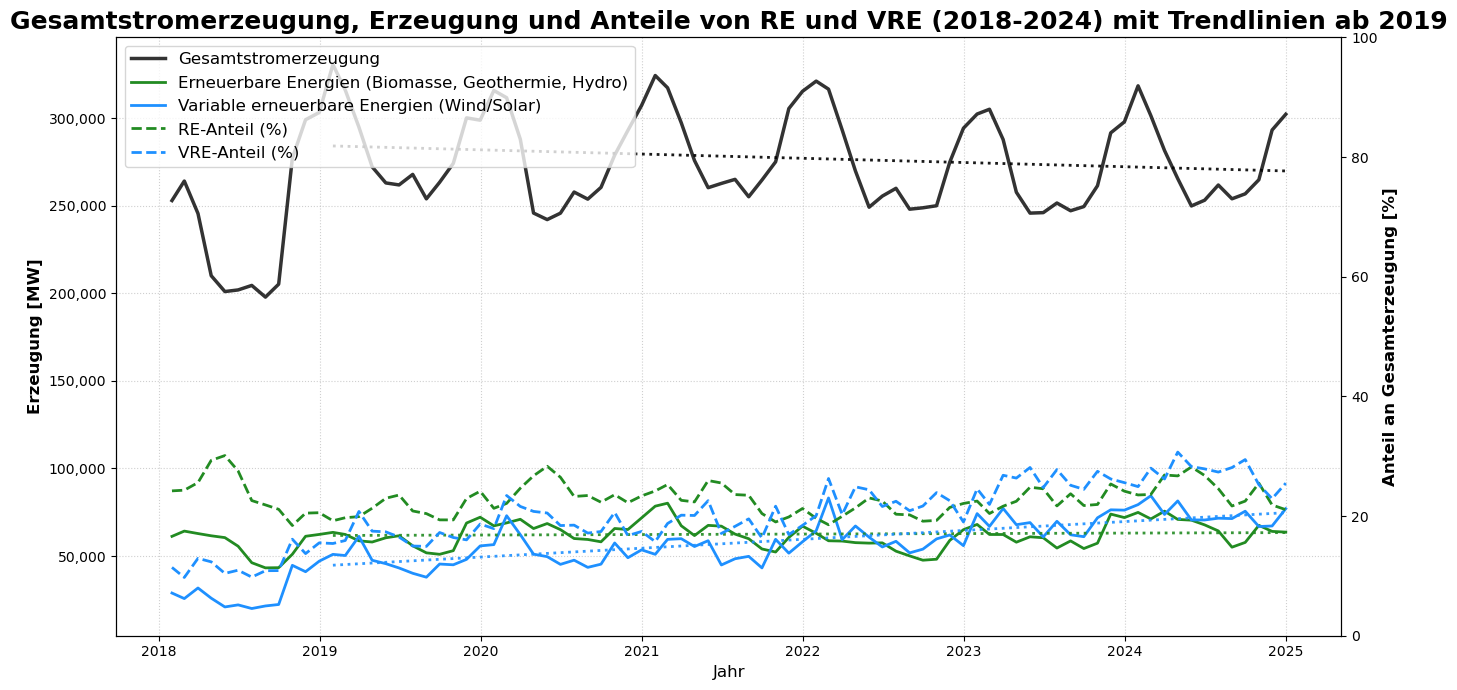

In [70]:
# Datenaggregation
gen_monthly_df = generation_final_df.groupby('Date_Time').agg({
    'Gen_Total_MW': 'sum',
    'Gen_RE_Total_MW': 'sum',
    'Gen_VRE_Total_MW': 'sum'
}).resample('ME').mean()

# Anteil der Erzeugungsarten liegen im generation_filtered_df zwar bereits vor, aber nicht aggregiert, und werden daher direkt im gen_monthly_df als neue Spalten neu berechnet
gen_monthly_df['RE_Share_Pct_Agg']  = (gen_monthly_df['Gen_RE_Total_MW']  / gen_monthly_df['Gen_Total_MW']) * 100
gen_monthly_df['VRE_Share_Pct_Agg'] = (gen_monthly_df['Gen_VRE_Total_MW'] / gen_monthly_df['Gen_Total_MW']) * 100

# Hilfsfunktion für die Trendlinie (Begrenzung auf 2019-2024)
def add_partial_trendline(ax, data_series, color):
    # Filter auf Daten ab 2019 für die Berechnung
    trend_data = data_series[data_series.index.year >= 2019]
    
    # x-Werte als numerische Repräsentation (Tage seit Start)
    x_dates = mdates.date2num(trend_data.index)
    y_values = trend_data.values
    
    # Lineare Regression (Polynom 1. Grades)
    z = np.polyfit(x_dates, y_values, 1)
    p = np.poly1d(z)
    
    # Trendlinie nur für den Bereich ab 2019 zeichnen
    ax.plot(trend_data.index, p(x_dates), color=color, linestyle=':', linewidth=2, alpha=0.9)


# Visualisierung
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primäre Achse: Absolute Werte (MW) - Gesamter Zeitraum
ax1.plot(gen_monthly_df.index, gen_monthly_df['Gen_Total_MW'], label='Gesamtstromerzeugung', color='black', linewidth=2.5, alpha=0.8)
ax1.plot(gen_monthly_df.index, gen_monthly_df['Gen_RE_Total_MW'], label='Erneuerbare Energien (Biomasse, Geothermie, Hydro)', color='forestgreen', linewidth=2)
ax1.plot(gen_monthly_df.index, gen_monthly_df['Gen_VRE_Total_MW'], label='Variable erneuerbare Energien (Wind/Solar)', color='dodgerblue', linewidth=2)

# Trendlinien hinzufügen: Berechnung & Darstellung nur ab 2019
add_partial_trendline(ax1, gen_monthly_df['Gen_Total_MW'], 'black')
add_partial_trendline(ax1, gen_monthly_df['Gen_RE_Total_MW'], 'forestgreen')
add_partial_trendline(ax1, gen_monthly_df['Gen_VRE_Total_MW'], 'dodgerblue')

# Achsenformatierung
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.set_ylabel('Erzeugung [MW]', fontsize=12, fontweight='bold')
ax1.set_xlabel('Jahr', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# Sekundäre Achse: Anteile (%) - Gesamter Zeitraum
ax2 = ax1.twinx()
ax2.plot(gen_monthly_df.index, gen_monthly_df['RE_Share_Pct_Agg'], color='forestgreen', linewidth=2, label='RE-Anteil (%)', linestyle='--')
ax2.plot(gen_monthly_df.index, gen_monthly_df['VRE_Share_Pct_Agg'], color='dodgerblue', linewidth=2, label='VRE-Anteil (%)', linestyle='--')

ax2.set_ylabel('Anteil an Gesamterzeugung [%]', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)

# Legende
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12, frameon=True, shadow=False)

plt.title('Gesamtstromerzeugung, Erzeugung und Anteile von RE und VRE (2018-2024) mit Trendlinien ab 2019', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

**Analyse der Stromerzeugung und deren Anteile aller Länder von 2018 - 2024:**
- Die niedrige Erzeugungsleistung 2018 ist eine Datenlücke, daher werden die Trendlinien erst ab 2019 berechnet, um die Trends nicht zu verfälschen
- Die Gesamtstromerzeugung ist über die Jahre leicht fallend, dies spricht für eine zunehmende Energieeffizienz dieser Länder, da das BIP in der gleichen Zeit leicht gestiegen ist. Dies gilt umso mehr, als dass in der Zeit zusätzlich die Elektrifizierung von Mobilität und Wärme vorangeschritten ist. Dies wird in den Kapiteln 3.3 und 3.4 genauer analysiert.
- Die Erzeugung folgt zudem einem klaren saisonalen Muster: im Winter steigt der Bedarf für Beleuchtung und Heizung (v.a. bei der Verwendung von Wärmepumpen), in den Sommermonaten geht der Bedarf zurück
- Die Erzeugung erneuerbarer Energien und deren Anteil an der Gesamterzeugung ist über die Jahre hinweg konstant. Bei diesen Erzeugungsarten erfolgt also kein nennenswerter Ausbau
- Im Gegensatz dazu steigt die Erzeugung der variablen erneuerbaren Energien deutlich an, und ist im Zeitraum 2019-2024 um ca. 50% gestiegen

## 3.3 Wärmepumpen

Um einen ersten Überblick über den Ausbau auf der Verbraucherseite zu bekommen, wird zunächst die Entwicklung der Wärmepumpen aller Länder für den Gesamtzeitraum 2018-2024 betrachtet.  
Wie in Kapitel 2.1 (Datenquellen) bereits beschrieben wurde, handelt es sich hierbei um die aufgenommene Energiemenge der Wärmepumpen. Eine Betrachtung der Stückzahl würde auch zu einem stark verfälschten Bild führen, da der Leistungsbereich von Wärmepumpen von wenigen Kilowatt bis mehreren Megawatt reicht.

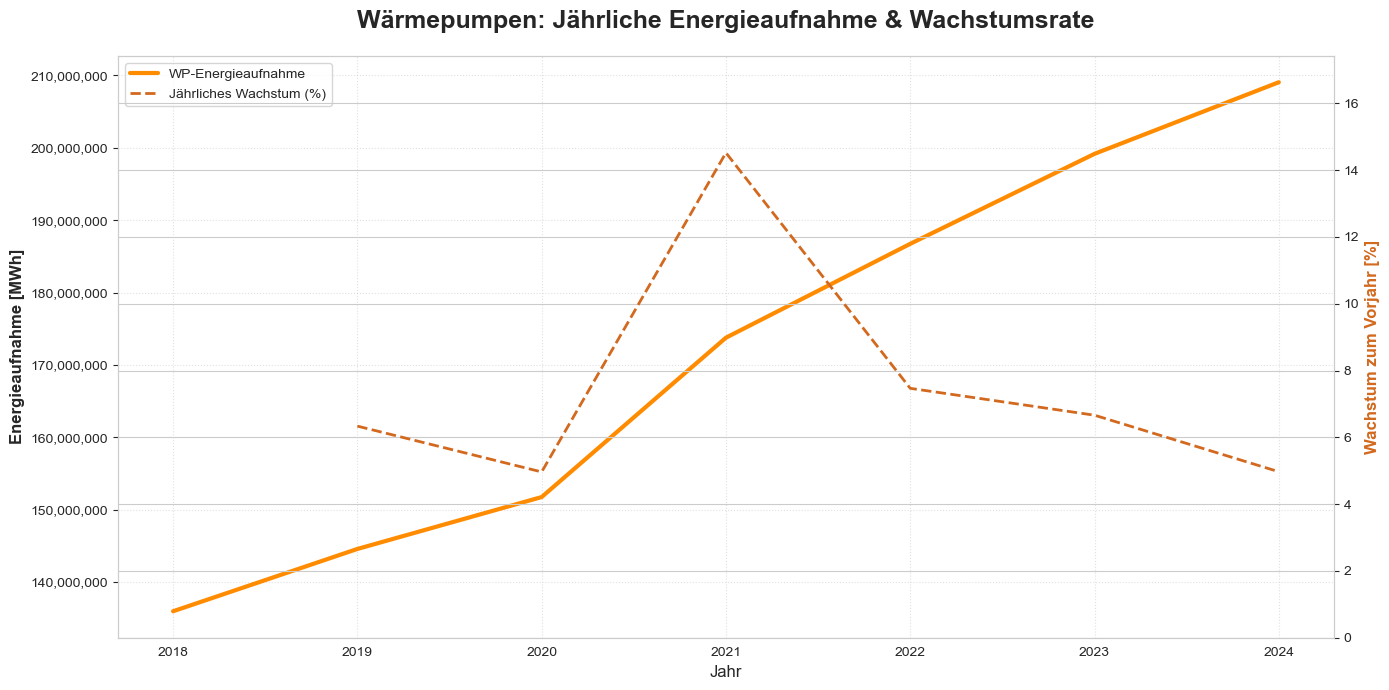

In [110]:
# Datenaggregation
# Summe der aufgenommenen Energie über alle Länder pro Jahr
hp_yearly_df = hp_final_df.groupby('Year').agg({'HP_Value_MWh': 'sum'}).reset_index()

# Jährliches Wachstum berechnen
hp_yearly_df['Growth_Pct'] = hp_yearly_df['HP_Value_MWh'].pct_change() * 100


# Visualisierung
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primäre Achse: Absolute Energieaufnahme (durchgezogene Linie)
line1 = ax1.plot(hp_yearly_df['Year'], hp_yearly_df['HP_Value_MWh'], color='darkorange', linewidth=3, label='WP-Energieaufnahme')

# Sekundäre Achse: Wachstum (gestrichelte Linie)
ax2 = ax1.twinx()
line2 = ax2.plot(hp_yearly_df['Year'], hp_yearly_df['Growth_Pct'], color='chocolate', linewidth=2, linestyle='--', label='Jährliches Wachstum (%)')

# Formatierung
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax2.set_ylim(0, hp_yearly_df['Growth_Pct'].max() * 1.2) 

ax1.set_title('Wärmepumpen: Jährliche Energieaufnahme & Wachstumsrate', fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel('Energieaufnahme [MWh]', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wachstum zum Vorjahr [%]', fontsize=12, fontweight='bold', color='chocolate')
ax1.set_xlabel('Jahr', fontsize=12)

ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xticks(hp_yearly_df['Year'])

# Legenden kombinieren
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')

plt.tight_layout()
plt.show()

**Analyse der von Wärmepumpen aufgenommenen Energie aller Länder von 2018 - 2024:**
- Die von Wärmepumpen aufgenomme Energie hat in den untersuchten Ländern kontinuerlich bis 2024 zugenommen und liegt 2024 mehr als 50% über dem Wert von 2018
- Die jährliche Wachstumsrate hat sich in einem engen Band zwischen ca. 5% und 7% p.a. bewegt, mit einem Ausreißer auf ca. 14% im Jahr 2021
- Der Wärmepumpenmarkt ist stark regulatorisch getrieben (z.B. Gebäudegsetze, CO2-Bepreisung, steuerliche Anreizprogramme), was plötzliche Ausschläge in den Wachstumsraten erklären kann
- Mit der steigenden Wärmepumpenleistung nimmt der Bedarf an elektrischer Energie entsprechend zu, ob dies einen Einfluss auf die Strompreise und Volatilitäten hat wird in Kapitel 5 genauer untersucht

## 3.4 Elektroautos

Analog zu den Wärmepupen wird zunächst ein erster Überblick über die Elektroautos gegeben, indem der Bestand an Elektroautos aller Länder für den Gesamtzeitraum 2018-2024 visualisiert wird:  

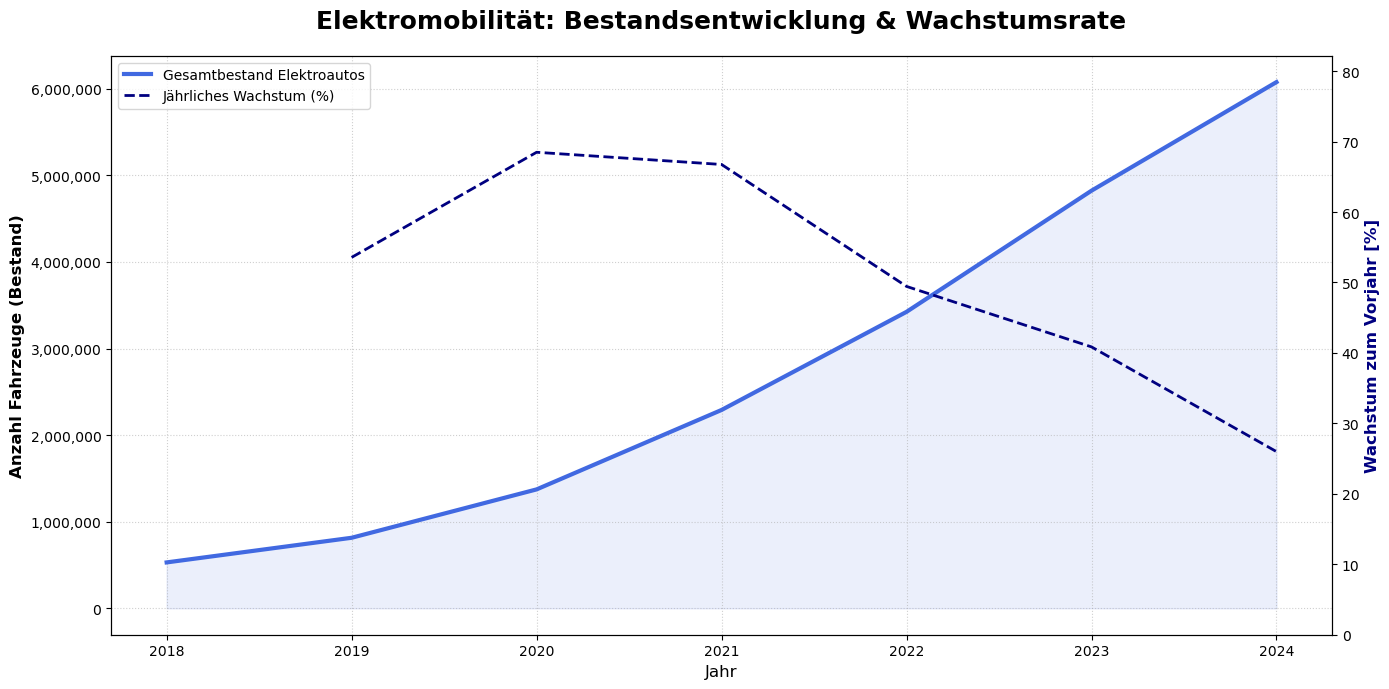

In [72]:
# Datenaggregation
# Summe des Bestands über alle Länder pro Jahr
ev_yearly_df = e_veh_final_df.groupby('Year').agg({'EV_Count_Total': 'sum'}).reset_index()

# Jährliches Wachstum berechnen
ev_yearly_df['Growth_Pct'] = ev_yearly_df['EV_Count_Total'].pct_change() * 100


# Visualisierung
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primäre Achse: Absoluter Bestand (durchgezogene Linie)
line1 = ax1.plot(ev_yearly_df['Year'], ev_yearly_df['EV_Count_Total'], color='royalblue', linewidth=3, label='Gesamtbestand Elektroautos')
ax1.fill_between(ev_yearly_df['Year'], ev_yearly_df['EV_Count_Total'], color='royalblue', alpha=0.1)

# Sekundäre Achse: Wachstum (gestrichelte Linie)
ax2 = ax1.twinx()
line2 = ax2.plot(ev_yearly_df['Year'], ev_yearly_df['Growth_Pct'], color='navy', linewidth=2, linestyle='--', label='Jährliches Wachstum (%)')

# Formatierung
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Skala für Wachstum optimieren (startet bei 0)
ax2.set_ylim(0, ev_yearly_df['Growth_Pct'].max() * 1.2)

ax1.set_title('Elektromobilität: Bestandsentwicklung & Wachstumsrate', fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel('Anzahl Fahrzeuge (Bestand)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wachstum zum Vorjahr [%]', fontsize=12, fontweight='bold', color='navy')
ax1.set_xlabel('Jahr', fontsize=12)

ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xticks(ev_yearly_df['Year'])

# Legenden kombinieren
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')

plt.tight_layout()
plt.show()

**Analyse des Elektroauto-Bestandes aller Länder von 2018 - 2024:**
- Der Elektroauto-Bestand hat in den untersuchten Ländern kontinuerlich bis 2024 zugenommen und liegt 2024 ca. 10x höher als der Wert von 2018
- Die jährliche Wachstumsrate ist dementsprechend deutlich höher als die der Wärmepumpen, hat sich aber deutlich abgeschwächt: von einem Spitzenwert im Jahr 2020 von fast 70% auf unter 30% im Jahr 2024.
- Auch bei Elektroautos spielen politische/regulatorische Anreize (v.a. in Form von Kaufprämien und steuerlichen Begünstigungen) eine große Rolle bei der individuellen Kaufentscheidung
- Zudem sind sehr hohe Wachstumsraten (wie hier 2020/21 mit ca. 70%) über längere Zeitskalen kaum aufrecht zu erhalten, so würde eine Wachstumsrate von 70% p.a. den Bestand über 10 Jahren um den Faktor 200 erhöhen 
- Analog zum Wärmepumpenausbau steigt mit dem Elektroauto-Bestand der Bedarf an elektrischer Energie, auch dieser Einfluss auf die Strompreise und Volatilitäten wird in Kapitel 5 genauer untersucht

# 4. Marktsegmentierung

Nachdem ein Überblick über die einzelnen Variablen auf aggregierter Länderebene erstellt wurde, erfolgt nun eine Marktsegmentierung auf Einzelländer-Ebene.

## 4.1 Heatmap

Dies wird mit Hilfe der Erstellung einer umfassenden Heatmap erreicht.

Die Darstellung gliedert sich in zwei Schritte:  
1. Im ersten Schritt wird eine heatmap aller Länder erstellt, wobei für die folgenden Kategorien jeweils der Wert für 2024, die Durchschnittswerte von 2018-2024 sowie die Wachstumsraten für drei Zeitintervalle (2018-2024, 2018-2021, 2021-2024) berechnet werden:
   - Strompreis
   - Volatilität
   - Stromerzeungsanteile der RE und VRE
   - Wärmepumpen / 1.000 Einwohner
   - Elektroautos / 1.000 Einwohner
2. Im zweiten Schritt werden diesen absoluten Werten jeweils ein Rang von 1-19 (1: Land mit dem besten Wert, 19: Land mit dem schlechtesten Wert) zugeordnet, und ein Gesamtranking (Durchschnitt über alle Kategorien) für jedes Land erstellt. Dadurch lassen sich die Länder nach ihrem Ranking sortieren.

In [111]:
# Strompreise und Volatilität
ep_df = energy_prices_final_df.copy()
ep_df['Date'] = ep_df['Date_Time'].dt.date

# Stündliche Strompreise und Volatilität: Jahresdurchschnitt
price_yearly_df = ep_df.groupby(['Year', 'Land_Code'], observed=False).agg(
    Price_Avg=('Weighted_Price', 'mean'),
    Vol_Hourly=('Weighted_Price', 'std')
).reset_index()

# Tägliche Strompreise und Volatilität: Jahresdurchschnitt
daily_avg_df = ep_df.groupby(['Year', 'Land_Code', 'Date'], observed=False)['Weighted_Price'].mean().reset_index()
vol_daily_df = daily_avg_df.groupby(['Year', 'Land_Code'], observed=False)['Weighted_Price'].std().reset_index(name='Vol_Daily')

# Mergen von stündlichen und täglichen Strompreisen/Volatilitäten in einen df
price_yearly_df = price_yearly_df.merge(vol_daily_df, on=['Year', 'Land_Code'])


# Stromerzeugung
gen_yearly = generation_final_pop_df.groupby(['Year', 'Land_Code'], observed=False).agg(
    RE_Share_Avg=('RE_Share_Pct', 'mean'),
    VRE_Share_Avg=('VRE_Share_Pct', 'mean'),
    Gen_RE_Total_MW=('Gen_RE_Total_MW', 'mean'), 
    Gen_VRE_Total_MW=('Gen_VRE_Total_MW', 'mean') 
).reset_index()


# Zusammenführung zu einem "master-df": Preise/Volatilität mit Stromerzeugung, danach mit Wärmepumpen und Elektroautos
master_df = price_yearly_df.merge(gen_yearly, on=['Year', 'Land_Code'], how='outer')
master_df = master_df.merge(hp_final_pop_df[['Year', 'Land_Code', 'HP_Value_MWh_Pop']], on=['Year', 'Land_Code'], how='left')
master_df = master_df.merge(e_veh_final_pop_df[['Year', 'Land_Code', 'EV_Count_Total_Pop']], on=['Year', 'Land_Code'], how='left')


# Wachstumsraten (CAGR 2018-2024): Definiton der Funktion get_cagr
def get_cagr(df, country, column, start_year=None, end_year=None):
    # Basis-Filter für Land und Werte > 0 (da mit Nullwerten keine CAGR berechnet werden können)
    data = df[(df['Land_Code'] == country) & (df[column] > 0)].dropna(subset=[column]).sort_values('Year')
    
    # Zeitfenster einschränken, falls der Wert in dem Funktionsaufruf mit übergeben wird (relevant für die 2 Subzeiträume 2018-2021 und 2021-2024)
    if start_year:
        data = data[data['Year'] >= start_year]
    if end_year:
        data = data[data['Year'] <= end_year]

    # Mindestens 2 Datenpunkte für die CAGR-Berechnung notwendig: falls es weniger als 2 sind wird NaN ausgegeben
    if len(data) < 2: return np.nan
    
    # Immer exakt den ersten verfügbaren und den letzten verfügbaren Wert im Fenster nehmen
    v_start, v_end = data[column].iloc[0], data[column].iloc[-1]
    n = data['Year'].iloc[-1] - data['Year'].iloc[0]
    if n <= 0: return np.nan
        
    # CAGR-Formel: (Endwert / Startwert)^(1/n) - 1
    return (v_end / v_start)**(1/n) - 1

# Finale Kennzahlen pro Land
heatmap_data = []
for country in sorted(master_df['Land_Code'].unique()):
    c_df = master_df[master_df['Land_Code'] == country]
    if c_df.empty: continue
    
    # 2024er Werte als Referenz für Status Quo
    latest_2024 = c_df[c_df['Year'] == 2024]
    if latest_2024.empty: continue
    latest = latest_2024.iloc[0]
    
    # Spaltenstruktur definieren
    row = {
        'Land': country,
        
        # Strompreis
        'Price_Avg_2018-2024': c_df['Price_Avg'].mean(),
        'Price_2024': latest['Price_Avg'],
        
        # Strompreis - CAGR: 2018-2024, 2018-2021, 2021-2024
        'Price_CAGR_2018-2024': get_cagr(master_df, country, 'Price_Avg'), # Gesamt
        'Price_CAGR_2018-2021': get_cagr(master_df, country, 'Price_Avg', 2018, 2021), # 2018-2021
        'Price_CAGR_2021-2024': get_cagr(master_df, country, 'Price_Avg', 2021, 2024), # 2021-2024

        # Volatilitäten: stündlich und täglich
        'Vol_Hourly_Avg_2018-2024': c_df['Vol_Hourly'].mean(),
        'Vol_Hourly_2024': latest['Vol_Hourly'],

        # Stromerzeugung: RE und VRE
        'RE_Share_Avg_2018-2024': c_df['RE_Share_Avg'].mean(),
        'VRE_Share_Avg_2018-2024': c_df['VRE_Share_Avg'].mean(),
        'RE_Share_2024': latest['RE_Share_Avg'],
        'VRE_Share_2024': latest['VRE_Share_Avg'],
        
        # RE-Wachstum - CAGR: 2018-2024, 2018-2021, 2021-2024
        'Gen_RE_CAGR_2018-2024': get_cagr(master_df, country, 'Gen_RE_Total_MW'), # Gesamt
        'Gen_RE_CAGR_2018-2021': get_cagr(master_df, country, 'Gen_RE_Total_MW', 2018, 2021), # 2018-2021
        'Gen_RE_CAGR_2021-2024': get_cagr(master_df, country, 'Gen_RE_Total_MW', 2021, 2024), # 2021-2024
        
        # VRE-Wachstum - CAGR: 2018-2024, 2018-2021, 2021-2024
        'Gen_VRE_CAGR_2018-2024': get_cagr(master_df, country, 'Gen_VRE_Total_MW'), # Gesamt
        'Gen_VRE_CAGR_2018-2021': get_cagr(master_df, country, 'Gen_VRE_Total_MW', 2018, 2021), # 2018-2021
        'Gen_VRE_CAGR_2021-2024': get_cagr(master_df, country, 'Gen_VRE_Total_MW', 2021, 2024), # 2021-2024

        # WP:
        'WP_1k_Avg_2018-2024': c_df['HP_Value_MWh_Pop'].mean(),
        'WP_1k_2024': latest['HP_Value_MWh_Pop'],
        
        # WP-Wachstum: - CAGR: 2018-2024, 2018-2021, 2021-2024
        'WP_CAGR_2018-2024': get_cagr(master_df, country, 'HP_Value_MWh_Pop'), # Gesamt
        'WP_CAGR_2018-2021': get_cagr(master_df, country, 'HP_Value_MWh_Pop', 2018, 2021), # 2018-2021
        'WP_CAGR_2021-2024': get_cagr(master_df, country, 'HP_Value_MWh_Pop', 2021, 2024), # 2021-2024

        # EV:
        'EV_1k_Avg_2018-2024': c_df['EV_Count_Total_Pop'].mean(),
        'EV_1k_2024': latest['EV_Count_Total_Pop'],
        
        # EV-Wachstum: - CAGR: 2018-2024, 2018-2021, 2021-2024
        'EV_CAGR_2018-2024': get_cagr(master_df, country, 'EV_Count_Total_Pop'), # Gesamt
        'EV_CAGR_2018-2021': get_cagr(master_df, country, 'EV_Count_Total_Pop', 2018, 2021), # 2018-2021
        'EV_CAGR_2021-2024': get_cagr(master_df, country, 'EV_Count_Total_Pop', 2021, 2024)  # 2021-2024
    }
    heatmap_data.append(row)

price_vol_generation_hp_e_veh_yearly_df = pd.DataFrame(heatmap_data).set_index('Land')
print("✅ Heatmap-Datenbasis erstellt.")

✅ Heatmap-Datenbasis erstellt.


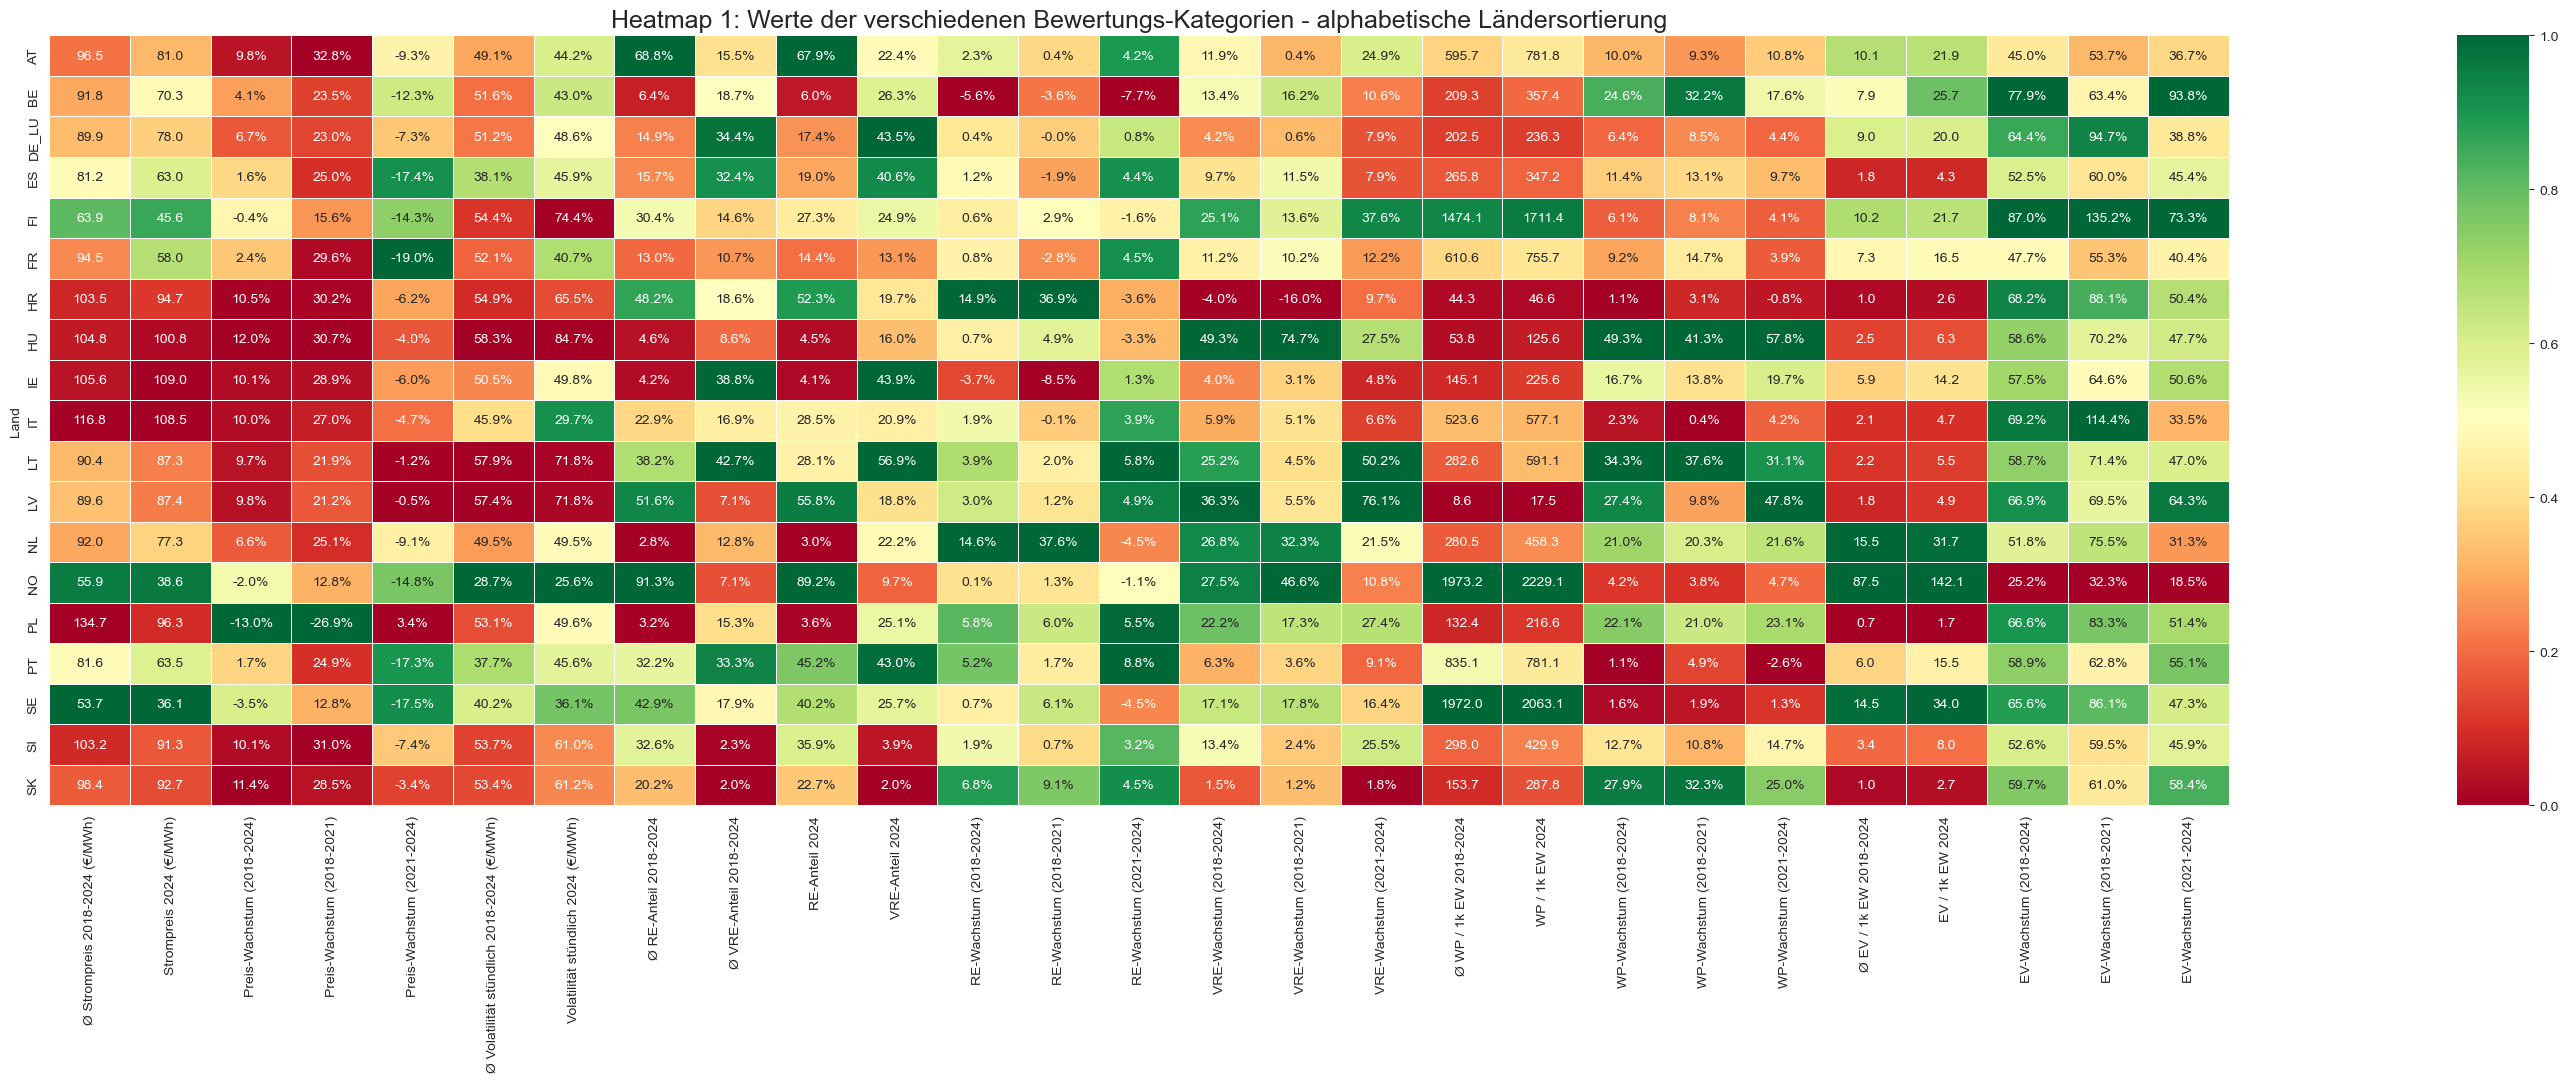

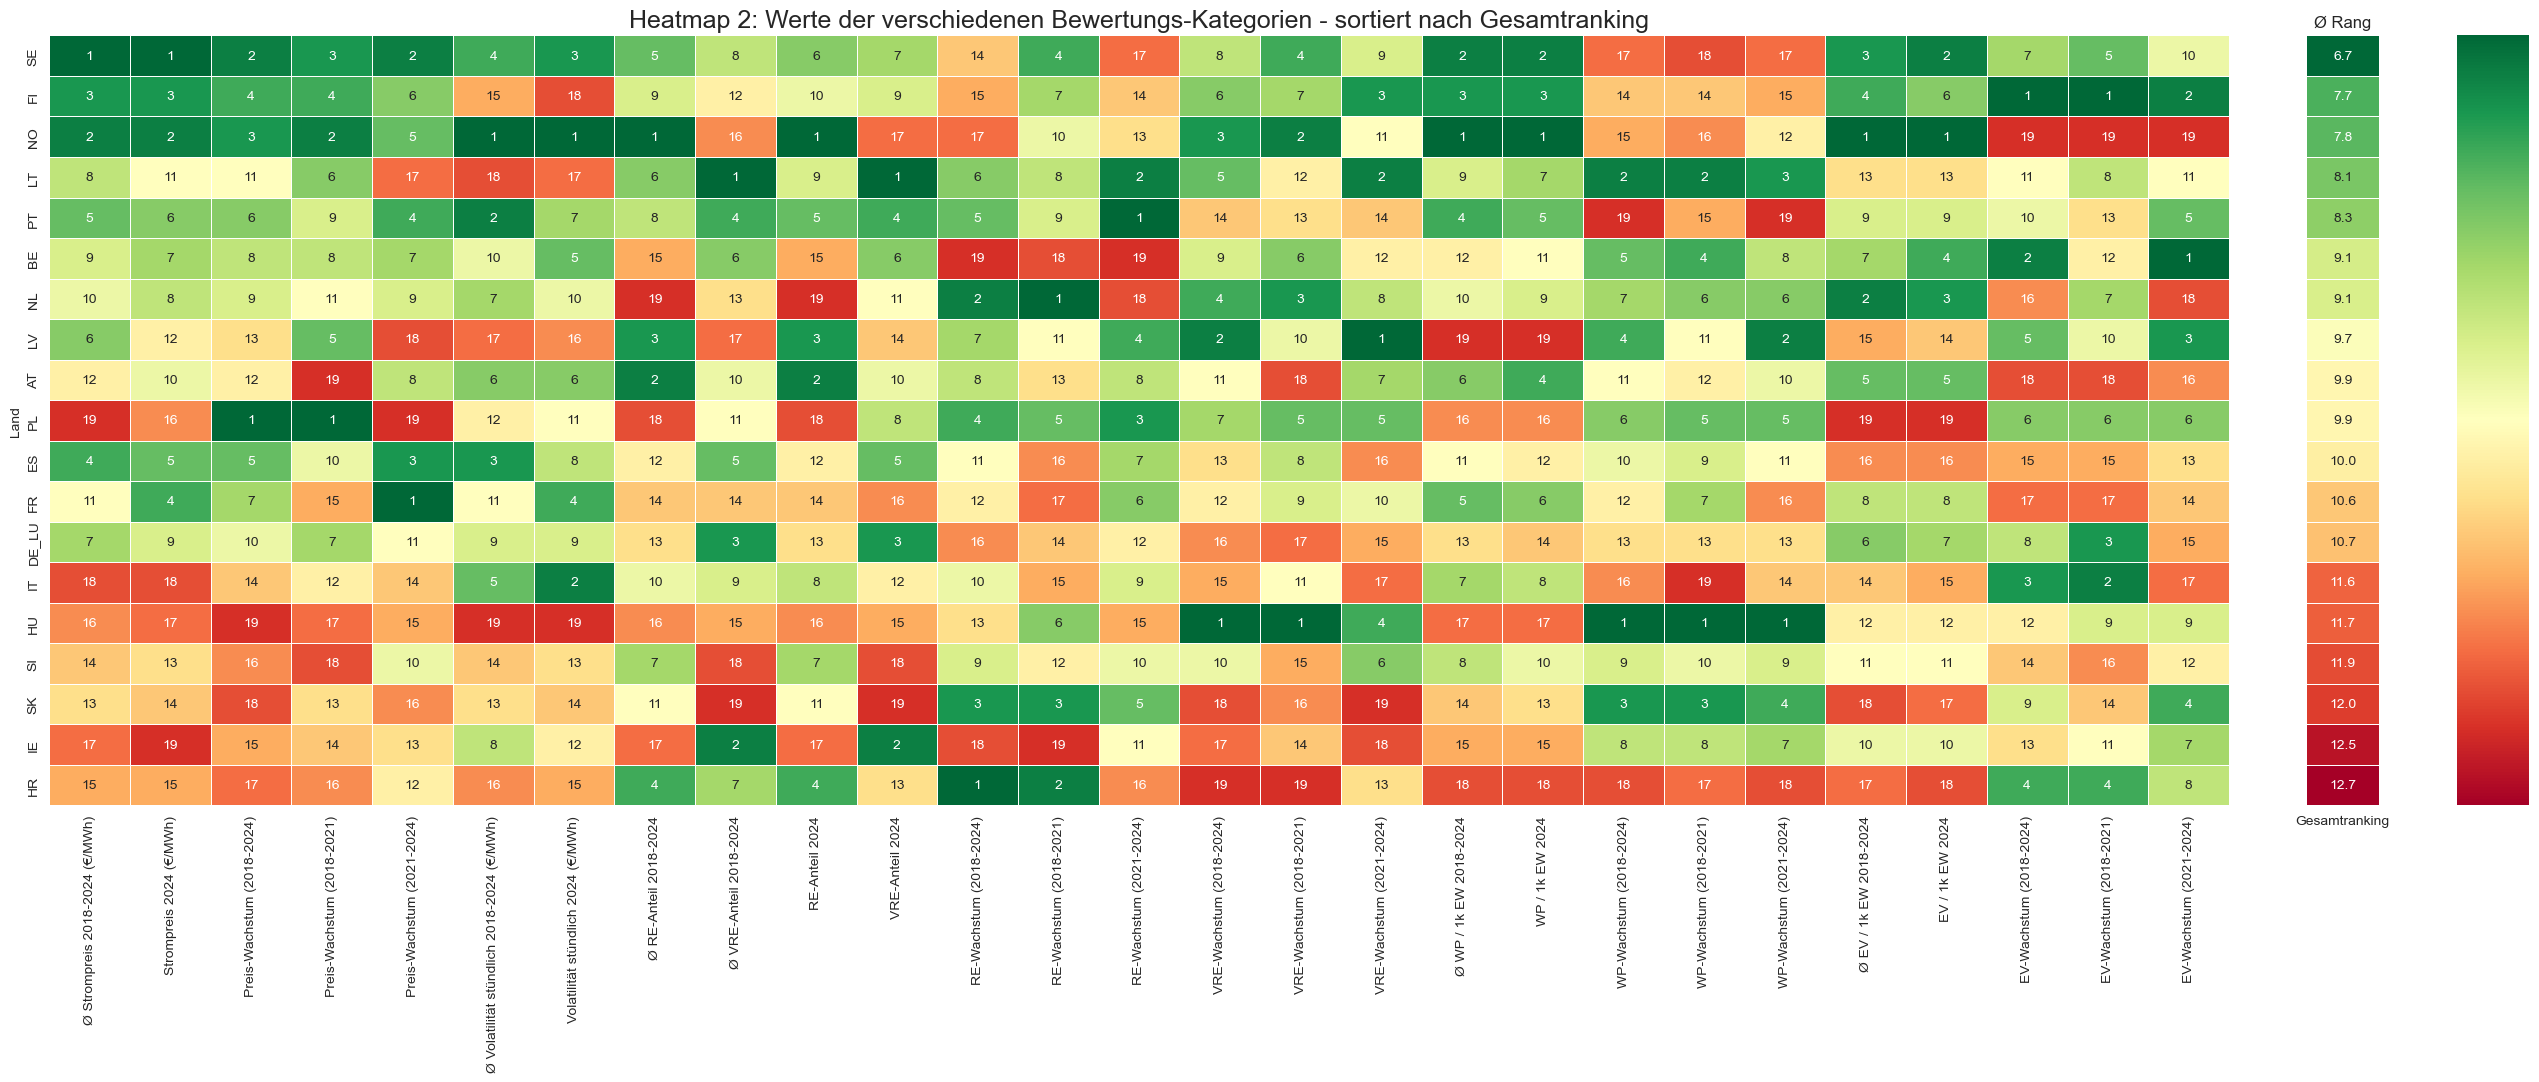

In [112]:
# Namens-Mapping
rename_dict = {
    'Price_Avg_2018-2024': 'Ø Strompreis 2018-2024 (€/MWh)',
    'Price_2024': 'Strompreis 2024 (€/MWh)',
    
    'Price_CAGR_2018-2024': 'Preis-Wachstum (2018-2024)',
    'Price_CAGR_2018-2021': 'Preis-Wachstum (2018-2021)',
    'Price_CAGR_2021-2024': 'Preis-Wachstum (2021-2024)',

    
    'Vol_Hourly_Avg_2018-2024': 'Ø Volatilität stündlich 2018-2024 (€/MWh)',
    'Vol_Hourly_2024': 'Volatilität stündlich 2024 (€/MWh)',

    
    'RE_Share_Avg_2018-2024': 'Ø RE-Anteil 2018-2024',
    'VRE_Share_Avg_2018-2024': 'Ø VRE-Anteil 2018-2024',
    'RE_Share_2024': 'RE-Anteil 2024',
    'VRE_Share_2024': 'VRE-Anteil 2024',
    
    'Gen_RE_CAGR_2018-2024': 'RE-Wachstum (2018-2024)',
    'Gen_RE_CAGR_2018-2021': 'RE-Wachstum (2018-2021)',
    'Gen_RE_CAGR_2021-2024': 'RE-Wachstum (2021-2024)',
    'Gen_VRE_CAGR_2018-2024': 'VRE-Wachstum (2018-2024)',
    'Gen_VRE_CAGR_2018-2021': 'VRE-Wachstum (2018-2021)',
    'Gen_VRE_CAGR_2021-2024': 'VRE-Wachstum (2021-2024)',

    
    'WP_1k_Avg_2018-2024': 'Ø WP / 1k EW 2018-2024',
    'WP_1k_2024': 'WP / 1k EW 2024',
    
    'WP_CAGR_2018-2024': 'WP-Wachstum (2018-2024)',
    'WP_CAGR_2018-2021': 'WP-Wachstum (2018-2021)',
    'WP_CAGR_2021-2024': 'WP-Wachstum (2021-2024)',

    
    'EV_1k_Avg_2018-2024': 'Ø EV / 1k EW 2018-2024',
    'EV_1k_2024': 'EV / 1k EW 2024',
    
    'EV_CAGR_2018-2024': 'EV-Wachstum (2018-2024)',
    'EV_CAGR_2018-2021': 'EV-Wachstum (2018-2021)',
    'EV_CAGR_2021-2024': 'EV-Wachstum (2021-2024)'
}

display_df = price_vol_generation_hp_e_veh_yearly_df.rename(columns=rename_dict)

# Prozent-Korrektur
cols_to_fix = [col for col in display_df.columns if any(x in col for x in ['Anteil', 'Volatilität', 'Wachstum'])]
for col in cols_to_fix:
    if display_df[col].abs().mean() > 1:
        display_df[col] = display_df[col] / 100


# Ranking berechnen
# Bei diesen Kategorien sind niedrigere Werte besser: Strompreis, Volatilität, Preis-Wachstum
cols_low_good = [col for col in display_df.columns if any(x in col for x in ['Strompreis', 'Volatilität', 'Preis-Wachstum'])]

# Bei allen anderen Kategorien sind höhere Werte besser (z.B. Wachstumsraten)
# skipna=True sorgt dafür, dass Länder mit fehlenden Werten nicht bestraft werden
rank_df = display_df.rank(ascending=True, method='min') 
cols_high_good = [col for col in display_df.columns if col not in cols_low_good]
for col in cols_high_good:
    rank_df[col] = display_df[col].rank(ascending=False, method='min')

# Gesamtranking: Durchschnitt bilden
rank_df['Gesamtranking'] = rank_df[list(rename_dict.values())].mean(axis=1)


# Graphik 1: Absolute Werte (alphabetische Ländersortierung)
fig1 = plt.figure(figsize=(32, 10))
gs1 = gridspec.GridSpec(1, 3, width_ratios=[30, 1, 1], wspace=0.1) 
ax1 = plt.subplot(gs1[0])
ax_cbar1 = plt.subplot(gs1[2])

abs_final_df = display_df.sort_index(ascending=True)
annot_abs = abs_final_df.copy().astype(object)
for col in abs_final_df.columns:
    # Richtige Darstellung der Prozentwerte
    if any(x in col for x in ['Anteil', 'Volatilität', 'Wachstum']):
        annot_abs[col] = abs_final_df[col].apply(lambda x: f"{x*100:.1f}%" if pd.notnull(x) else "")
    else:
        annot_abs[col] = abs_final_df[col].apply(lambda x: f"{x:.1f}" if pd.notnull(x) else "")

# Normierung über Min.-Max.-Skalierung: Verwendung des 90%-Quantils anstatt des Maximums zur Vermeidung der Dominanz von Ausreißern
norm_df = abs_final_df.apply(lambda x: (x - x.min()) / (x.quantile(0.9) - x.min())).clip(0, 1)

# Umgekehrte Reihenfolge für die Kategorien, in denen niedrigere Werte besser sind
for col in cols_low_good: norm_df[col] = 1 - norm_df[col]

sns.heatmap(norm_df, annot=annot_abs, fmt="", cmap="RdYlGn", linewidths=.5, ax=ax1, cbar_ax=ax_cbar1)
ax1.set_title('Heatmap 1: Werte der verschiedenen Bewertungs-Kategorien - alphabetische Ländersortierung', fontsize=18)


# Graphik 2: Ranking, sortiert nach Gesamtranking (Durchschnitt)
fig2 = plt.figure(figsize=(32, 10))
gs2 = gridspec.GridSpec(1, 3, width_ratios=[30, 1, 1], wspace=0.1)
ax2_main = plt.subplot(gs2[0])
ax2_sum = plt.subplot(gs2[1])
ax2_cbar = plt.subplot(gs2[2])

rank_sorted_df = rank_df.sort_values('Gesamtranking', ascending=True)
main_ranks_df = rank_sorted_df.drop(columns=['Gesamtranking'])
sum_column = rank_sorted_df[['Gesamtranking']]

sns.heatmap(main_ranks_df, annot=True, fmt=".0f", cmap="RdYlGn_r", linewidths=.5, ax=ax2_main, cbar=False, vmin=1, vmax=21)

# Gesamtranking Spalte: Invertiertes Farbschema für die Legende (Grün = niedriger Score = gut)
sns.heatmap(sum_column, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=.5, ax=ax2_sum, cbar_ax=ax2_cbar, cbar_kws={"ticks": []})

ax2_cbar.invert_yaxis()
ax2_main.set_title('Heatmap 2: Werte der verschiedenen Bewertungs-Kategorien - sortiert nach Gesamtranking', fontsize=18)
ax2_sum.set_title('Ø Rang', fontsize=12)
ax2_sum.set_yticks([]); ax2_sum.set_ylabel('')

plt.show()

**Analyse der heatmap über alle Kategorien:**
- Im Gesamtranking über alle Kategorien sind an den Top-Positionen vor allem nordische Länder: Schweden, Finnland und Norwegen auf Rang 1-3
- Hier ist bereits ein Muster erkennbar: hohe Positionierungen im Bestand (dunkelgrün) folgen eher niedrige Positionierungen im Wachstum (gelb-rot)
- Anschaulich wird dies am Beispiel Norwegen: Top-Position bei den Elektroautos, aber letzter Platz beim Elektroauto-Wachstum. Dies ist logisch zu erklären: die Mobilitätswende hin zu Elektroautos ist in Norwegen fast vollständig, daher geht ein sehr hoher Bestand mit einer sehr niedrigen Wachstrumsrate ein, da der Markt bereits gesättigt ist.
- Auf den letzten Rängen sind v.a. Länder Ost-Mitteleuropas (Ungarn, Slowenien, Slowakei) sowie Italien und Irland
- Die grünen und roten Felder (gute und schlechte Positionierungen) sind über die gesamte heatmap verteilt, es scheint also keine reinen "Musterschüler" und "schwarze Schafe" zu geben

Um dies besser zu veranschaulichen und zu analysieren, wie sich der Gesamtranking-Wert zusammensetzt, werden die Spannweiten (beste + schlechteste Platzierung) der Länder in einem dumbbell-Plot aufgetragen:

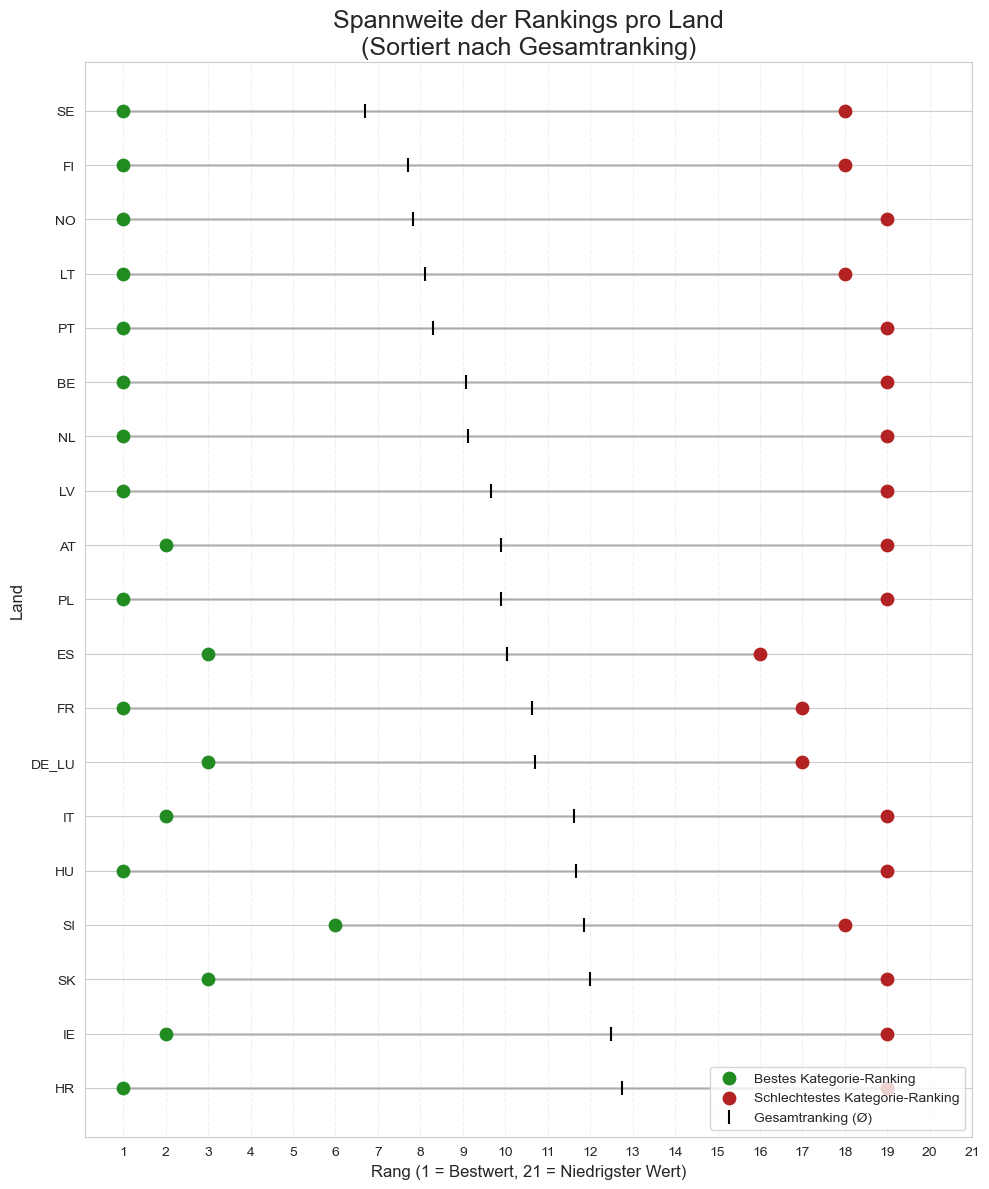

In [113]:
# Daten vorbereiten
# Extrahieren von Min und Max pro Zeile
rank_cols = [col for col in rank_sorted_df.columns if col != 'Gesamtranking']
range_df = pd.DataFrame(index=rank_sorted_df.index)
range_df['min']  = rank_sorted_df[rank_cols].min(axis=1)
range_df['max']  = rank_sorted_df[rank_cols].max(axis=1)
range_df['mean'] = rank_sorted_df['Gesamtranking']

# Sortierung umkehren für die Grafik (damit Platz 1 oben steht)
range_df = range_df.iloc[::-1]


# Visualisierung
plt.figure(figsize=(10, 12))

# Horizontale Linien (die Stange der Hantel)
plt.hlines(y=range_df.index, xmin=range_df['min'], xmax=range_df['max'], color='grey', alpha=0.4, linewidth=2)

# Punkte für das Minimum: bestes Ranking in einer Kategorie
plt.scatter(range_df['min'], range_df.index, color='forestgreen', label='Bestes Kategorie-Ranking', s=80, zorder=3)

# Punkte für das Maximum: schlechtestes Ranking in einer Kategorie
plt.scatter(range_df['max'], range_df.index, color='firebrick', label='Schlechtestes Kategorie-Ranking', s=80, zorder=3)

# Durchschnittspunkt als Querstrich: Gesamtranking
plt.scatter(range_df['mean'], range_df.index, color='black', marker='|', label='Gesamtranking (Ø)', s=100, zorder=4)

# Formatierung
plt.title('Spannweite der Rankings pro Land\n(Sortiert nach Gesamtranking)', fontsize=18)
plt.xlabel('Rang (1 = Bestwert, 21 = Niedrigster Wert)', fontsize=12)
plt.ylabel('Land', fontsize=12)
plt.xticks(range(1, 22))
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

**Analyse des dumbbell-plots über alle Kategorien:** 
- Diese Analyse bestätigt den ersten Analyseeindruck der heatmap: es gibt keine reinen "schlechten" und "guten" Länder
- Bis auf Slowenien hat jedes Land bei mindestens einer Kategorie einen Platz in der Top 3
- Umgekehrt hat jedes Land (bis auf Spanien) mindestens in einer Kategorie einen der 3 schlechtesten Platzierungen
- Die Verteilung ist also sehr breit für alle Länder, die Unterschiede im Durchschnitt ergeben sich dementsprechend aus der Häufigkeitsverteilung der Platzierungen in den verschiedenen Kategorien innerhalb dieser sehr breiten Min-Max-Spannweite

In der heatmap wurden die Werte für die einzelnen Vergleichsvariablen in absoluten Werten berechnet. Dadurch ist sowohl der minimale als auch der maximale Wert zu ermitteln (dunkelgrünes und dunkelrotes Feld).
Mithilfe der Bewertungsmatrix (Rang 1-19) konnten die Länder sortiert werden, jedoch sind dadurch die absoluten Werte der Vergleichsvariablen verloren gegangen.

In beiden Darstellungsformen kann jedoch nicht die Verteilung innerhalb der Vergleichsvariablen dargestellt werden.
Dies ist jedoch eine wichtige Information zur Beantwortung der folgenden Fragen, welche wiederum wichtig sind um die Länder in Cluster einzuteilen:
- Wie breit ist die Verteilung? Sind die meisten Länder eng um den Median angeordnet oder weit um ihn herum verteilt?
- Gibt es Ausreißer, und wenn ja wie weit weg vom Median sind sie?
- Unterscheidet sich der Mittelwert stark vom Median? Damit lässt sich die Schiefe einer Verteilung ableiten

Der Fokus ist hierbei auf die Verteilung innerhalb der Variablen, auf die Länder wird im einzelnen in den Detail-heatmaps danach eingegangen.

Um die Verteilung der Länder innerhalb der einzelnen Variablen zu visualisieren, werden für alle Vergleichsvariablen boxplots erstellt:

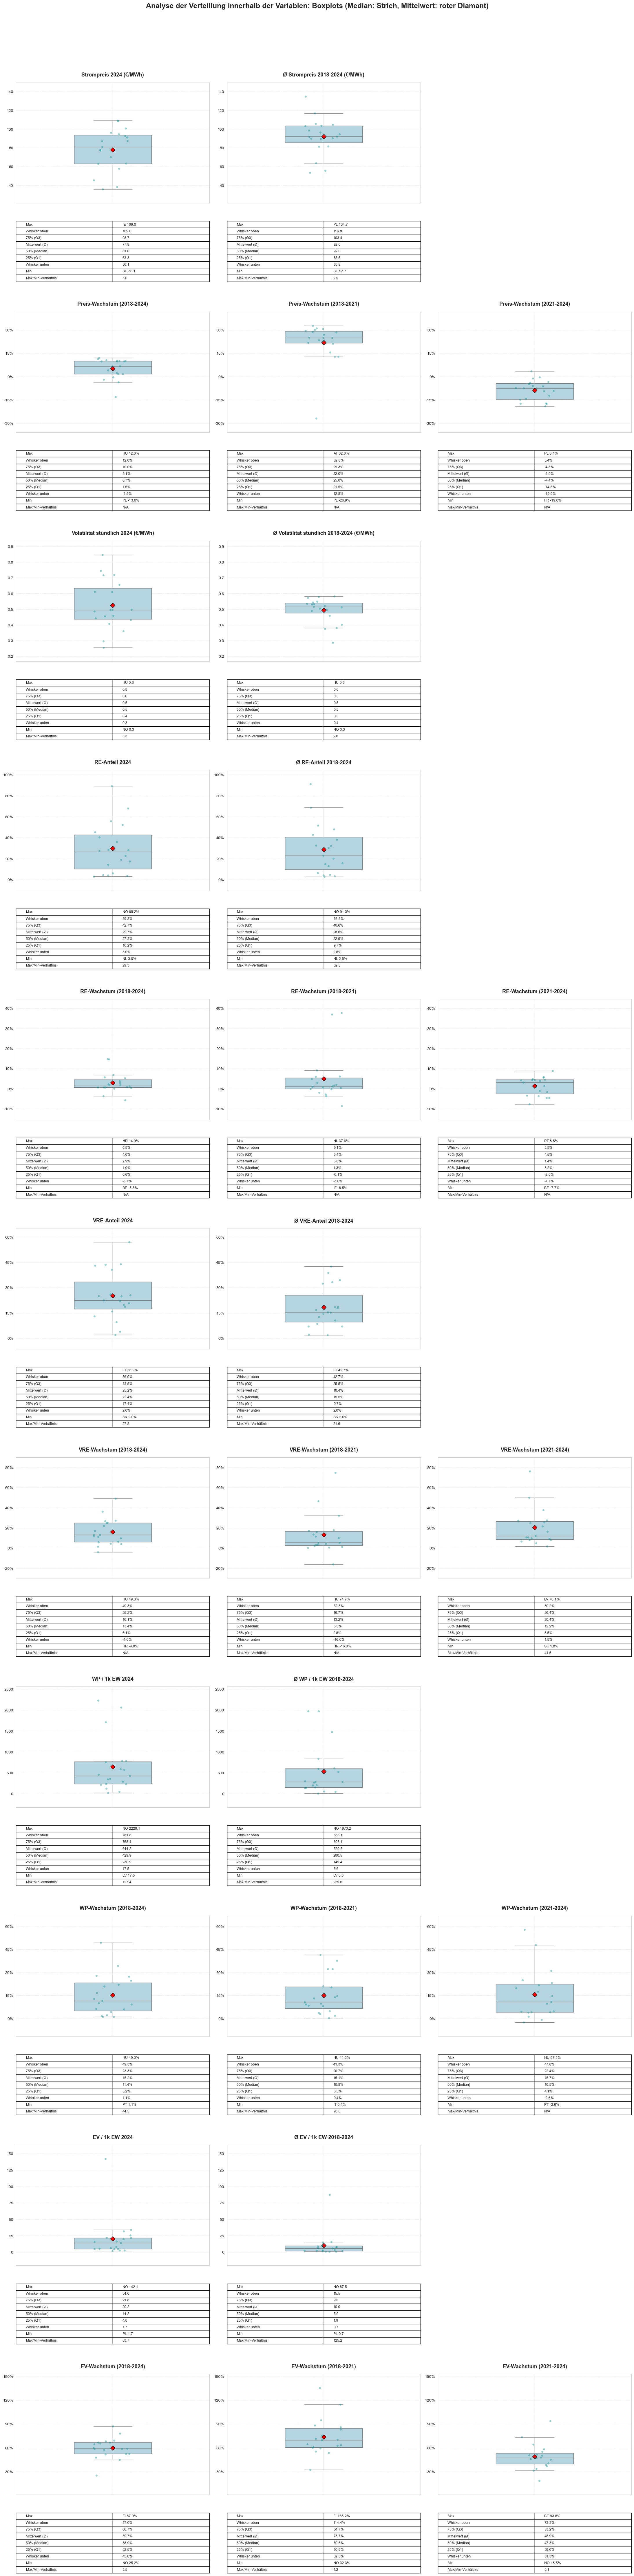

In [114]:
# Definition der Zeilen nach Kategorien (Strompreis, RE, VRE, WP...)
rows_definition = [
    ['Strompreis 2024 (€/MWh)', 'Ø Strompreis 2018-2024 (€/MWh)'],
    ['Preis-Wachstum (2018-2024)', 'Preis-Wachstum (2018-2021)', 'Preis-Wachstum (2021-2024)'],
    
    ['Volatilität stündlich 2024 (€/MWh)', 'Ø Volatilität stündlich 2018-2024 (€/MWh)'],
    
    ['RE-Anteil 2024', 'Ø RE-Anteil 2018-2024'],
    ['RE-Wachstum (2018-2024)', 'RE-Wachstum (2018-2021)', 'RE-Wachstum (2021-2024)'],
    
    ['VRE-Anteil 2024', 'Ø VRE-Anteil 2018-2024'],
    ['VRE-Wachstum (2018-2024)', 'VRE-Wachstum (2018-2021)', 'VRE-Wachstum (2021-2024)'],
    
    ['WP / 1k EW 2024', 'Ø WP / 1k EW 2018-2024'],
    ['WP-Wachstum (2018-2024)', 'WP-Wachstum (2018-2021)', 'WP-Wachstum (2021-2024)'],
    
    ['EV / 1k EW 2024', 'Ø EV / 1k EW 2018-2024'],
    ['EV-Wachstum (2018-2024)', 'EV-Wachstum (2018-2021)', 'EV-Wachstum (2021-2024)']
]

# Figure-Setup
num_rows = len(rows_definition)
fig, axes = plt.subplots(num_rows, 3, figsize=(22, num_rows * 8.5)) # Höhe leicht erhöht für die extra Tabellenzeile

for row_idx, row_categories in enumerate(rows_definition):
    
    # Gemeinsame y-Achsen-Grenzen für die Zeile ermitteln
    row_values = display_df[row_categories].values.flatten()
    row_values = row_values[~pd.isna(row_values)]
    
    if len(row_values) > 0:
        y_min, y_max = row_values.min(), row_values.max()
        padding = (y_max - y_min) * 0.15 
        y_limits = (y_min - padding, y_max + padding)

    # Zeichnen der 3 Diagramme pro Zeile
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]

        if col_idx < len(row_categories):
            cat = row_categories[col_idx]
            data_series = display_df[cat].dropna()
            
            # Boxplot: ohne Ausreißer-Punkte des Boxplots
            sns.boxplot(y=display_df[cat], ax=ax, color="lightblue", width=0.4, showfliers=False, # showfliers=False: Standard-Ausreißerpunkte deaktiviert
                        showmeans=True, # Aktiviert den Mittelwert-Marker
                        meanprops={"marker":"D", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":8}) # Setzen und formatieren des Mittelwerts
            
            # Stripplot für bessere Übersichtlichkeit der einzelnen Länderpunkte
            sns.stripplot(y=display_df[cat], ax=ax, color="darkcyan", alpha=0.4, size=5, jitter=True)
            ax.set_ylim(y_limits)
            
            # Statistik berechnen
            box_stats = data_series.describe()
            mean_val = data_series.mean()
            iqr = box_stats['75%'] - box_stats['25%']
            upper_whisker = data_series[data_series <= box_stats['75%'] + 1.5 * iqr].max()
            lower_whisker = data_series[data_series >= box_stats['25%'] - 1.5 * iqr].min()
            
            max_country = data_series.idxmax()
            min_country = data_series.idxmin()

            # Verhältnis zwischen Land mit maximalem und Land mit minimalem Wert berechnen
            if box_stats['min'] > 0:
                max_min_ratio = box_stats['max'] / box_stats['min']
                max_min_ratio = f"{max_min_ratio:.1f}"
            else:
                max_min_ratio = "N/A"

            # Formatierung der Prozentwerte
            is_pct = any(x in cat for x in ['Anteil', 'Wachstum'])
            fmt = lambda x: f"{x*100:.1f}%" if is_pct else f"{x:.1f}"
            
            # Daten für die Statistiktabelle
            table_data = [
                ["Max", f"{max_country} {fmt(box_stats['max'])}"],
                ["Whisker oben", fmt(upper_whisker)],
                ["75% (Q3)", fmt(box_stats['75%'])],
                ["Mittelwert (Ø)", fmt(mean_val)],
                ["50% (Median)", fmt(box_stats['50%'])],
                ["25% (Q1)", fmt(box_stats['25%'])],
                ["Whisker unten", fmt(lower_whisker)],
                ["Min", f"{min_country} {fmt(box_stats['min'])}"],
                ["Max/Min-Verhältnis", max_min_ratio]
            ]
            
            # Tabelle erstellen
            table = ax.table(cellText=table_data, loc='bottom', cellLoc='left', bbox=[0.0, -0.65, 1.0, 0.5])
            table.auto_set_font_size(False)
            table.set_fontsize(9)
            
            # Formatierung des Diagramms
            ax.set_title(cat, fontsize=13, fontweight='bold', pad=15)
            ax.set_ylabel('')
            ax.grid(True, linestyle=':', alpha=0.7)

            # Formatierung für Prozentwerte
            if is_pct:
                ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
                ticks_loc = ax.get_yticks()
                ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_loc))
                ax.set_yticklabels([f'{x*100:.0f}%' for x in ticks_loc])
                
        # Wenn nur 2 Diagramme enthalten sind, werden nur 2 anstatt 3 gezeichnet
        else:
            ax.axis('off')

plt.suptitle('Analyse der Verteilung innerhalb der Variablen: Boxplots (Median: Strich, Mittelwert: roter Diamant)', fontsize=18, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.9)
plt.show()

**Analyse des boxplots über alle Kategorien:**  

<u>Strompreis:</u>
- Der Median liegt 2024 mit ca. 81€/MWh unter dem langfristigen Median von 92€/MWh, dies hängt an dem starken Rückgang der Strompreise nach dem Ende der Energiekriese von Mitte 2021 bis ca. Anfang 2023. Dies war in Kapitel 3.1 im Zeitverlauf bereits gut ersichtlich
- Die Verteilung der Strompreise ist 2024 breiter als im langjährigen Schnitt, 2024 liegen 50% der Länder zwischen 63-74€/MWh (2018-2024: 86-103€/MWh)
- Dennoch ist die Spanne zwischen den günstigsten und den teuersten Ländern enorm: 2,5 (2018-2024) bzw. 3,3 (2024). Die Volatilität liegt damit deutlich über dem langjährigen Durchschnitt und ist nach der Energiekrise nicht auf ihr altes Niveau zurück gekehrt, was bereits in Kapitel 3.1.1 ersichtlich war

<u>Strompreis-Wachstum:</u>
- Im Gegensatz zu den absoluten Strompreisen hat sich das Strompreiswachstum in einem relativ engen Band bewegt

<u>Strompreis-Volatilität:</u>
- Wie auch der Strompreis weist die Volatilität eine sehr breite Verteilung zwischen Minimum und Maximum auf: 2,0 (2018.2024) bzw. 2,9 (2024)
<br>

<u>RE-Anteil:</u>
- Die Verteilung der RE-Anteile hat sich 2024 ggü. dem langjährigen Durchschnitt kaum geändert
- Die Verteilung ist zudem extrem breit: das Verhältnis von minimalem zu maximalem RE-Anteil beträgt konstant fast 30
- Getrieben wird dies durch den enormen Ausreißerwert Norwegen mit ca. 90% RE-Anteil an der Gesamtstromerzeugung
- 50% der Länder weisen 2024 einen RE-Anteil von 10-43% auf

<u>RE-Wachstum:</u>
- Die Verteilung der RE-Wachstumsraten ist weniger breit verteilt als die RE-Anteilswerte und hat sich 2018-2024 zwischen 0,6-4,6% (50% der Länder) bzw. -6% bis 15% (Min.-Max.-Spanne) befunden
- Ca. 25% der Länder weisen in diesem Zeitraum einen Rückgang der RE-Erzeugung auf. Dies liegt nicht an einer Reduktion des Kraftwerksparks, sondern an den Umweltbedingungen (z.B. trockene Jahre, welche die Wasserkrafterzeugung reduzieren)
<br>

<u>VRE-Anteil:</u>
- Im Gegensatz zu den RE hat sich die VRE-Erzeugungsleistung 2024 ggü. dem langjährigen Durchschnitt von 18% (2018-2024) auf 25% erhöht
- Die Spreizung zwischen Minimal- und Maximalwert liegt geringfügig unter dem Wert für den RE-Anteil, nähert sich diesem aber an: von Faktor 22 (2018-2024) auf 28 (2024)
- Extremwerte (2024) waren 2% in der Slowakei und 57% in Litauen

<u>VRE-Wachstum:</u>
- Im Gegensatz zur den RE gibt es bei den VRE nur ein Land (Kroatien), welches in den Jahren 2018-2024 negatives VRE-Wachstum aufweist
- 50% der Länder weisen ein Wachstum von 6-25% auf (2018-2024); damit ist das VRE-Wachstum sehr viel variabler als das RE-Wachstum, welches sich wie dargstellt in einem sehr engen Band befindet
- Damit ist das VRE-Wachstum sowohl deutlich höher und weist auch eine breitere Verteilung auf als das RE-Wachstum
<br>

<u>WP-Bestand (aufgenommene Energie) / 1.000 Einwohner:</u>
- Die Verteilung ist deutlich rechtsschief: der Mittelwert ist mit 644 deutlich größer als der Median mit 430
- Verursacht wird dies durch lediglich 3 Ausreißer, angeführt von Norwegen mit 2230
- Das Min.-Max.-Verhältnis hat dadurch mit 127 den höchsten Wert aller untersuchten Variablen
- 50% der Länder haben Werte zwischen 230 - 770

<u>WP-Wachstum:</u>
- Das WP-Wachstum ist ebenfalls rechtsschief, aber weniger ausgeprägt als die Bestandszahlen, 50% der Länder weisen ein Wachstum von 5-23% auf (2018-2024)
<br>

<u>EV-Bestand / 1.000 Einwohner:</u>
- Die Verteilung des EV-Bestandes ist ebenfalls rechtsschief, aber etwas weniger stark als der WP-Bestand
- Getrieben wird dies von einem einzeigen Ausreißer, ebenfalls Norwegen mit 142 EV/1.000 EW (2024)
- 50% der Länder haben eine EV-Dichte von 5-22 EV/1.000EW (2024)

<u>EV-Wachstum:</u>
- Das Wachstum ist sehr symmetrisch (Mittelwert ~ Median)
- Das durchschnittliche Wachstum 2018-2024 betrug fast 60% p.a., mit einer Spanne zwischen dem am schnellsten wachsenden zum langsamst wachsenden Land von 87% vs. 25%. Interessanterweise ist hier der am langsamst wachsende Markt ausgerechnet Norwegen.



<br>
Diese Unterschiede zwischen den Bestandswerten und Wachstumsdnymiken werden nun genauer untersucht.  

Dafür wird die heatmap in zwei verschiedene heatmaps gesplittet:  
- Eine heatmap ausschließlich mit den Kategorien die den Bestand beschreiben: der Bestands-Monitor
- Eine heatmap die sich auf die Wachstums-Indikatoren konzentriert: der Wachstums-Monitor

## 4.2 Bestands-Monitor:

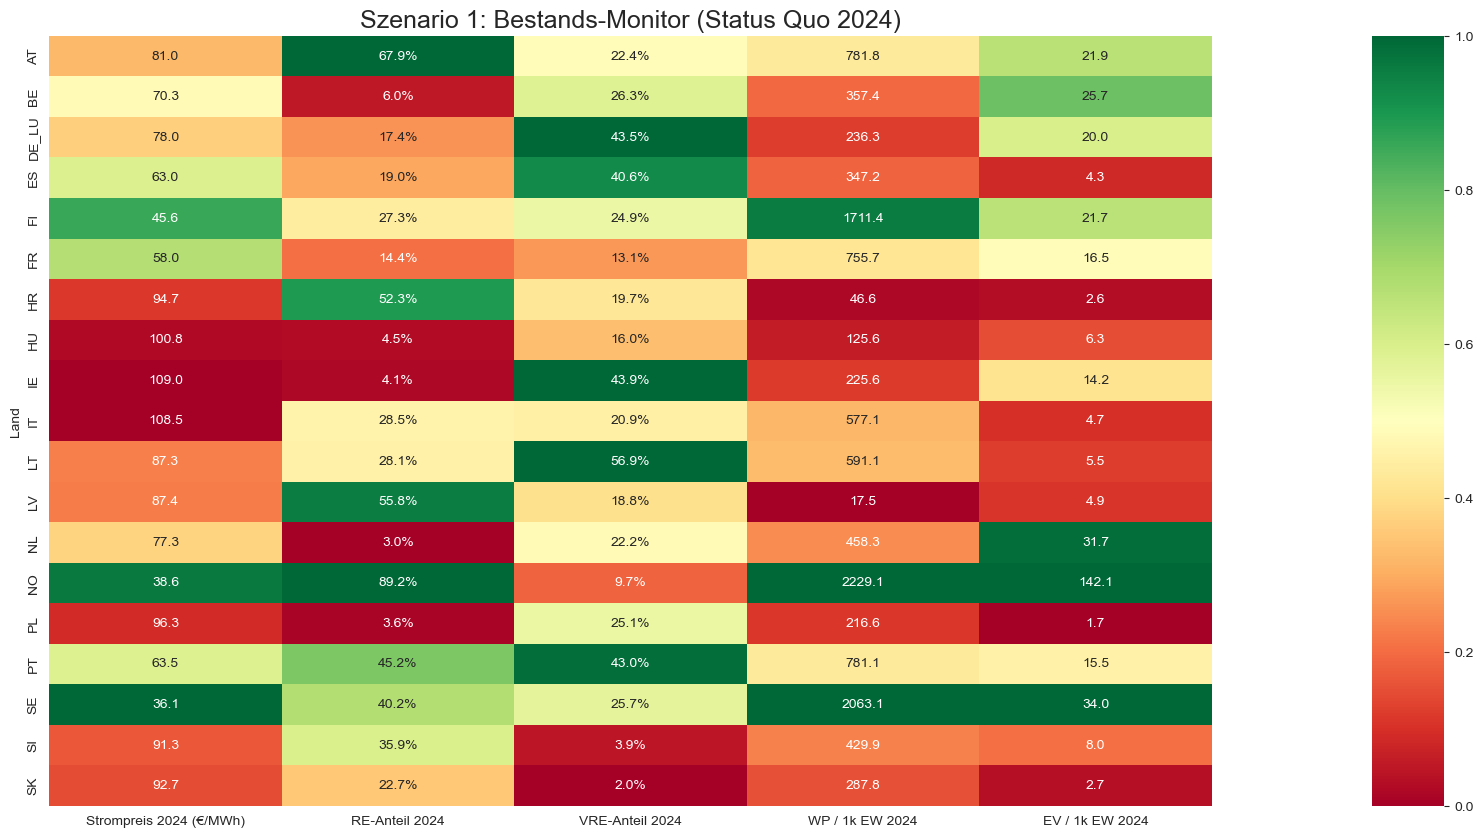

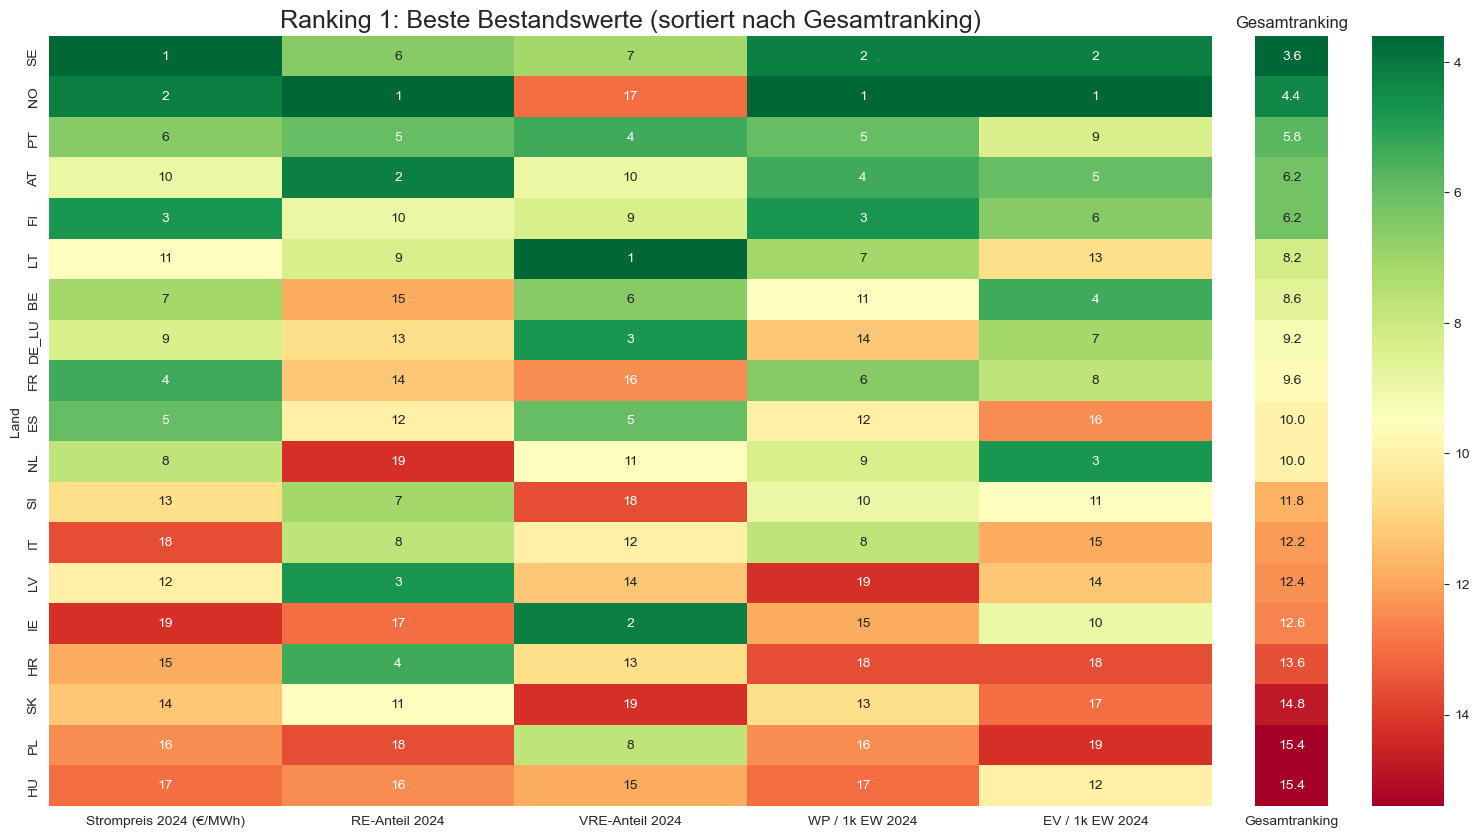

In [115]:
# Spaltenauswahl für Bestands-Monitor
cols_stock = [
    'Strompreis 2024 (€/MWh)', 
    'RE-Anteil 2024', 
    'VRE-Anteil 2024', 
    'WP / 1k EW 2024', 
    'EV / 1k EW 2024'
]

bestand_df = display_df[cols_stock].copy()

# Ranking berechnen
# Strompreis: niedrige Werte positiv
cols_low_good_b = ['Strompreis 2024 (€/MWh)']
rank_b_df = bestand_df.rank(ascending=True, method='min')
# Alle anderen Kategorien: höhere Werte positiv
cols_high_good_b = [col for col in bestand_df.columns if col not in cols_low_good_b]
for col in cols_high_good_b:
    rank_b_df[col] = bestand_df[col].rank(ascending=False, method='min')

rank_b_df['Gesamtranking'] = rank_b_df[cols_stock].mean(axis=1)


# Graphik 1: Absolute Werte (alphabetische Ländersortierung)
fig1 = plt.figure(figsize=(18, 10))
gs1 = gridspec.GridSpec(1, 3, width_ratios=[16, 1, 1], wspace=0.1) 
ax1, ax_c_abs = plt.subplot(gs1[0]), plt.subplot(gs1[2])

abs_b_df = bestand_df.sort_index(ascending=True)

# Normierung über Min.-Max.-Skalierung: Verwendung des 90%-Quantils anstatt des Maximums zur Vermeidung der Dominanz von Ausreißern
norm_b_df = abs_b_df.apply(lambda x: (x - x.min()) / (x.quantile(0.9) - x.min())).clip(0, 1)

# Umgekehrte Reihenfolge für die Kategorien, in denen niedrigere Werte besser sind
for col in cols_low_good_b: norm_b_df[col] = 1 - norm_b_df[col]

annot_b = abs_b_df.copy().astype(object)
# Richtige Darstellung der Prozentwerte
for col in abs_b_df.columns:
    annot_b[col] = abs_b_df[col].apply(lambda x: f"{x*100:.1f}%" if 'Anteil' in col else f"{x:.1f}")

sns.heatmap(norm_b_df, annot=annot_b, fmt="", cmap="RdYlGn", ax=ax1, cbar_ax=ax_c_abs)
ax1.set_title('Szenario 1: Bestands-Monitor (Status Quo 2024)', fontsize=18)


# Graphik 2: Ranking, sortiert nach Gesamtranking (Durchschnitt)
fig2 = plt.figure(figsize=(18, 10))
gs2 = gridspec.GridSpec(1, 3, width_ratios=[16, 1, 1], wspace=0.1)
ax2, ax2_s, ax2_c = plt.subplot(gs2[0]), plt.subplot(gs2[1]), plt.subplot(gs2[2])

r_sorted_b_df = rank_b_df.sort_values('Gesamtranking', ascending=True)
sns.heatmap(r_sorted_b_df.drop(columns='Gesamtranking'), annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax2, cbar=False, vmin=1, vmax=21)

# Gesamtranking-Spalte plotten ohne y-Achsen-Beschriftung (Länderkürzel)
sns.heatmap(r_sorted_b_df[['Gesamtranking']], annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax2_s, cbar_ax=ax2_c)
ax2_s.set_yticklabels([]) # Entfernt die Länderkürzel in der mittleren Spalte
ax2_s.set_ylabel('')

# Legende invertieren (Grün oben)
ax2_c.invert_yaxis()

ax2.set_title('Ranking 1: Beste Bestandswerte (sortiert nach Gesamtranking)', fontsize=18)
ax2_s.set_title('Gesamtranking', fontsize=12)
plt.show()

**Analyse des Bestand-Monitors:**
- Durch diese Darstellung der heatmap lassen sich nun die Länder mit dem höchsten Werten im Bestand analysieren
  
- Dominiert werden diese - wie auch bereits das Gesamtranking - von den nordischen Ländern, in der Top 5 sind 3 Länder aus dieser Region
- Schweden nimmt den 1. Rang ein, da Norwegen durch seinen sehr geringen VRE-Anteil im Gesamtranking zurückfällt.
- Dies ist durch Norwegens Geographie und Topographie zu erklären: seine nördliche Lage macht Solarkraftwerke sehr unrentabel, gleichzeitig ermöglicht seine Topographie ein sehr hohes Wasserkraftpotential (ähnliche wie Österreich auf Platz Nummer 4). Dadurch weist es den Spitzenplatz beim RE-Anteil auf, der VRE-Anteil ist jedoch sehr gering
- Diese Erklärung würde jedoch gleichermaßen auch auf Schweden und Finnland zutreffen (ähnliche Lage im Norden), trotzdem haben diese Länder höhere Platzierungen beim VRE-Anteil.
- Dies lässt sich folgendermaßen erklären: Da Norwegen aufgrund seiner Topographie aber über ein sehr hohes Wasserkraftpotential verfügt und damit fast 90% des Strombedarfes deckt, ist der verbleibende mögliche Anteil für VRE sehr niedrig. Schweden und Finnland weisen ein deutlich flacheres Relief und damit weniger Wasserkraftpotential auf, dadurch ist der RE-Anteil geringer (30-40%). Dies lässt entsprechend mehr "Platz" für einen höheren VRE-Anteil, dieser wird aber fast ausschließlich durch Windkraft gedeckt
  
- Eine interessante Erkenntnis ist Land Nummer 3, Portugal: hohe Werte bei den RE/VRE, bedingt durch seine südliche Küstenlage, ein relativ niedriger Strompreis sowie gute Positionierungen bei den Wärmepumpen und Elektroautos.
  
- Am anderen Ende der Skala befinden sich ausschließlich Länder Ost-Mitteleuropas: Slowenien, Kroatien, Polen, Ungarn und die Slowakei
- Sie weisen niedrige bis sehr niedrige RE- und VRE-Anteile und Wärmepumpen/EV-Durchdringung auf, zudem ist der Strompreis sehr hoch
- Dies lässt eine Vermutung zu: niedrige RE/VRE-Anteile führen zu hohen Strompreisen. Diese Hypothese wird in Kapitel 5 genauer untersucht.

Da eine rein tabellarische Auflistung der Platzierungen der Länder in den verschiedenen Katgegorien visuell schwer zu interpretieren ist, werden die Variablen RE- und VRE-Anteil, sowie WP und EV pro 1.000 Einwohner in einer einzigen Matrix dargstellt.  

Grundlage ist der RE- und VRE-Anteil auf der x-Achse und y-Achse: diese zeigen an, zu welchen Anteilen aus erneuerbaren Energie ein Land seinen Strom bezieht.  
Da in einer 2D-Visualisierung nur 2 Achsen zur Verfügung stehen, werden die Variablen WP- und EV-Anteil über farbige Kreise dargestellt:

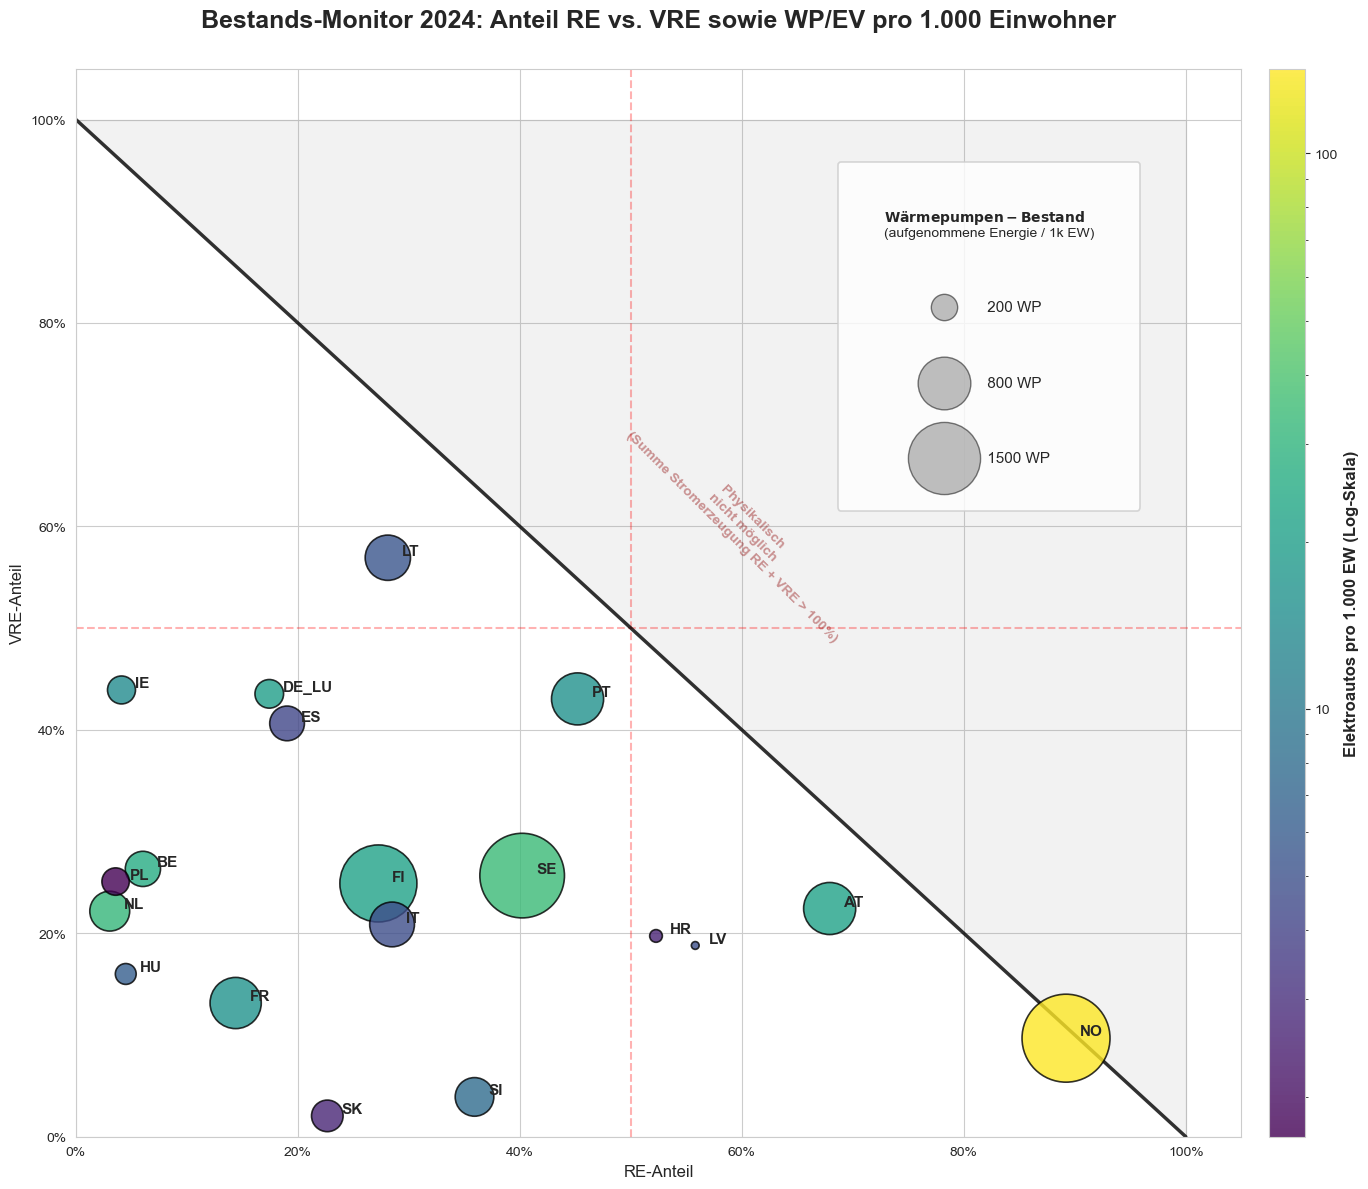

In [116]:
# Datenbasis
x = display_df['RE-Anteil 2024']
y = display_df['VRE-Anteil 2024']
size = display_df['WP / 1k EW 2024']
color = display_df['EV / 1k EW 2024']
countries = display_df.index

# Figure-Setup
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Farbskala: Logarithmische Normierung für maximale Differenzierung, da es bei EV und WP sehr große Unterschiede gibt (siehe boxplots) und die Farbunterschiede bei linearer Skalierung zu gering wären
vmin = max(color.min(), 1) 
vmax = color.max()
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# Scatterplot
scatter = plt.scatter(x, y, s=size*1.8, c=color, cmap='viridis', norm=norm, alpha=0.8, edgecolors='black', linewidth=1.2, zorder=3)

# Grenzen & Hilfslinien
plt.plot([0, 1], [1, 0], color='black', linestyle='-', alpha=0.8, linewidth=2.5, zorder=2)
plt.fill([0, 1, 1, 0], [1, 1, 0, 1], color='gray', alpha=0.1, zorder=1)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3, zorder=1)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.3, zorder=1)

# Ländernamen
for i, txt in enumerate(countries):
    plt.annotate(txt, (x.iloc[i], y.iloc[i]), xytext=(10, 2), textcoords='offset points', fontsize=11, fontweight='bold')

# Farbbalken (EV): ScalarFormatter erzeugt Zahlen anstatt Exponenten (10^0, 10^1 usw.) auf der y-Achse
cbar = plt.colorbar(scatter, pad=0.02, aspect=30)
cbar.set_label('Elektroautos pro 1.000 EW (Log-Skala)', fontsize=12, fontweight='bold')
cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Legende (WP): Beispielwerte für Blasen mit 200, 800, 1500 WP
for s in [200, 800, 1500]:
    plt.scatter([], [], c='gray', alpha=0.5, s=s*1.8, label=f' {s} WP', edgecolors='black')

leg = plt.legend(title="$\mathbf{Wärmepumpen-Bestand}$ \n(aufgenommene Energie / 1k EW)", 
                 loc="upper right", 
                 bbox_to_anchor=(0.92, 0.92),
                 frameon=True, 
                 fontsize=11, 
                 labelspacing=4.0, 
                 borderpad=3.0,    
                 handletextpad=1.5)
leg.get_frame().set_linewidth(1.2)

# Titel & Achsen
plt.title('Bestands-Monitor 2024: Anteil RE vs. VRE sowie WP/EV pro 1.000 Einwohner', fontsize=18, fontweight='bold', pad=30)
plt.xlabel('RE-Anteil', fontsize=12)
plt.ylabel('VRE-Anteil', fontsize=12)

# Achsen: Prozentwerte anstatt Dezimalwerte anzeigen
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Text "Physikalisch nicht möglich" für Werte oberhalb der 45° Diagonalen
plt.text(0.60, 0.60, "Physikalisch\nnicht möglich\n(Summe Stromerzeugung RE + VRE > 100%)", color='darkred', alpha=0.4, fontweight='bold', rotation=-45, ha='center', va='center')

plt.tight_layout()
plt.show()

**Analyse der Bestand-Monitor-Matrix:**  

In dieser Matrixdarstellung werden die in der Listendarstellung dargestellten Informationen nur sehr anschaulich visualisiert:
- Die 45°-Diagonale gibt die Gesamterzeugung aus erneuerbaren Energien (RE + VRE) an. Sie entspricht max. 100%, welche sich auf die beiden Anteile RE und VRE beliebig verteilen kann: je näher ein Land an dieser Geraden liegt, desto höher ist sein Anteil an erneuerbaren Energien
- Je größer der Kreis des Landes, desto höher ist der WP-Anteil / 1.000 Einwohner
- Je heller (lila => hellgrün => gelb) die Farbe des Kreises des Landes, desto höher ist der EV-Anteil / 1.000 Einwohner
<br>

<u>Stromerzeugung:</u>
- 4 Länder weisen einen sehr hohen Anteil an erneuerbaren Energien auf: Norwegen, Österreich, Portugal und Litauen
- Diese Länder lassen sich in Länder mit hohem RE-Anteil (Norwegen, Österreich: hauptsächlich Wasserkraft) und Länder mit hohem VRE-Anteil (Portugal, Litauen) einteilen
- Norwegen liegt fast auf der 45°-Diagonalen, was einen Anteil von RE+VRE von fast 100% bedeutet
- Österreich, Portugal und Litauen haben einen RE+VRE-Anteil von über 80%
- Auf der Gegenseite hat Ungarn einen Anteil von RE+VRE von nur 20%
- Der sehr niedrige RE+VRE-Anteil Frankreichs von ca. 25% lässt sich mit dem sehr hohen Atomstromanteil an der Gesamterzeugung erklären
<br>

<u>Elektrifizierung - Wärmepumpen:</u>
- Die 3 nordischen Länder Norwegen, Schweden und Finnland weisen die höchsten Wärmepumpendichten auf
<br>

<u>Elektrifizierung - Elektroautos:</u>
- Norwegen führt hier mit weitem Abstand, gefolgt von Schweden und den Niederlanden

## 4.3 Wachstums-Monitor:

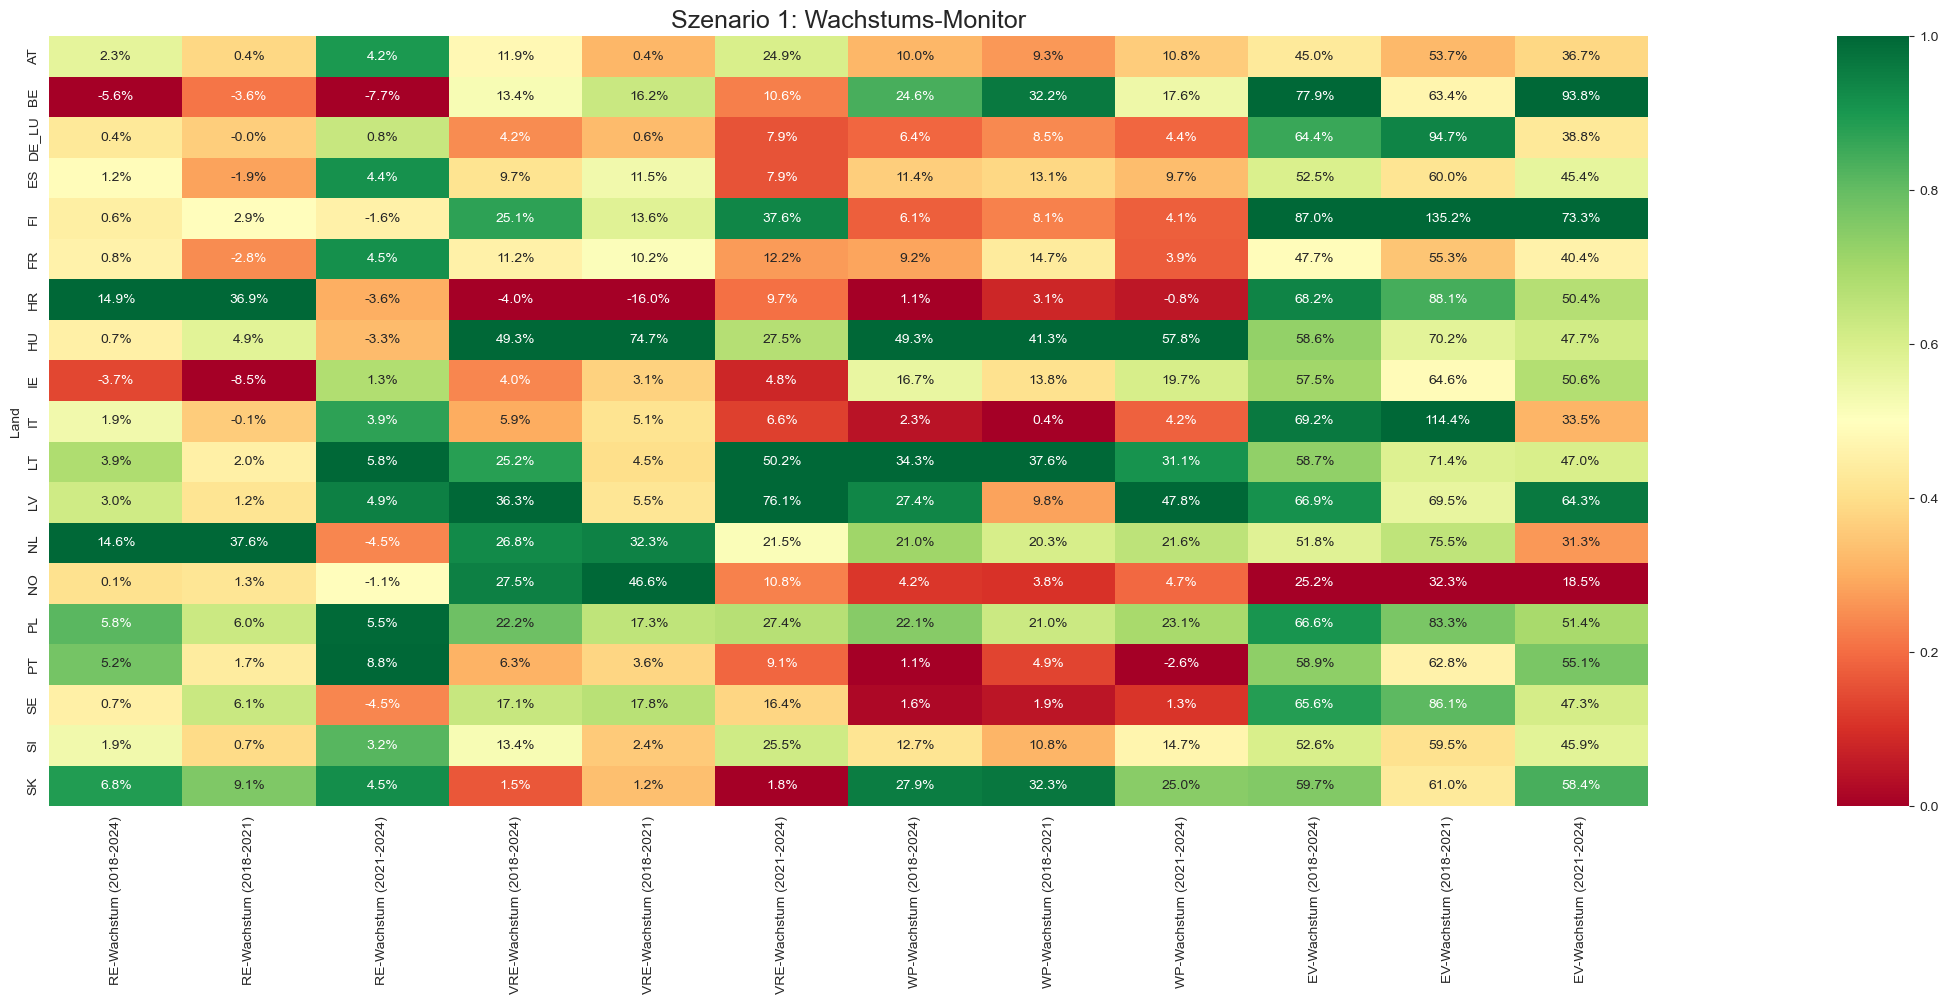

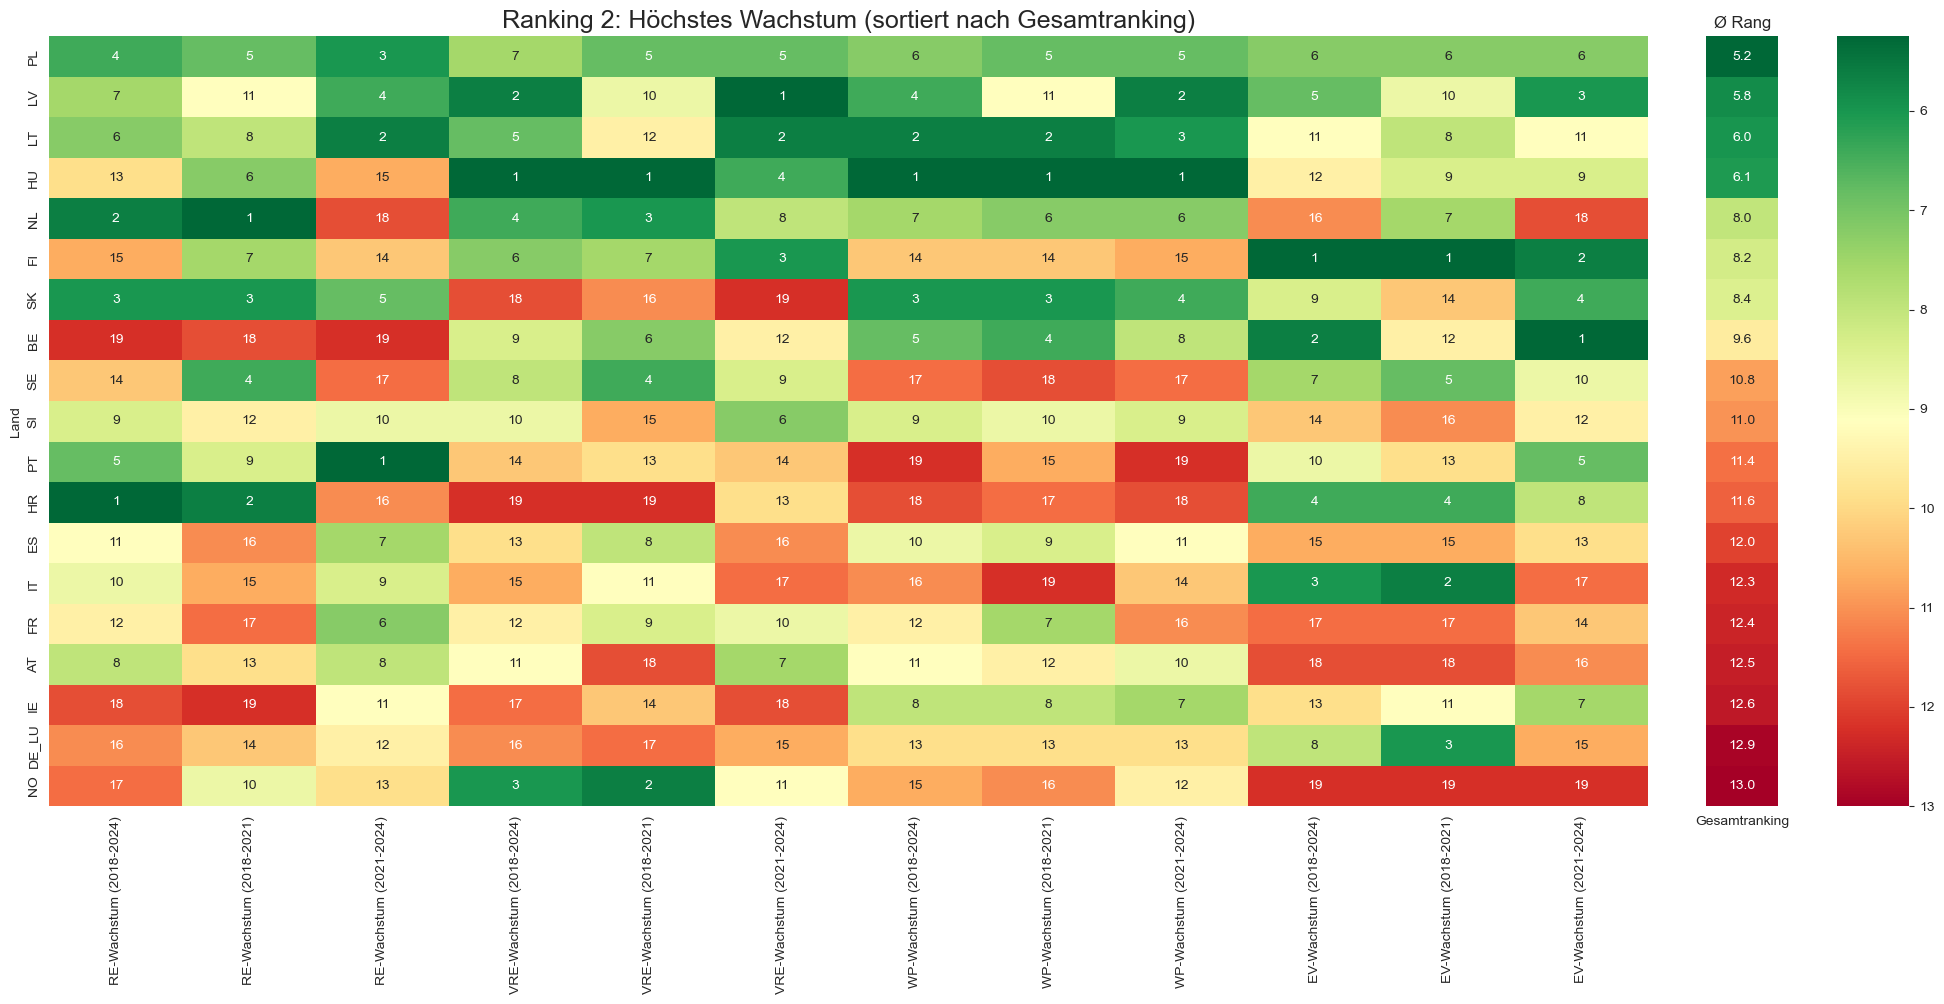

In [117]:
# Spaltenauswahl für Wachstums-Monitor
cols_growth = [col for col in display_df.columns if 'Wachstum' in col and 'Preis' not in col]
growth_df = display_df[cols_growth].copy()

# Ranking berechnen: Hier ist bei allen Kategorien ein höherer Wert positiv
rank_g_df = growth_df.rank(ascending=False, method='min')
rank_g_df['Gesamtranking'] = rank_g_df[cols_growth].mean(axis=1)


# Graphik 1: Absolute Werte (alphabetische Ländersortierung)
fig3 = plt.figure(figsize=(24, 10))
gs3 = gridspec.GridSpec(1, 3, width_ratios=[22, 1, 1], wspace=0.1) 
ax3, ax_c_abs_g = plt.subplot(gs3[0]), plt.subplot(gs3[2])

abs_g_df = growth_df.sort_index(ascending=True)
# Normierung über Min.-Max.-Skalierung: Verwendung des 90%-Quantils anstatt des Maximums zur Vermeidung der Dominanz von Ausreißern
norm_g_df = abs_g_df.apply(lambda x: (x - x.min()) / (x.quantile(0.9) - x.min())).clip(0, 1)

annot_g = abs_g_df.copy().astype(object)
# Richtige Darstellung der Prozentwerte
for col in abs_g_df.columns:
    annot_g[col] = abs_g_df[col].apply(lambda x: f"{x*100:.1f}%" if pd.notnull(x) else "")

sns.heatmap(norm_g_df, annot=annot_g, fmt="", cmap="RdYlGn", ax=ax3, cbar_ax=ax_c_abs_g)
ax3.set_title('Szenario 1: Wachstums-Monitor', fontsize=18)


# Graphik 2: Ranking, sortiert nach Gesamtranking (Durchschnitt)
fig4 = plt.figure(figsize=(24, 10))
gs4 = gridspec.GridSpec(1, 3, width_ratios=[22, 1, 1], wspace=0.1)
ax4, ax4_s, ax4_c = plt.subplot(gs4[0]), plt.subplot(gs4[1]), plt.subplot(gs4[2])

r_sorted_g_df = rank_g_df.sort_values('Gesamtranking', ascending=True)
sns.heatmap(r_sorted_g_df.drop(columns='Gesamtranking'), annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax4, cbar=False, vmin=1, vmax=21)

# Gesamtranking-Spalte plotten ohne y-Achsen-Beschriftung
sns.heatmap(r_sorted_g_df[['Gesamtranking']], annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax4_s, cbar_ax=ax4_c)
ax4_s.set_yticklabels([]) # Entfernt die Länderkürzel in der mittleren Spalte
ax4_s.set_ylabel('')

# Legende invertieren (Grün oben)
ax4_c.invert_yaxis()

ax4.set_title('Ranking 2: Höchstes Wachstum (sortiert nach Gesamtranking)', fontsize=18)
ax4_s.set_title('Ø Rang', fontsize=12)
plt.show()

**Analyse des Wachstums-Monitors:** 
- Ungarn und Polen, die beim Bestand auf Platz 18 und 17 (von 19) waren, befinden sich beim Wachstum auf Platz 1 und 4
- Ungarn ist der aktuelle Spitzenreiter im VRE- und Wärmepumpen-Wachstum, das EV-Wachstum ist aber nur durchschnittlich
- Polen weist durchweg durch alle Kategorien gute bis sehr gute Werte auf, wodurch es insgesamt auf den Spitzenplatz kommt

- Am anderen Ende der Skala befindet sich Norwegen, dass wie bereits beschrieben in der Transformation schon sehr weit vorangeschritten ist. Daher sind die Wachstumsraten fast durchgängig sehr gering. Eine Ausnahme ist das VRE-Wachstum: Dies legt die Vermutung nahe, dass das Wasserkraftpotential ausgeschöpft ist, und Norwegen versucht durch die Installation von VRE (ausschließlich Windkraft) die Dekarbonisierung des Stromsektors trotzdem weiter zu führen.
- Deutschland ist auf dem vorletzten Platz, was belegt, dass die bis vor einigen Jahren in der Öffentlichkeit als "Klimavorreiter" bezeichnete Rolle Deutschlands nicht mehr gilt
- Besonders zu beachten sind die Wachstumswerte von RE, VRE und WP: da diese Kategorien die Erzeugungsleistung bzw. Energie darstellen, sind diese für manche Länder in manchen Zeiträumen negativ. Dies liegt nicht an einer Reduktion des Kraftwerksparks, sondern an den Umweltbedingungen (sonnenarme Jahre, wenig Windkraftaufkommen, trockene Jahre (wenig Wasserkrafterzeugung) oder überdurchschnittlich warme Jahre, welche wenig Wärmepumpenleistung zum heizen erfordern)

Analog zur Bestands-Monitor-Matrix wird im Folgenden auch der Wachstums-Monitor in einer Matrix dargestellt:

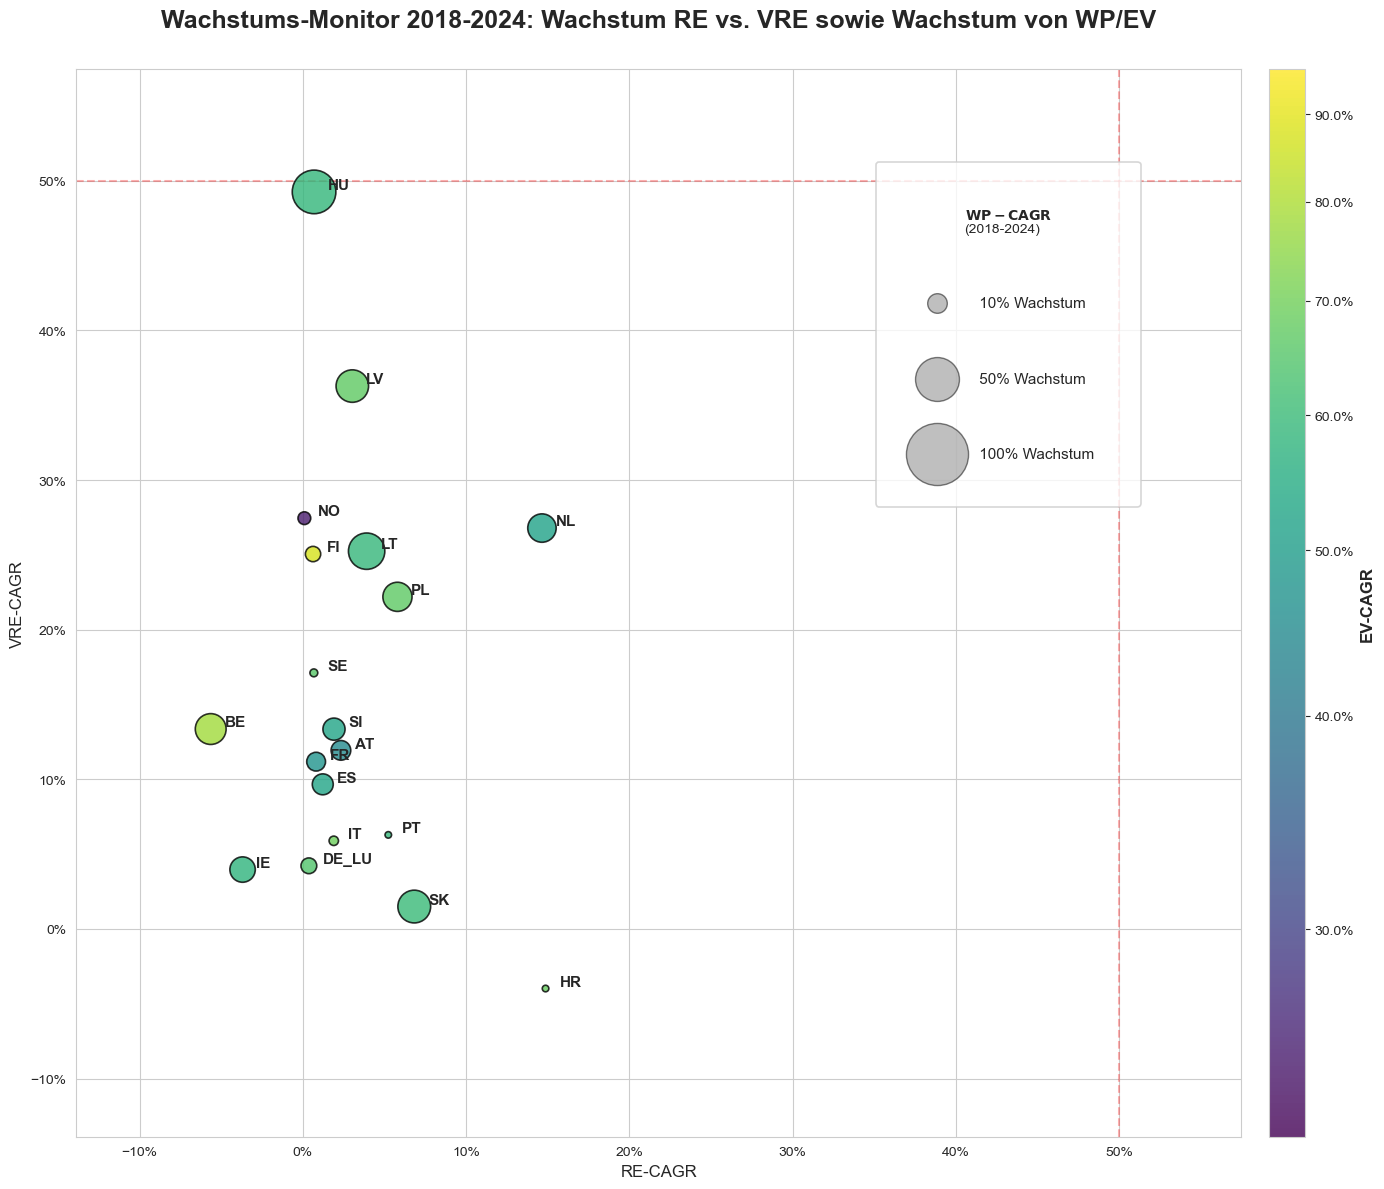

In [118]:
# Datenbasis
x = display_df['RE-Wachstum (2018-2024)']
y = display_df['VRE-Wachstum (2018-2024)']
size = display_df['WP-Wachstum (2018-2024)']
color = display_df['EV-Wachstum (2018-2024)']
countries = display_df.index

# Figure-Setup
plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

# Farbskala: Logarithmische Normierung für maximale Differenzierung, da es bei EV und WP sehr große Unterschiede gibt (siehe boxplots) und die Farbunterschiede bei linearer Skalierung zu gering wären
vmin_dynamic = max(color.min(), 0.001)  # Minimaler Startwert knapp über 0, da log(0) nicht definiert ist
vmax_dynamic = color.max()
# 10% Puffer, damit Min/Max nicht exakt auf den Farbgrenzen liegen
norm = mcolors.LogNorm(vmin=vmin_dynamic * 0.9, vmax=vmax_dynamic * 1.1)

# Scatterplot: Multiplizierung der Größe mit dem Faktor 2000, damit die Blasen eine sichtbare Größe erhalten
scatter = plt.scatter(x, y, s=size*2000, c=color, cmap='viridis', norm=norm, alpha=0.8, edgecolors='black', linewidth=1.2, zorder=3)


# Quadratische Skalierung der Diagrammfläche anhand der minimalen und maximalen Wachstumswerte
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
puffer_ax = abs(max_val - min_val) * 0.15 

limit_min = min_val - puffer_ax
limit_max = max_val + puffer_ax

plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)


# Hilfslinien
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3, zorder=1)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.3, zorder=1)

# Ländernamen
for i, txt in enumerate(countries):
    plt.annotate(txt, (x.iloc[i], y.iloc[i]), xytext=(10, 2), textcoords='offset points', fontsize=11, fontweight='bold')

# Farbbalken (EV)
cbar = plt.colorbar(scatter, pad=0.02, aspect=30)
cbar.set_label('EV-CAGR', fontsize=12, fontweight='bold')

# Teilstriche auf dem Farbbalken werden trotz Log-Skala in mathematisch sinnvollen Abständen (Basis 10) gesetzt
cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, subs='all', numticks=8))
# Der Formatter schreibt die Prozentzahlen mit einer Nachkommastelle
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))
# Minor Ticks (Zwischenstriche ohne Text) werden nicht dargestellt
cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Legende (WP): Beispielwerte für die Blasen mit 10%, 50%, 100%
for s in [0.1, 0.5, 1.0]:
    plt.scatter([], [], c='gray', alpha=0.5, s=s*2000, label=f' {s*100:.0f}% Wachstum', edgecolors='black')

leg = plt.legend(title="$\mathbf{WP-CAGR}$ \n(2018-2024)", 
                 loc="upper right", 
                 bbox_to_anchor=(0.92, 0.92),
                 frameon=True, 
                 fontsize=11, 
                 labelspacing=4.0, 
                 borderpad=3.0,    
                 handletextpad=1.5)
leg.get_frame().set_linewidth(1.2)

# Titel & Achsen
plt.title('Wachstums-Monitor 2018-2024: Wachstum RE vs. VRE sowie Wachstum von WP/EV', fontsize=18, fontweight='bold', pad=30)
plt.xlabel('RE-CAGR', fontsize=12)
plt.ylabel('VRE-CAGR', fontsize=12)

# Achsen: Prozentwerte anstatt Dezimalwerte anzeigen
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

**Analyse der Wachstums-Monitor-Matrix:**  

- Die Visualisierung (Farben, Kreise) entspricht derjenigen im Bestands-Monitor
- Eine 45°-Diagonale gibt es nicht, da die Wachtsumsraten beliebige Werte unabhängig voneinander annehmen können
<br>

<u>Stromerzeugung:</u>
- Auffällig ist die Verteilung der Wachstumsraten: während die maximale RE-Wachstumsrate bei ca. 15% liegt, sind es bei den VRE knapp 50%
<br>

<u>Elektrifizierung - Wärmepumpen:</u>
- Ungarn weist mit fast 50% mit großem Abstand das höchste Wachstum auf
- Kroatien, Portugal, Schweden und Italien mit knapp üeber 0% das niedrigste
<br>

<u>Elektrifizierung - Elektroautos:</u>
- Finnland weist mit ca. 85% das höchste Wachstum auf, gefolgt von Belgien mit knapp 80%
- Alle Länder außer Norwegen haben mind. 45% Wachstum ausgewiesen

## 4.4 Identifizierung der wirtschaftlich interessantesten Märkte  
Die vorherige Analye zeigt ausschließlich die Wachstumsraten innerhalb der Länder an. Für eine strategische betriebswirtschaftliche Entscheidung, ob diese Länder auch interessante Märkte sind, ist aber nicht nur die Wachstumsrate, sonder auch das Marktvolumen relevant.  
  
Das Marktvolumen stellt für für die erneuerbaren und variablen erneuerbaren Energien sowie für die Wärmepumpen die Stromerzeugungsleistung dar.  
  
Für Elektroautos macht dies keinen Sinn. Als Proxy für das EV-Marktvolumen ist die Bevölkerung ein möglicher Parameter. Ob diese Abschätzung gerechtfertigt ist, wird im Folgenden durch eine Regressionsanalyse zwischen Bevölkerung und Stromerzeugungsleistung untersucht.

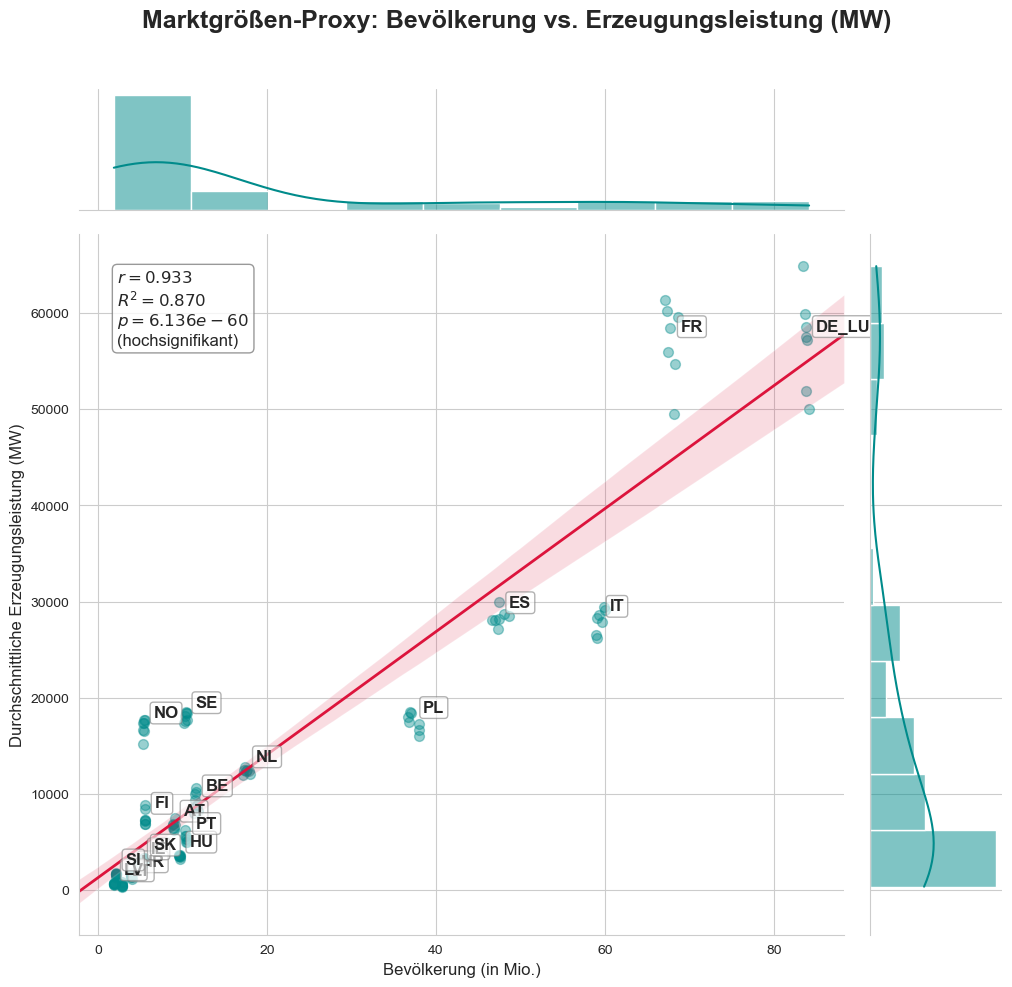

In [119]:
# Aggregation auf Jahresebene
annual_mean_df = generation_final_pop_df.groupby(['Land_Code', 'Year']).agg({
    'Gen_Total_MW': 'mean',
    'Population': 'mean'
}).reset_index()

# Skalierung der Bevölkerung auf Millionen (für bessere Lesbarkeit)
annual_mean_df['Population_Mio'] = annual_mean_df['Population'] / 1e6

# Statistische Kennzahlen berechnen
slope, intercept, r_value, p_val, std_err = stats.linregress(annual_mean_df['Population_Mio'], annual_mean_df['Gen_Total_MW'])
r_squared = r_value**2

# Dynamische Beschriftung erstellen 
sig_text = "hochsignifikant" if p_val < 0.001 else "signifikant" if p_val < 0.05 else "nicht signifikant"

stats_box = f"$r = {r_value:.3f}$\n$R^2 = {r_squared:.3f}$\n$p = {p_val:.3e}$\n({sig_text})"

# Visualisierung
sns.set_style("whitegrid")

g = sns.jointplot(
    data=annual_mean_df, 
    x='Population_Mio', 
    y='Gen_Total_MW',
    kind="reg",
    truncate=False,
    color="darkcyan",
    height=10,
    scatter_kws={'alpha': 0.4, 's': 50},
    line_kws={'color': 'crimson', 'lw': 2}
)

# Textbox für r, R² und p-Wert in die Grafik einfügen
g.ax_joint.text(
    0.05, 0.95, stats_box, 
    transform=g.ax_joint.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'),
    fontsize=12
)

# Länderkürzel am Zentrum des Landes
country_centers = annual_mean_df.groupby('Land_Code').agg({
    'Population_Mio': 'mean',
    'Gen_Total_MW': 'mean'
})

for land, row in country_centers.iterrows():
    g.ax_joint.annotate(
        land, 
        (row['Population_Mio'], row['Gen_Total_MW']),
        xytext=(7, 7), 
        textcoords='offset points', 
        fontsize=12, 
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='gray')
    )

# Achsenbeschriftung und Titel
g.set_axis_labels('Bevölkerung (in Mio.)', 'Durchschnittliche Erzeugungsleistung (MW)', fontsize=12)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Marktgrößen-Proxy: Bevölkerung vs. Erzeugungsleistung (MW)', fontsize=18, fontweight='bold')

plt.show()

Die Korrelation ist hochsignifkiant und sehr hoch, die Bevölkerung kann als Proxy für die Marktgröße für Elektroautos verwendet werden.

Zur Bewertung des wirtschaftlichen Potentials wird nun - ähnlich wie bei der bekannten Boston-Consulting-Group-Matrix (BCG-Matrix: Marktwachstum vs. relativer Marktanteil) - eine 4 x 4 Matrix erstellt.  
In diesem Fall wird jedoch das Marktwachstum der Marktgröße gegenübergestellt.  
<br>
Die Marktgröße ist die Stromerzeugung (RE, VRE, WP) bzw. die Bevölkerung (EV), normiert auf 100%, wobei 100% der jeweils größte Markt der Länder im Jahr 2024 ist.  
<br>
Das Marktwachstum wird in 2 Zeitintervalle gesplittet: 2018-2021 und 2021-2024.  
Dadurch lässt sich die Veränderung der Wachstumsdynamik darstellen (Beschleunigung oder Verlangsamung).

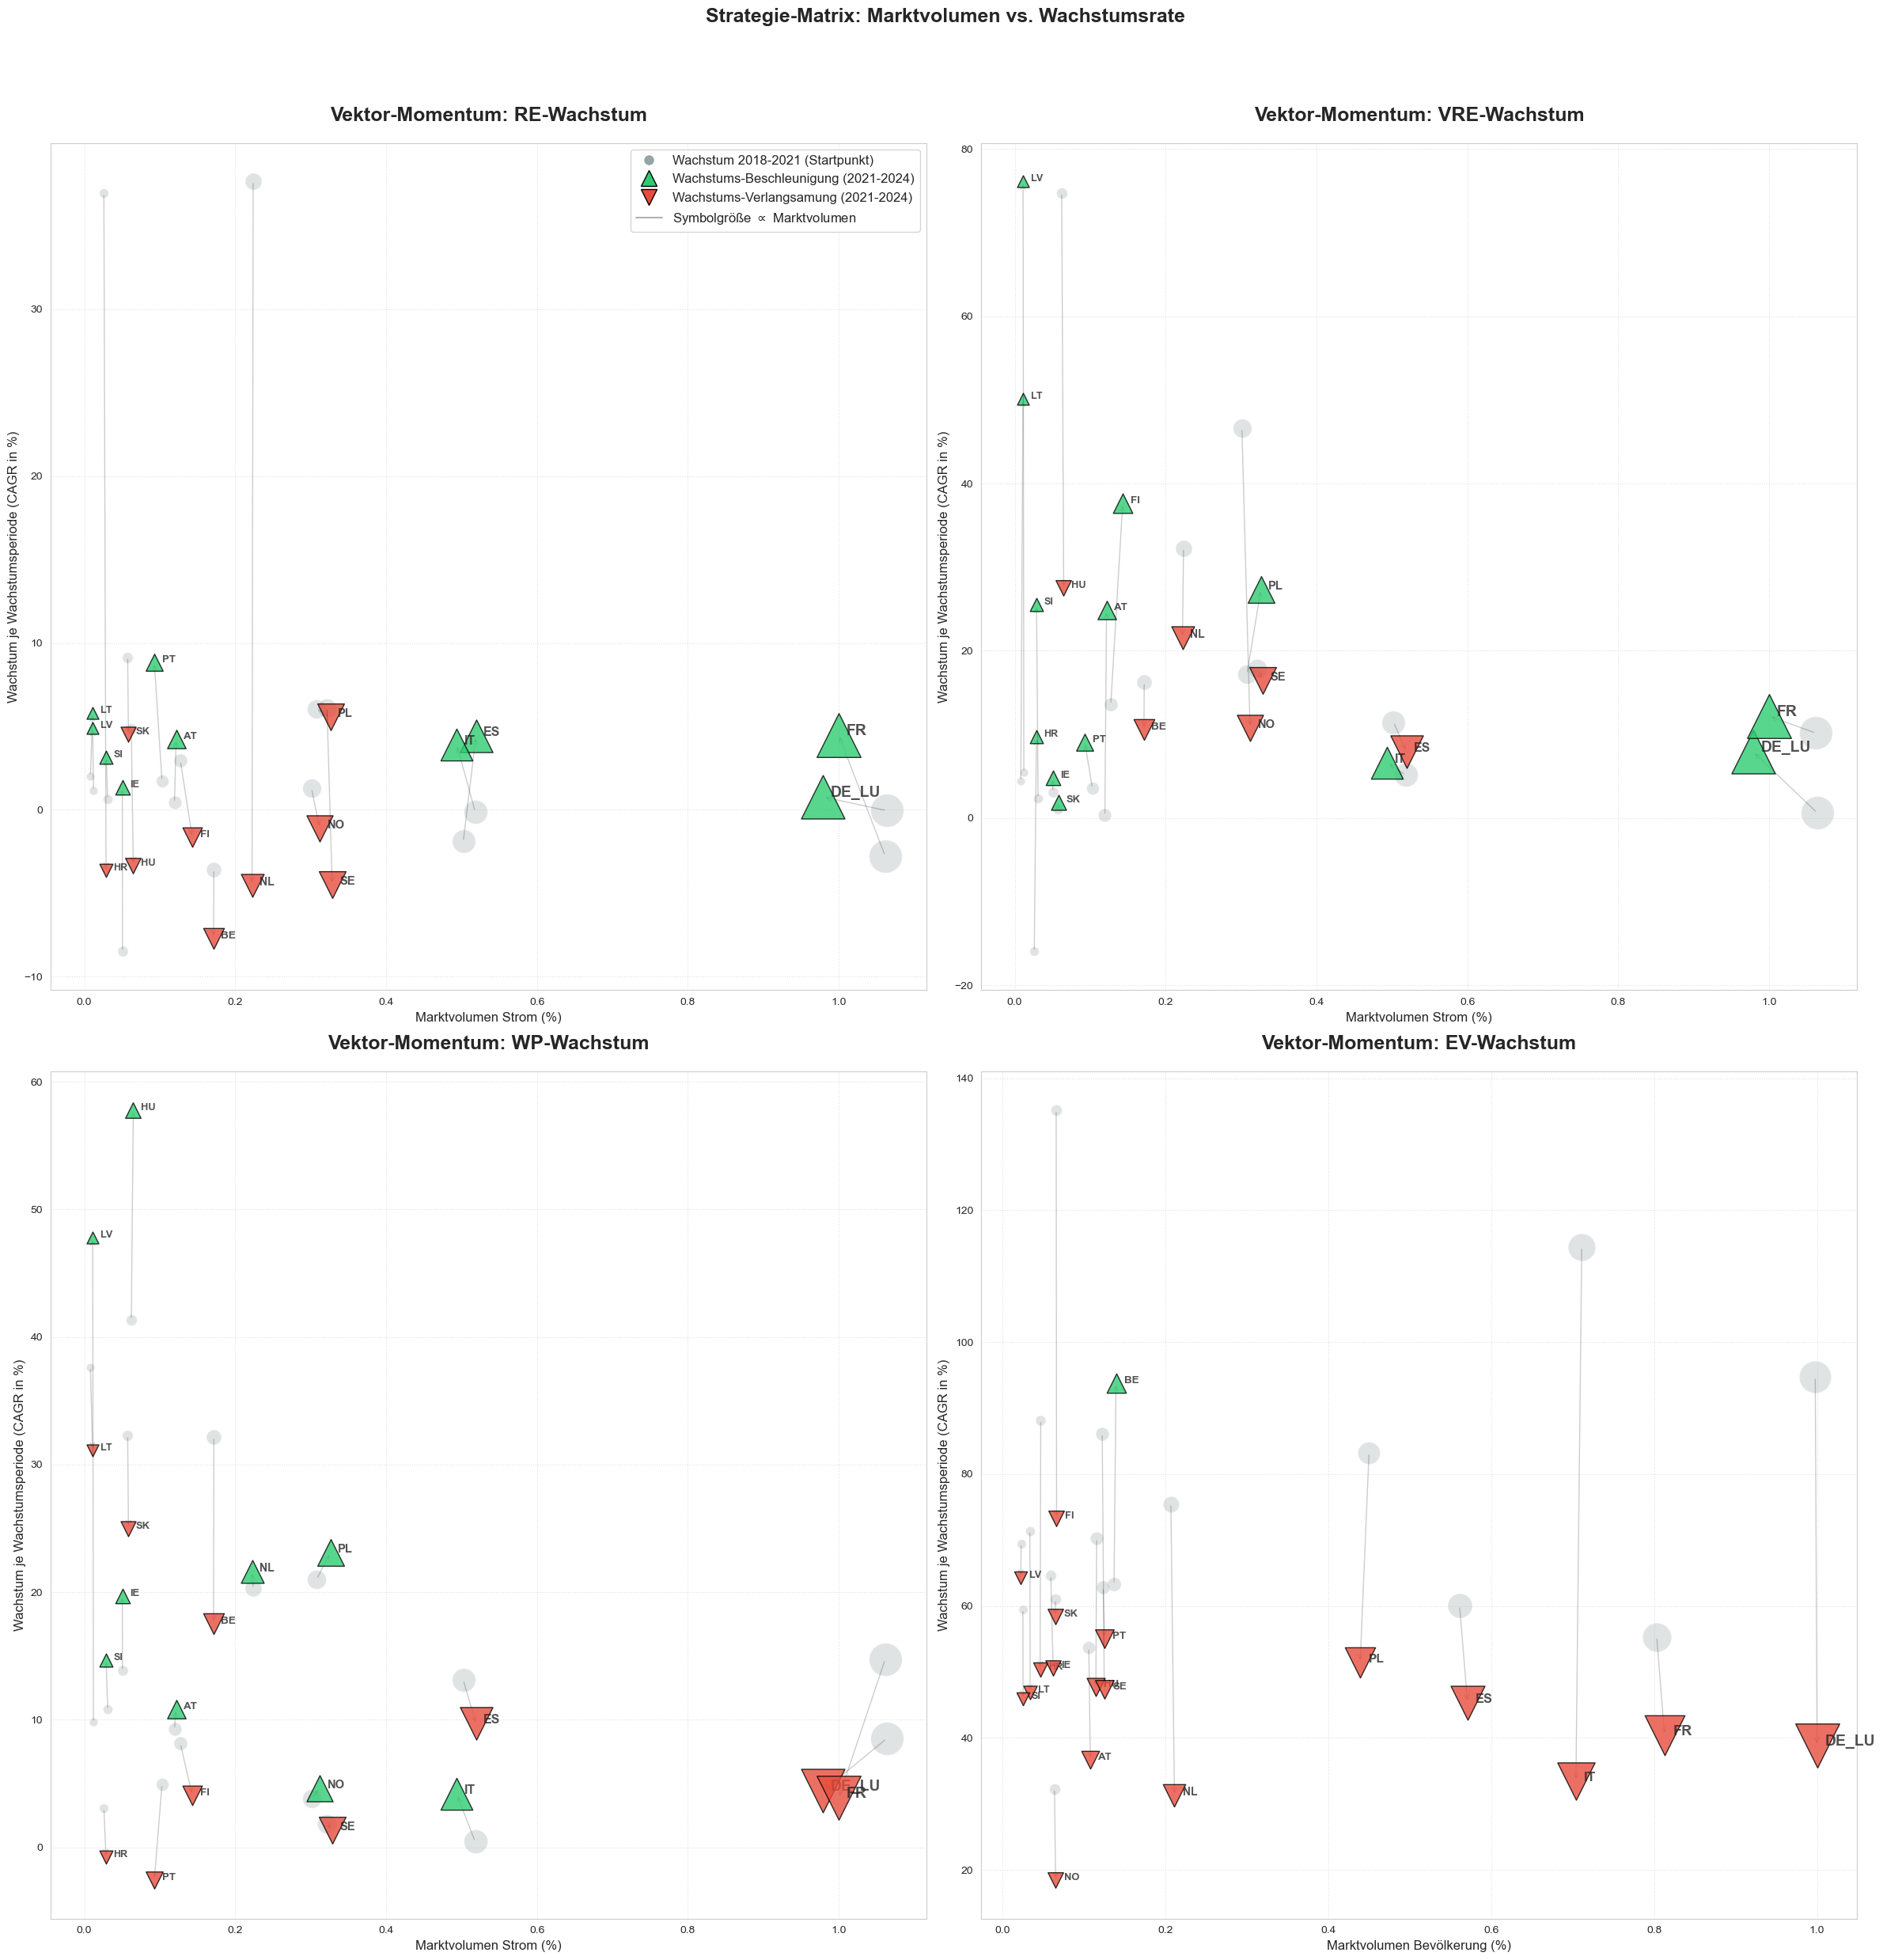

In [120]:
# Datenvorbereitung
# Marktgrößen (Strom bzw. Bevölkerung) für die 2 Zeitintervalle 2018-2021 und 2021-2024
market_p1 = generation_final_pop_df[generation_final_pop_df['Year'].between(2018, 2021)].groupby('Land_Code').agg({'Gen_Total_MW': 'mean', 'Population': 'mean'})
market_p2 = generation_final_pop_df[generation_final_pop_df['Year'].between(2021, 2024)].groupby('Land_Code').agg({'Gen_Total_MW': 'mean', 'Population': 'mean'})

# Maximale Marktgrößen als Referenzwert 100%
max_gen = market_p2['Gen_Total_MW'].max()
max_pop = market_p2['Population'].max()

# Untersuchte Kategorien: Wachstum RE, VRE, WP, EV
categories = {
    'RE-Wachstum':  ('Gen_Total_MW', max_gen, 'Marktvolumen Strom (%)'),
    'VRE-Wachstum': ('Gen_Total_MW', max_gen, 'Marktvolumen Strom (%)'),
    'WP-Wachstum':  ('Gen_Total_MW', max_gen, 'Marktvolumen Strom (%)'),
    'EV-Wachstum':  ('Population',   max_pop, 'Marktvolumen Bevölkerung (%)')
}

# 4 Plots in 2x2 Anordnung
fig, axes = plt.subplots(2, 2, figsize=(24, 24))
axes_flat = axes.flatten()

# Visualisierung
for i, (cat, (proxy_col, max_val, label)) in enumerate(categories.items()):
    ax = axes_flat[i]
    # Spaltennamen erstellen
    col_y1 = f"{cat} (2018-2021)"
    col_y2 = f"{cat} (2021-2024)"
    
    for land in display_df.index:
        if land not in market_p1.index or land not in market_p2.index:
            continue
            
        # x-Koordinaten (Marktgröße relativ) für den Startwert und den Endwert
        x1 = market_p1.loc[land, proxy_col] / max_val
        x2 = market_p2.loc[land, proxy_col] / max_val

        # y-Koordinaten für den Startwert und den Endwert        
        y1 = display_df.loc[land, col_y1] * 100
        y2 = display_df.loc[land, col_y2] * 100
        
        # Berechnung der Symbolgröße (s)
        # Nutzung einer Basisgröße + einen Faktor mal Marktvolumen, x2 ist das Volumen in Phase 2 (0.0 bis 1.0)
        size_p1 = 50 + (x1 * 800)
        size_p2 = 100 + (x2 * 1500)
        
        # Momentum-Logik: wenn der Wachstumswert 2021-2024 > 2018-2021 => grünes Dreieck nach oben, ansonsten rotes Dreieck nach unten
        is_accelerating = y2 > y1
        color = '#2ecc71' if is_accelerating else '#e74c3c'
        marker = '^' if is_accelerating else 'v'
        
        # Pfeil zeichnen: Vektor zwischen Starpunkt (2018-2021) und Endpunkt (2021-2024)
        dist = ((x2 - x1)**2 + (y2 - y1)**2)**0.5
        if dist > 0.001:
            ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", color='black', lw=1, alpha=0.2))
        
        # Startpunkt Phase 1 (Kreis)
        ax.scatter(x1, y1, color='#95a5a6', s=size_p1, alpha=0.3, edgecolors='white', zorder=2)
        
        # Endpunkt Phase 2 (Dreieck)
        ax.scatter(x2, y2, color=color, s=size_p2, alpha=0.8, edgecolors='black', marker=marker, zorder=3)
        
        # Land-Label
        ax.text(x2 + 0.01, y2, land, fontsize=9 + (x2*5), fontweight='bold', alpha=0.8)

    ax.set_title(f'Vektor-Momentum: {cat}', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Wachstum je Wachstumsperiode (CAGR in %)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    # Legende
    if i == 0:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Wachstum 2018-2021 (Startpunkt)', markerfacecolor='#95a5a6', markersize=10),
            Line2D([0], [0], marker='^', color='w', label='Wachstums-Beschleunigung (2021-2024)', markerfacecolor='#2ecc71', markersize=14, markeredgecolor='black'),
            Line2D([0], [0], marker='v', color='w', label='Wachstums-Verlangsamung (2021-2024)', markerfacecolor='#e74c3c', markersize=14, markeredgecolor='black'),
            Line2D([0], [0], color='black', alpha=0.3, label='Symbolgröße $\propto$ Marktvolumen')
        ]
        ax.legend(handles=legend_elements, loc='best', fontsize=12)

plt.suptitle('Strategie-Matrix: Marktvolumen vs. Wachstumsrate', fontsize=18, fontweight='bold', y=1.03)

try:
    plt.tight_layout()
except:
    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.3, wspace=0.2)

plt.show()

**Analyse der Marktwachstums-Marktvolumen-Diagramme:**

Die Graphik lässt sich im Uhrzeigersinn in vier Quadranten enteilen:  
- Quadrant 1: Niedriges Marktvolumen & hohe Wachstumsrate => noch geringe Stückzahlen, mit steigendem Wachstum nimmt diese aber zu
- Quadrant 2: Hohes Marktvolumen & hohe Wachstumsrate => dies stellt den idealen Fall dar, da es zu einem hohen Wachstum in Stückzahlen führt
- Quadrant 3: Hohes Marktvolumen & niedrige Wachstumsrate => wenig Stückzahlen-Wachstum, aber hoher Bestand, interessant z.B. für Ersatzinvestitionen/Wartung
- Quadrant 4: Niedriges Marktvolumen & niedrige Wachstumsrate => wirtschaftlich am wenigsten interessant
<br>
  
Anhand dieser Einteilung lassen sich die untersuchten Märkte analysieren:  

<u>RE-Wachstum:</u>
- Die kleineren Märkte zeigen ein gemischtes Bild. Während die Wachstums-Spitzenreiter 2018-2021 (Kroatien, Niederlande) in der zweiten Betrachtungsperiode (2021-2024) deutlich langsamer wachsen bzw. sogar schrumpfen, hat sich die Wachstumsgeschwindigkeit von Polen und Irland stark erhöht.
- Die mittleren und großen Märkte (Spanien, Italien, Deutschland/Luxemburg, Frankreich) haben ihr Wachstum zwischen den Betrachtungsintervallen ausgehend von einer Schrumpfung beschleunigt und sind zu positivem Wachstum gekommen
- Insgesamt sind im zweiten Betrachtungsintervall eine Vielzahl an Ländern im Bereich des Negativwachstums. Dies kann z.B. an geringem Niederschlag liegen, in solchen Jahren ist die Stromerzeugung aus Wasserkraft stark eingeschränkt
<br>

<u>VRE-Wachstum:</u>
- Ein ähnliches Bild ergibt sich bei den VRE, die mittleren und großen Länder haben ihr Wachstum beschleunigt, die kleinen Märkte weisen ein gesmischtes Bild auf
- Jedoch befinden sich hier alle Länder in beiden Zeitintervallen im Bereich des positiven Wachstums der Erzeugungsleistung (Ausnahme: Kroatien)
  
- Dies deckt sich mit der Analyse auf aggregierter Länderebene in Kapitel 3.2: die Erzeugung aus RE ist mit leichtem Auf und Ab in etwa konstant, wohin gegen die VRE-Erzeugungsleistung steigt
<br>

<u>WP-Wachstum:</u>
- Hier hat sich das Wachstum vor allem bei den zwei größten Märkten (Deutschland/Luxemburg sowie Frankreich) abgeschwächt
- Bei den kleineren und mittleren Ländern gibt es sowohl schneller als auch langsamer wachsende Länder, Kroatien/Portugal sind im zweiten Betrachtugnsintervall geschrumpft
- Insgesamt führt es zu der in Kapitel 3.3 schon dargestellten leichten Verlangsamung des Wachstums, welche nicht gleichmäßig durch alle Länder verursacht wurde: kleine und mittlere Länder haben positiv/negativ dazu beigetragen, die großen Länder nur zum Rückgang
<br>

<u>EV-Wachstum:</u>
- Bis auf die Ausnahme Belgien hat sich bei allen Ländern das Wachstum im EV-Bestand in der zweiten Betrachtungsperiode verringert
- Im Falle einiger großer Länder (Deutschland, Italien) und kleinerer Länder (Finnland, Niederland) sogar massiv
- Die Wachstumsraten befinden sich in der zweiten Betrachtungsperiode aber immer noch allesamt über 20%
- Damit lässt sich die Darstellung aus Kapitel 3.4 (Gesamtbestand und Wachstum aller Länder) weiter differenzieren: die Abnahme der Wachstumsrate wurde gleichmäßig von allen Ländern verursacht, nicht von einigen wenigen.


<u>Zusammenfassung:<u>
- Im VRE und RE Ausbau zeigt sich ein deutliches Bild: die größten Märkte weisen beschleunigte Wachstumsraten auf und sind damit eindeutig die wirtschafftlich interessantesten Märkte
- Bei den Wärmepumpen zeigt sich das umgekehrte Bild: hier sind die kleineren Länder interessanter, jedoch mit einem sehr heterogenen Bild, ein Markteintritt muss hier genau analysiert und differenziert werden.
- Bei den Elektroautos gibt es keine beschleunigt wachsenden Märkte (Ausnahme Belgien), einige große Länder (Italien, Deutschland/Luxemburg) weisen zudem ein besonders stark zurückgegangenes Wachstum auf; jedoch wachsen alle Länder auch weiterhin mit >20% p.a.

# 5. Zusammenhang zwischen Erzeugung/Verbrauch/Elektrifizierung und Strompreis/Volatilität

In diesem Kapitel soll die folgende zentrale Frage untersucht werden: hat der Ausbau der (variablen) erneuerbaren Energien, von Wärmepumpen und Elektroautos Auswirkungen auf den Strompreis und dessen Volatilität?

## 5.1 Korrelation RE/VRE-Anteil - Strompreis/Volatilität

Um diesen Zusammenhang zu untersuchen, wird zunächst die Korrelation des RE/VRE-Anteils zu den Strompreisen/Volatilitäten auf Monatsbasis untersucht:

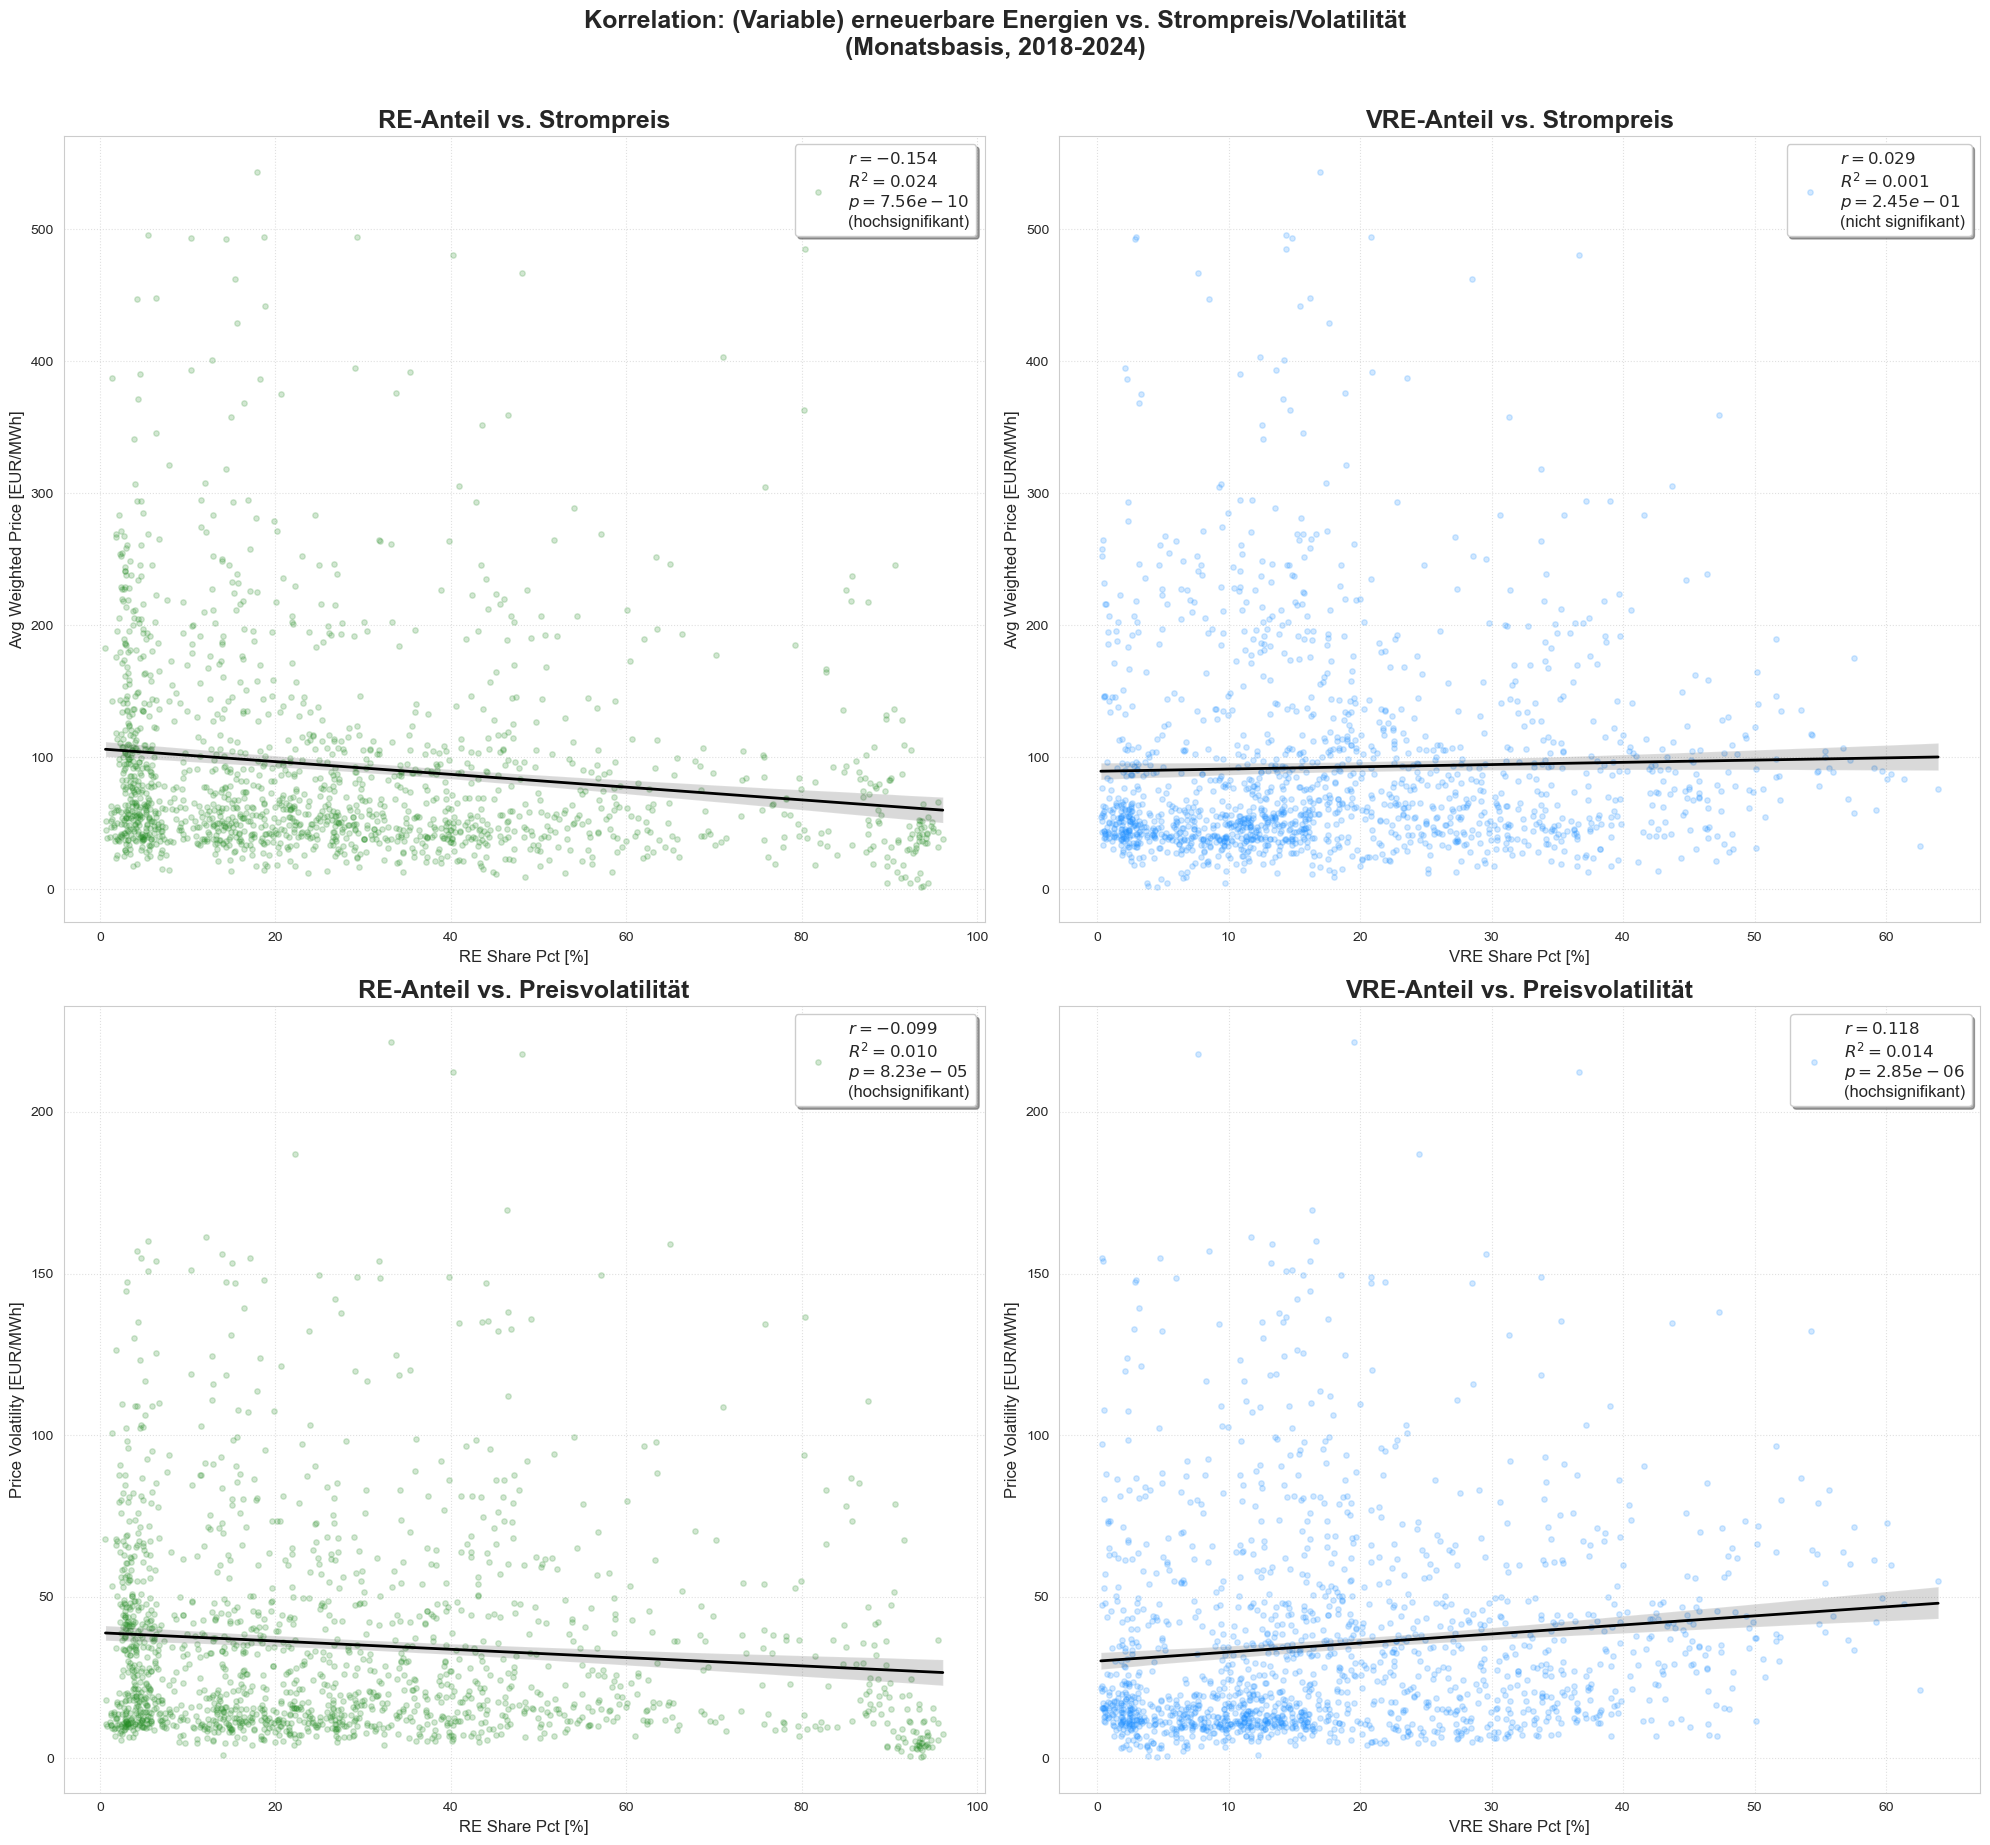

In [121]:
# Monatliche Aggregation - Stromerzeugung
generation_final_df['Month'] = generation_final_df['Date_Time'].dt.month
monthly_gen = generation_final_df.groupby(['Land_Code', 'Year', 'Month']).agg({'RE_Share_Pct': 'mean', 'VRE_Share_Pct': 'mean'}).reset_index()

# Monatliche Aggregation - Strompreise, Volatilität
energy_prices_final_df['Month'] = energy_prices_final_df['Date_Time'].dt.month
monthly_prices = energy_prices_final_df.groupby(['Land_Code', 'Year', 'Month']).agg({'Weighted_Price': ['mean', 'std']}).reset_index()

# Spaltennamen umbenennen
monthly_prices.columns = ['Land_Code', 'Year', 'Month', 'Avg_Weighted_Price', 'Price_Volatility']

# Mergen in einen master-df
master_monthly_df = pd.merge(monthly_gen, monthly_prices, on=['Land_Code', 'Year', 'Month'])

# Visualisierung (2x2 Matrix)
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
fig.suptitle('Korrelation: (Variable) erneuerbare Energien vs. Strompreis/Volatilität\n(Monatsbasis, 2018-2024)', fontsize=18, fontweight='bold', y=0.95)

# Konfiguration der 4 Plots
configs = [
    ('RE_Share_Pct', 'Avg_Weighted_Price', 'RE-Anteil vs. Strompreis', 'forestgreen', axes[0,0]),
    ('VRE_Share_Pct', 'Avg_Weighted_Price', 'VRE-Anteil vs. Strompreis', 'dodgerblue', axes[0,1]),
    ('RE_Share_Pct', 'Price_Volatility', 'RE-Anteil vs. Preisvolatilität', 'forestgreen', axes[1,0]),
    ('VRE_Share_Pct', 'Price_Volatility', 'VRE-Anteil vs. Preisvolatilität', 'dodgerblue', axes[1,1])
]

for x_col, y_col, title, color, ax in configs:
    # Daten reinigen (NaNs entfernen für die Regression)
    subset = master_monthly_df[[x_col, y_col]].dropna()
    
    # Lineare Regression berechnen
    slope, intercept, r_val, p_val, std_err = stats.linregress(subset[x_col], subset[y_col])

    # Dynamische Abfrage der Signifikanz
    sig_text = "hochsignifikant" if p_val < 0.001 else "signifikant" if p_val < 0.05 else "nicht signifikant"

    # Scatterplot mit Regressionslinie, Label: r, R², p
    sns.regplot(data=subset, x=x_col, y=y_col, ax=ax, 
                scatter_kws={'alpha':0.2, 's':15, 'color':color}, 
                label=f'$r = {r_val:.3f}$\n$R^2 = {r_val**2:.3f}$\n$p = {p_val:.2e}$\n({sig_text})',
                line_kws={'color': 'black', 'lw': 2, 'zorder': 4})
    
    # Achsen und Titel
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel(f'{x_col.replace("_", " ")} [%]', fontsize=12)
    ax.set_ylabel(f'{y_col.replace("_", " ")} [EUR/MWh]', fontsize=12)

    # Legende
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

**Analyse der Korrelation zwischen RE/VRE und dem Strompreis/Volatilität:**
- Korrelation der Erzeugung erneuerbarer Energien (RE) zu Strompreis und Volatilität:
- Die Korrelation ist sowohl bei den Strompreisen als auch der Volatiltiät hochsignifikant
- Die Korrelation ist bei beiden Größen leicht negativ, mit steigendem RE-Anteil sinkt sowohl der Preis als auch die Volatilität
- Jedoch ist das Bestimmtheißtsmaß (R²) mit 0,024 (Strompreis) und 0,01 (Volatilität) extrem niedrig: der RE-Anteil erklärt fast nichts von den Strompreisen/Volatilitäten

- Korrelation der Erzeugung variabler erneuerbarer Energien (VRE) zu Strompreis und Volatilität:
- Die Korrelation ist bei den Strompreisen nicht signifikant, bei der Volatiltiät jedoch hochsignifikant
- Die Korrelation ist bei dem Strompreis nur leicht steigend, bei der Volatilität steigend: mit steigendem RE-Anteil steigt also der Stromreis leicht und die Volatilität stärker an
- Jedoch ist das R² mit 0,001 (Strompreis) und 0,0114 (Volatilität) wie auch bei den RE extrem niedrig: der VRE-Anteil erklärt fast nichts von den Strompreisen/Volatilitäten
<br>

<u>Zusammenfassung:</u>
- Die Ergebnisse sind hochsignifikant (Ausnahme: VRE-Anteil vs. Strompreis), aufgrund des sehr geringen Bestimmheitsmaßes (R²) sind jedoch keine statistisch belastbaren Aussagen über den Einfluss des RE- und VRE-Anteils auf den Strompreis und die Volatilität möglich
- Die 4 Diagramme visualisieren dies sehr gut: die "Punktewolke" ist jeweils breit verteilt, ohne Zuhilfenahme der Regressionsgerade wäre kein eindeutiger Trend innerhalb der Punkte erkennbar

## 5.2 Korrelation Wärmepumpen/Elektroautos zu Strompreis/Volatilität

Parallel zu der vorhergehenden Analyse erfolgt die Korrelationsanalyse zwischen Elektroautos/Wärmepumpen und Strompreisen/Volatilitäten, aufgrund der Datenlage auf Jahresbasis:

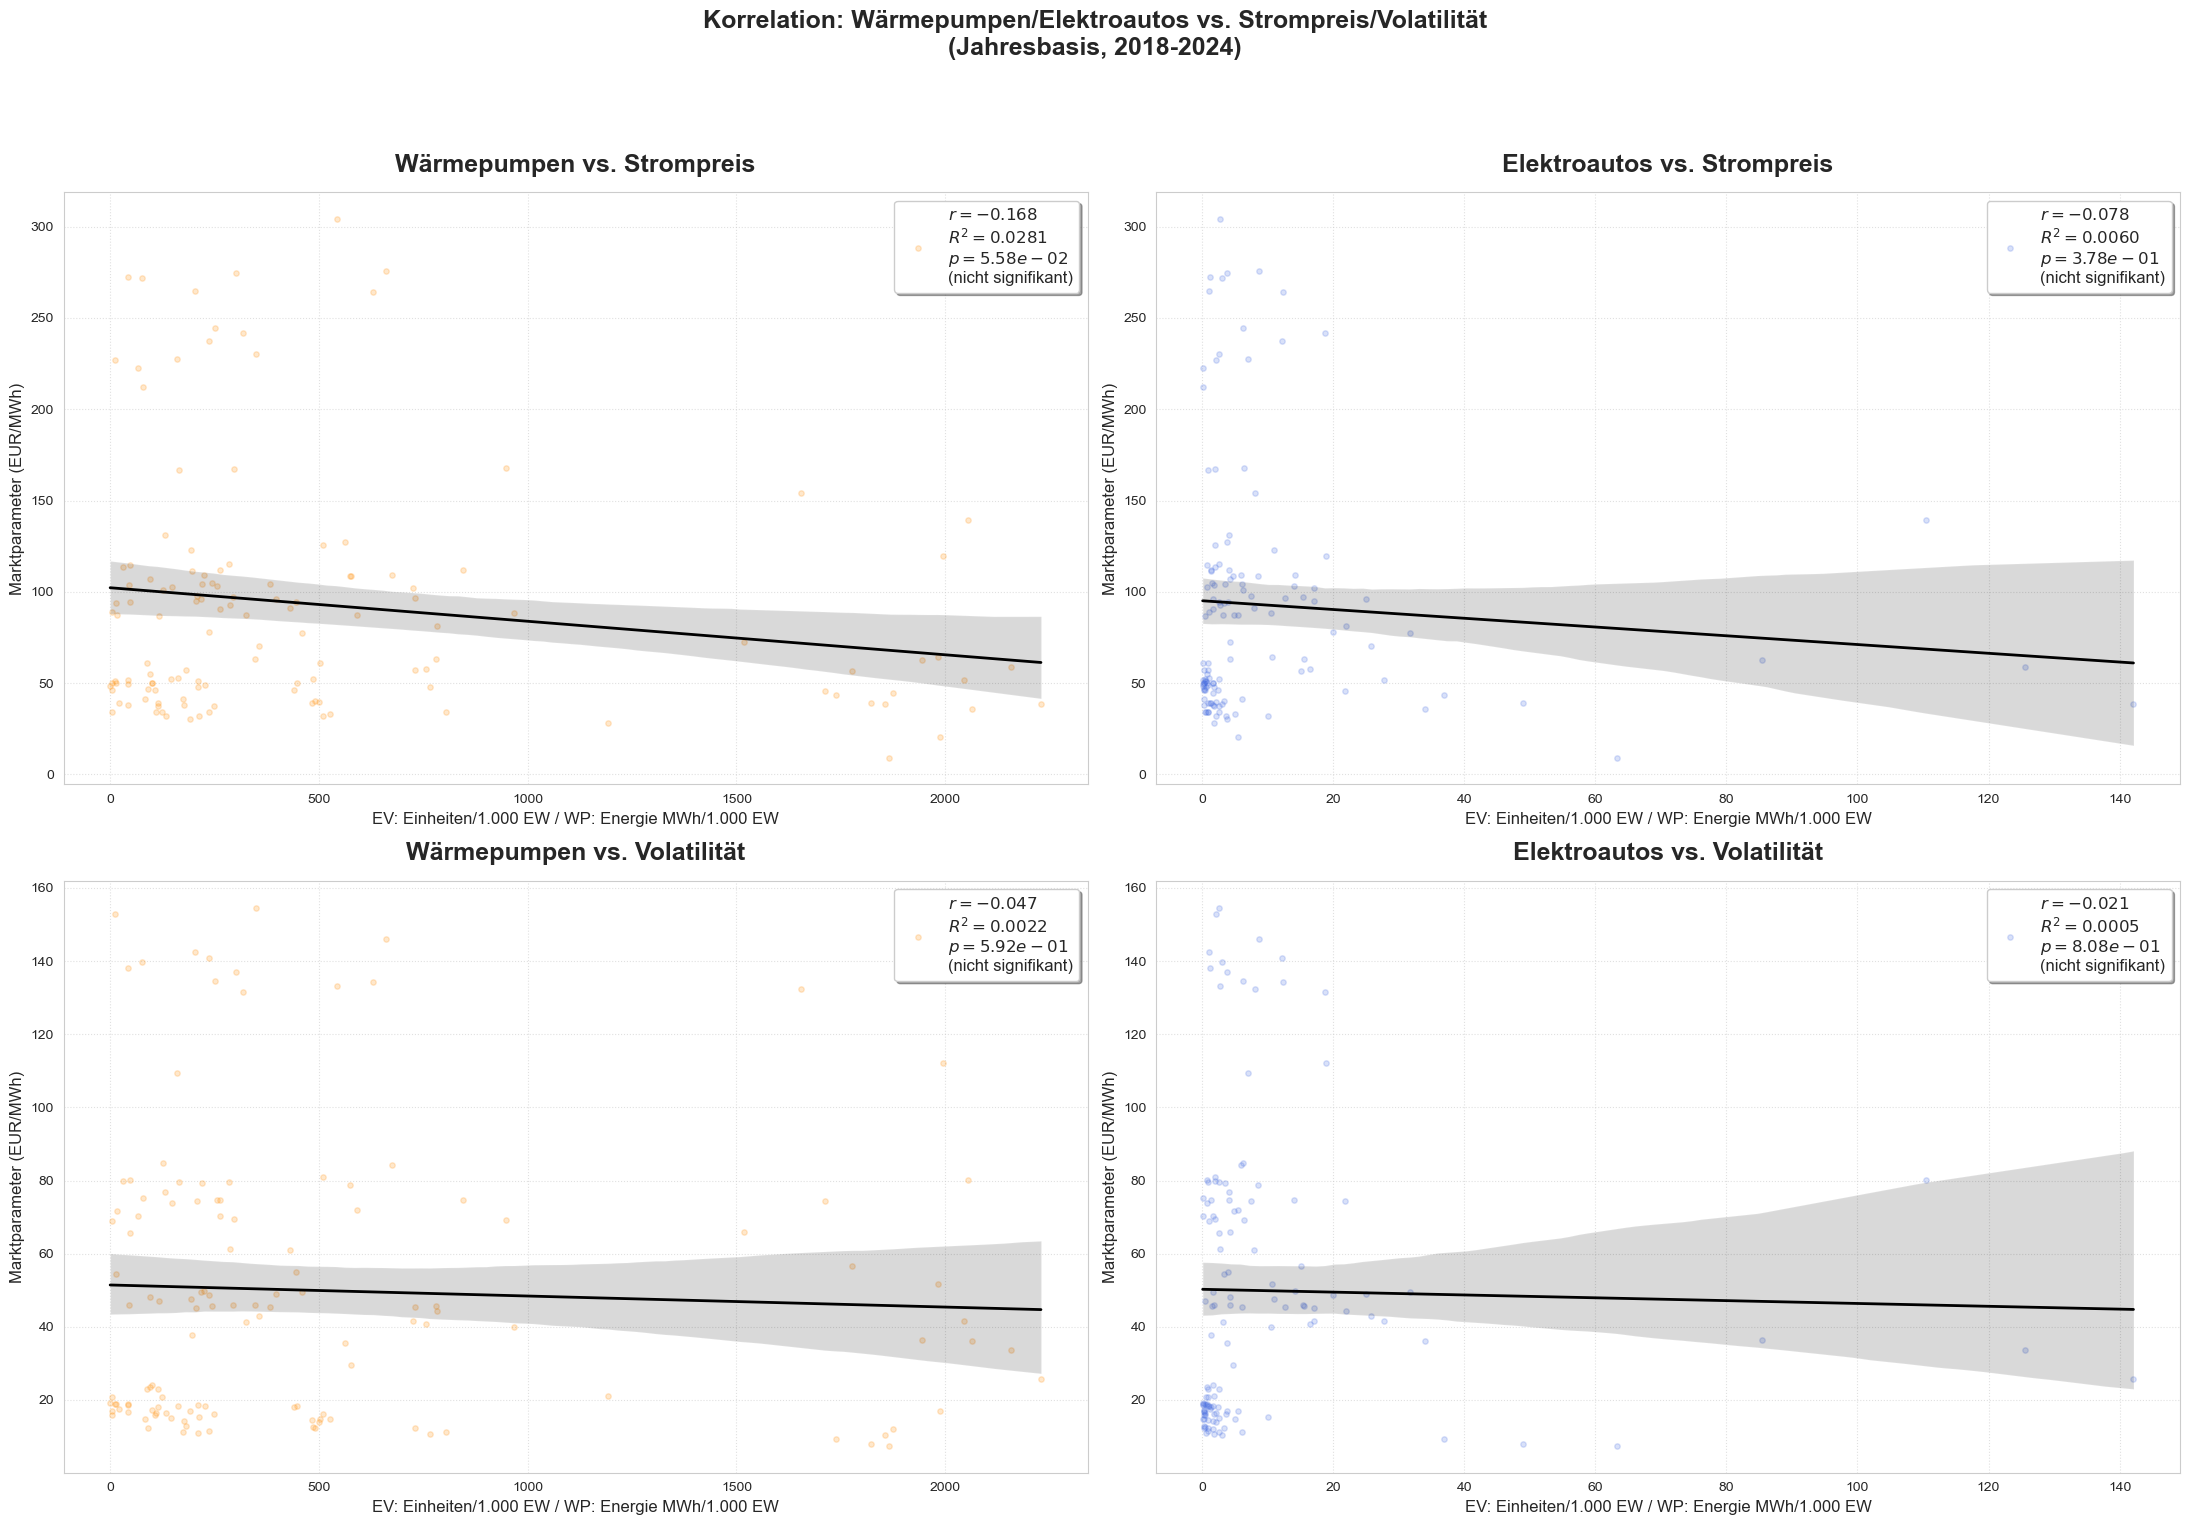

In [122]:
# Jährliche Aggregation - Strompreise/Volatilitäten
market_df = energy_prices_final_df.groupby(['Land_Code', 'Year']).agg({'Weighted_Price': ['mean', 'std']}).reset_index()
market_df.columns = ['Land_Code', 'Year', 'Yearly_Price', 'Yearly_Vola']

# Jährliche Aggregation - WP/EV
ev_dynamic_df = e_veh_final_pop_df[['Land_Code', 'Year', 'EV_Count_Total_Pop']].copy()
hp_dynamic_df = hp_final_pop_df[['Land_Code', 'Year', 'HP_Value_MWh_Pop']].copy()

# Mergen in einen master-df
master_yearly_df = pd.merge(market_df, ev_dynamic_df, on=['Land_Code', 'Year'])
master_yearly_df = pd.merge(master_yearly_df, hp_dynamic_df, on=['Land_Code', 'Year'])

# Visualisierung
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('Korrelation: Wärmepumpen/Elektroautos vs. Strompreis/Volatilität\n(Jahresbasis, 2018-2024)', fontsize=18, fontweight='bold', y=0.98)

# Konfiguration der 4 Plots
configs = [
    ('HP_Value_MWh_Pop', 'Yearly_Price', 'Wärmepumpen vs. Strompreis', 'darkorange', axes[0,0]),
    ('EV_Count_Total_Pop', 'Yearly_Price', 'Elektroautos vs. Strompreis', 'royalblue', axes[0,1]),
    ('HP_Value_MWh_Pop', 'Yearly_Vola', 'Wärmepumpen vs. Volatilität', 'darkorange', axes[1,0]),
    ('EV_Count_Total_Pop', 'Yearly_Vola', 'Elektroautos vs. Volatilität', 'royalblue', axes[1,1])
]

for x_col, y_col, title, color, ax in configs:
    # Daten reinigen (NaNs entfernen für die Regression)
    subset = master_yearly_df[[x_col, y_col, 'Year']].dropna()
    
    # Lineare Regression berechnen
    slope, intercept, r_val, p_val, std_err = stats.linregress(subset[x_col], subset[y_col])
    
    # Dynamische Abfrage der Signifikanz
    sig_text = "hochsignifikant" if p_val < 0.001 else "signifikant" if p_val < 0.05 else "nicht signifikant"
     
    # Scatterplot mi Regressionslinie, Label: r, R², p
    sns.regplot(data=subset, x=x_col, y=y_col, ax=ax,
                scatter_kws={'alpha':0.2, 's':15, 'color':color}, 
                label=f'$r = {r_val:.3f}$\n$R^2 = {r_val**2:.4f}$\n$p = {p_val:.2e}$\n({sig_text})',
                line_kws={'color': 'black', 'lw': 2, 'zorder': 4})
    
    # Achsen und Titel
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('EV: Einheiten/1.000 EW / WP: Energie MWh/1.000 EW', fontsize=12)
    ax.set_ylabel('Marktparameter (EUR/MWh)', fontsize=12)
    
    # Legende
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

**Analyse der Korrelation zwischen Wärmpumpen/Elektroautos und dem Strompreis/Volatilität:**

<u>Korrelation der Wärmepumpen (aufgenommene Energie) zu Strompreis und Volatilität:</u>
- Die Korrelation ist sowohl bei den Strompreisen als auch der Volatiltiät nicht signifikant
- Die Korrelation ist ggü. dem Strompreise negativ, ggü. der Volatilität nur minimal negativ: mit steigender Wärmepumpen-Energieaufnahme sinkt sowohl der Strompreis als auch die Volatilität
- Jedoch ist das Bestimmtheißtsmaß (R²) mit 0,028 (Strompreis) und 0,002 (Volatilität) extrem niedrig: Wärmpumpen erklären fast nichts von den Strompreisen/Volatilitäten
<br>

<u>Korrelation von Elektroautos (Bestand) zu Strompreis und Volatilität:</u>
- Die Korrelation ist sowohl bei den Strompreisen als auch der Volatiltiät nicht signifikant
- Die Korrelation ist ggü. dem Strompreise negativ, ggü. der Volatilität nur minimal negativ: mit steigendem Bestand an Elektroautos sinkt sowohl der Strompreis als auch die Volatilität
- Jedoch ist das Bestimmtheißtsmaß (R²) mit 0,006 (Strompreis) und 0,0005 (Volatilität) extremst niedrig: der Bestand an Elektroautos erklärt so gut wie nichts von den Strompreisen/Volatilitäten
<br>

<u>Zusammenfassung:</u>
- Die Ergebnisse sind nicht signifikant, zusammen mit den zudem sehr geringen Bestimmheitsmaßen (R²) sind deshalb keine statistisch belastbaren Aussagen über den Einfluss von Wärmepumpen und Elektroautos auf den Strompreis und die Volatilität möglich
- Die 4 Diagramme visualisieren dies sehr gut: die "Punktewolke" ist jeweils breit verteilt, ohne Zuhilfenahme der Regressionsgerade wäre kein eindeutiger Trend innerhalb der Punkte erkennbar
- Bei den Elektroautos kommt hinzu, dass die meisten betrachteten Länder eine Elektroautodichte von <20 Elektroautos/1.000 Einwohner haben, damit ist die Datenbasis für eine Regression sehr gering

## 5.3 Korrelation Batteriespeicher - Volatilität

In den vorangegangen Analysen wurde betrachtet, welchen Einfluss (variable) erneuerbare Energien sowie Wärmepumpen und Elektroautos auf die Volatilität der Strompreise haben.  
  
Zur Nutzung der Strompreisvolatilität stellen Batterien eine interessante Möglichkeit dar: durch die Speicherung und Abgabe von Strom können sowohl die Schwankungen im Strompreis wirtschaftlich nutzbar gemacht werden (zeitliche Arbitrage zwischen niedrigen und hohen Strompreisen) und dadurch auch die Volatilität im Strommarkt gesenkt werden (Angleichung von Erzeugung und Verbrauch).  

Aufgrund dessen wird im Folgenden der Ausbau der Batteriespeicherkapazität genauer betrachtet.

Dafür wird analog zu den Wärmepumpen und den Elektroautos ein EUROSTAT-Datensatz verwendet: "Batteries power capacities and energy storage"  
https://ec.europa.eu/eurostat/databrowser/view/nrg_inf_bt/default/table?lang=en  

Dieser Datensatz wurde in eine SQL-Datenbank importiert und wird daraus abgerufen:

In [98]:
# Erstellen der Verbindung mit SQL Workbench

# HIER BITTE DEN PFAD ZUR SQL-DATENBANK EINFÜGEN:
# engine = create_engine(...)

# Daten importieren
query = "SELECT * FROM nrg_inf_bt$defaultview_linear_2_0"
batteries_df = pd.read_sql_query(query, engine)

# Check
print(f"Erfolgreich importiert: {len(batteries_df)} Zeilen.")
print()
batteries_df.head()

Erfolgreich importiert: 5346 Zeilen.



,Technical characteristics of plants,Standard international energy product classification (SIEC),unit,geo,TIME_PERIOD,OBS_VALUE,Observation value
0,Batteries - grid - electricity injected,Batteries,GWH,AL,2022,0.0,
1,Batteries - grid - electricity injected,Batteries,GWH,AL,2023,0.0,
2,Batteries - grid - electricity injected,Batteries,GWH,AL,2024,0.0,
3,Batteries - grid - electricity injected,Batteries,GWH,AT,2017,0.0,
4,Batteries - grid - electricity injected,Batteries,GWH,AT,2018,0.0,


In [99]:
batteries_df["Observation value"].unique()

array([''], dtype=object)

In [100]:
batteries_df["Technical characteristics of plants"].unique()

array(['Batteries - grid - electricity injected',
       'Batteries - grid - electricity used',
       'Batteries - power capacity', 'Batteries - storage capacity'],
      dtype=object)

In [101]:
batteries_df["Standard international energy product classification (SIEC)"].unique()

array(['Batteries', 'Batteries (1 MWh - 10 MWh)',
       'Batteries (10 MWh - 100 MWh)', 'Batteries (100 +MWh)',
       'Batteries (< 1 MWh)'], dtype=object)

In [102]:
# Spalte "Observation value" löschen
batteries_df = batteries_df.drop(columns=['Observation value'], errors='ignore')

# Filtern: Nur "Batteries - storage capacity" behalten
batteries_df = batteries_df[batteries_df['Technical characteristics of plants'] == 'Batteries - storage capacity']

# Filtern: Nur "Batteries" behalten (Unterschiedung nach der Speicherkapazität ist für diese Analyse nicht notwendig)
batteries_df = batteries_df[batteries_df['Standard international energy product classification (SIEC)'] == 'Batteries']

# Spalten umbenennen
batteries_df = batteries_df.rename(columns={
    'geo': 'Land_Code',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Battery_Storage_MWh'
})

# Kurzer Check des Ergebnisses
print(f"Bereinigung abgeschlossen. Verbleibende Zeilen: {len(batteries_df)}")
print()
batteries_df.head()

Bereinigung abgeschlossen. Verbleibende Zeilen: 267



,Technical characteristics of plants,Standard international energy product classification (SIEC),unit,Land_Code,Year,Battery_Storage_MWh
4008,Batteries - storage capacity,Batteries,MWH,AL,2022,0.0
4009,Batteries - storage capacity,Batteries,MWH,AL,2023,0.0
4010,Batteries - storage capacity,Batteries,MWH,AL,2024,0.0
4011,Batteries - storage capacity,Batteries,MWH,AT,2017,0.0
4012,Batteries - storage capacity,Batteries,MWH,AT,2018,0.0


Anpassung auf den Stand der anderen Datensätze:
- DE und LU addieren
- Filtern auf die gemeinsame Länderliste
- Überführung ins long-Format

In [103]:
# DE und LU separat aggregieren
delu_df = batteries_df[batteries_df['Land_Code'].isin(['DE', 'LU'])].copy()
delu_aggregated_df = delu_df.groupby('Year')['Battery_Storage_MWh'].sum().reset_index()
delu_aggregated_df['Land_Code'] = 'DE_LU'

# Länderliste aus energy_prices_final_df
target_countries = energy_prices_final_df['Land_Code'].unique()

# Alle Länder aus taret_countries nehmen (DE und LU explizit ausschließen, da es im nächsten Schritt als DE_LU hinzugefügt wird)
target_countries_df = batteries_df[
    (batteries_df['Land_Code'].isin(target_countries)) & 
    (~batteries_df['Land_Code'].isin(['DE', 'LU']))
].copy()

# Zusammenführen: 18 Länder der Länderliste + das neue DE_LU
batteries_final_df = pd.concat([target_countries_df, delu_aggregated_df], ignore_index=True)

# Filter auf Jahre 2018-2024
batteries_final_df = batteries_final_df[
    (batteries_final_df['Year'] >= 2018) & 
    (batteries_final_df['Year'] <= 2024)
].copy()

# Sortieren & Index zurücksetzen
batteries_final_df = batteries_final_df.sort_values(by=['Land_Code', 'Year']).reset_index(drop=True)

batteries_final_df.head()

,Technical characteristics of plants,Standard international energy product classification (SIEC),unit,Land_Code,Year,Battery_Storage_MWh
0,Batteries - storage capacity,Batteries,MWH,AT,2018,0.0
1,Batteries - storage capacity,Batteries,MWH,AT,2019,0.0
2,Batteries - storage capacity,Batteries,MWH,AT,2020,14.2
3,Batteries - storage capacity,Batteries,MWH,AT,2021,14.2
4,Batteries - storage capacity,Batteries,MWH,AT,2022,14.2


Prüfung auf NaN- und 0-Werte in den Daten:

In [104]:
# Pivot-Table erstellen
check_matrix_3 = batteries_final_df.pivot_table(index='Land_Code', 
                                                columns='Year', 
                                                values='Battery_Storage_MWh', 
                                                aggfunc='sum' # Falls Duplikate vorhanden sind, werden diese aufaddiert
                                                )

# Unterscheidung in "Missing" (wenn NaN) oder "Zero" wenn 0-Wert
def check_status_precise(val):
    if pd.isna(val): return "MISSING"
    if val == 0: return "ZERO"
    return "OK"

status_matrix = check_matrix_3.map(check_status_precise)

# Styling
def color_status(val):
    if val == "OK": color = 'honeydew'
    elif val == "ZERO": color = 'bisque'
    else: color = 'lightcoral'
    return f'background-color: {color}'

status_matrix.style.map(color_status)

Year,2018,2019,2020,2021,2022,2023,2024
Land_Code,,,,,,,
AT,ZERO,ZERO,OK,OK,OK,OK,OK
BE,ZERO,ZERO,ZERO,OK,OK,OK,OK
DE_LU,MISSING,MISSING,MISSING,ZERO,OK,OK,OK
ES,ZERO,ZERO,ZERO,ZERO,OK,OK,OK
FI,MISSING,MISSING,ZERO,ZERO,OK,OK,OK
FR,ZERO,ZERO,OK,OK,OK,OK,OK
HR,ZERO,ZERO,ZERO,ZERO,ZERO,ZERO,ZERO
HU,MISSING,MISSING,MISSING,ZERO,OK,OK,OK
IE,ZERO,ZERO,OK,OK,OK,OK,OK


### 5.3.1 Korrelation: Batteriespeicherkapazität - Volatilität

Leider weist der Batterie-Datensatz im Gegensatz zu den bisherigen Datensätzen erhebliche Lücken auf.  
Aufgrund dessen ist sowohl eine aggregierte Betrachtung aller Länder als auch eine detaillierte Betrachtung einzelner Länder nicht sinnvoll möglich.  
Stattdessen werden alle verfügbaren Datenpunkte (= Jahre mit Batteriewerten) von allen Ländern und allen Jahren mit der Volatilität in diesem Jahr und Land in einem scatterplot dargestellt, um eine mögliche Korrelation zu analysieren:

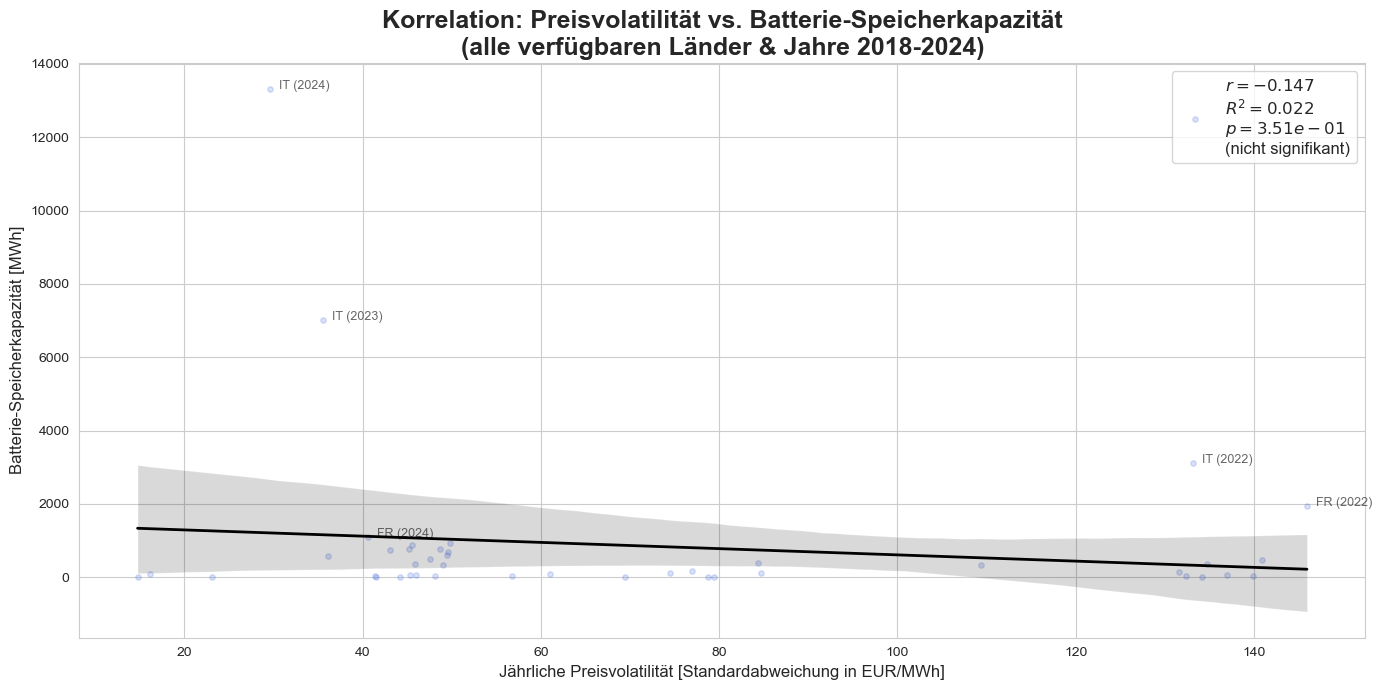

Anzahl der verwendeten Datenpunkte: 42


In [105]:
# Daten zusammenführen (Verwendung des market_df für die jährliche Volatilität)
analysis_df = pd.merge(market_df, batteries_final_df, on=['Land_Code', 'Year'])

# Nur Datenpunkte mit Batterie-Werten > 0 verwenden
plot_df = analysis_df[analysis_df['Battery_Storage_MWh'] > 0].copy()

# Lineare Regression berechnen
slope, intercept, r_val, p_val, std_err = stats.linregress(plot_df['Yearly_Vola'], plot_df['Battery_Storage_MWh'])

# Visualisierung
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dynamische Abfrage der Signifikanz
sig_text = "hochsignifikant" if p_val < 0.001 else "signifikant" if p_val < 0.05 else "nicht signifikant"

# Scatterplot mi Regressionslinie, Label: r, R², p
ax = sns.regplot(data=plot_df, x='Yearly_Vola', y='Battery_Storage_MWh',
                 scatter_kws={'alpha':0.2, 's':15, 'color':'royalblue'},
                 label=f'$r = {r_val:.3f}$\n$R^2 = {r_val**2:.3f}$\n$p = {p_val:.2e}$\n({sig_text})',
                 line_kws={'color': 'black', 'lw': 2, 'zorder': 4})

# Beschriftung der Ausreißer
for i in range(plot_df.shape[0]):
    if plot_df.iloc[i]['Battery_Storage_MWh'] > plot_df['Battery_Storage_MWh'].quantile(0.9):
        plt.text(plot_df.iloc[i]['Yearly_Vola'] + 1, 
                 plot_df.iloc[i]['Battery_Storage_MWh'], 
                 f"{plot_df.iloc[i]['Land_Code']} ({plot_df.iloc[i]['Year']})", 
                 fontsize=9, alpha=0.7)

# Achsen und Titel
plt.title('Korrelation: Preisvolatilität vs. Batterie-Speicherkapazität\n(alle verfügbaren Länder & Jahre 2018-2024)', fontsize=18, fontweight='bold')
plt.xlabel('Jährliche Preisvolatilität [Standardabweichung in EUR/MWh]', fontsize=12)
plt.ylabel('Batterie-Speicherkapazität [MWh]', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Kurze Ergebnisausgabe
print(f"Anzahl der verwendeten Datenpunkte: {len(plot_df)}")

**Analyse der Korrelation zwischen der Batteriespeicherkapazität und der Strompreis-Volatilität:**
- Die Korrelation ist nicht signifikant
- Die Korrelation ist leicht negativ, mit steigender Volatilität sinkt die Batterie-Speicherkapazität
- Jedoch ist das Bestimmtheißtsmaß (R²) mit 0,022 extrem niedrig: die Volatilität erklärt fast nichts von der Batteriespeicherkapazität
<br>

<u>Zusammenfassung:</u>
- Das Ergebnis ist nicht signifkant, aufgrund dessen sind keine statistisch belastbaren Aussagen über den Einfluss der Volatilität auf den Batteriespeicherausbau möglich

Am Beispiel Italien ist auch der in Kapitel 3.1 analysierte zeitliche Verlauf der Volatilität gut zu erkennen: die Volatilität ging von 2022 - 2024 im Jahresdurchschnitt stark zurück, der Punkt "IT" läuft von rechts nach links. Gleichzeitig hat sich der Ausbau der Batterie-Speicherkapazität in Italien stark erhöht, dadurch läuft der Punkt von unten nach oben.

### 5.3.2 Korrelation Batteriespeicherkapazität - Volatilität: time-lag-Analyse

Die vorherige Analyse untersucht einen unmittelbaren zeitlichen Zusammenhang zwischen der Volatilität und der Batteriespeicherkapazität.  
Da Batteriespeicher jedoch von der Planung, Projektierung, Installation und Inbetriebnahme mehrere Jahre benötigen, wird im Folgenden untersucht, ob eine höhere Preisvolatilität einen Impuls für einen stärkeren Ausbau der Speicherkapazität in der Zukunft ergibt.  

Dafür werden die Volatilitäten zwei Jahre in die Zukunft verschoben, um zu überprüfen, ob die Volatilität im Jahr t (z.B. 2022) mit der Speicherkapazität von t + 2 Jahren (z.B. 2024) korrelieren:

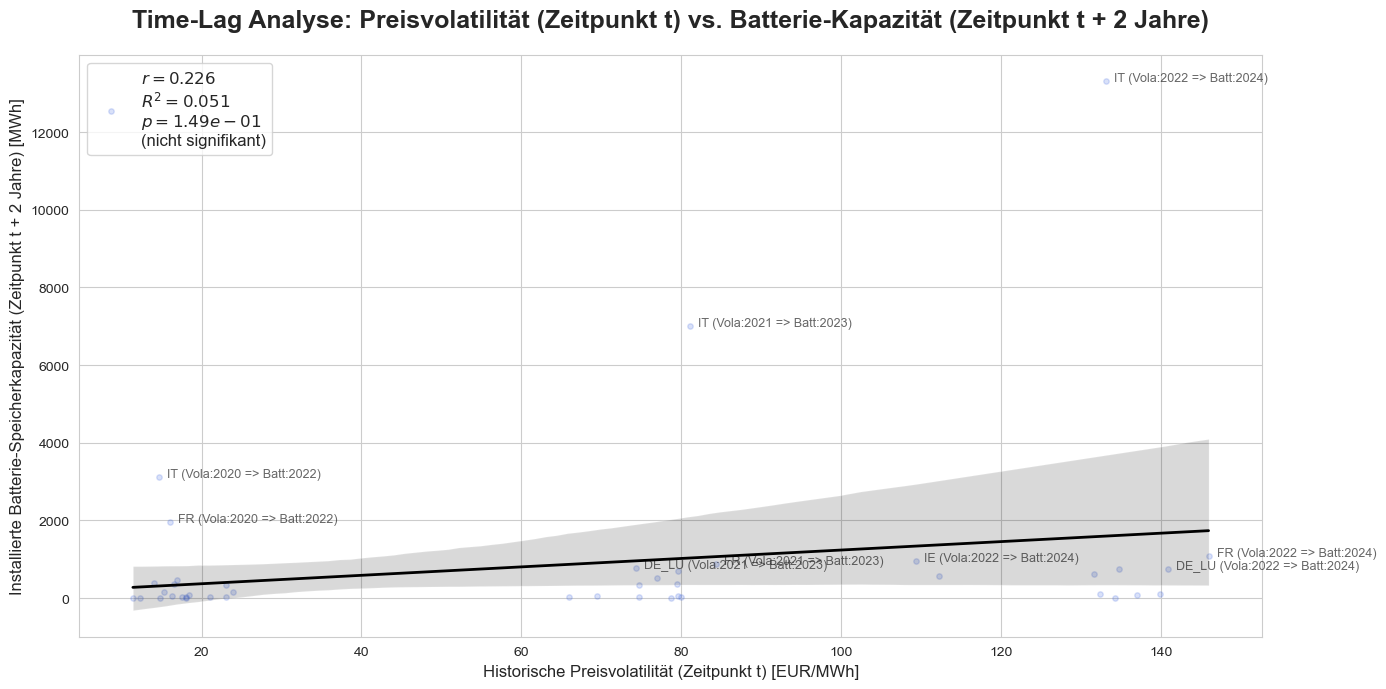

Anzahl der Datenpunkte in der Time-Lag-Analyse: 42


In [106]:
# Vorbereitung des time-lags
market_lagged_df = market_df.copy()
# Addition von 2 Jahren auf das Jahr der Volatilität, um es mit zukünftigen Batteriewerten zu matchen
market_lagged_df['Year_for_Match'] = market_lagged_df['Year'] + 2

# Merge der Volatilität (t) mit Batterispeicherkapaztität (t+2): Matchen von Year_for_Match aus den Preisen mit Year aus den Batteriedaten
lag_analysis_df = pd.merge(
    market_lagged_df, 
    batteries_final_df, 
    left_on=['Land_Code', 'Year_for_Match'], 
    right_on=['Land_Code', 'Year'],
    suffixes=('_vola_origin', '_battery_year')
)

# Nur Datenpunkte mit Batterie-Werten > 0 verwenden
plot_lag_df = lag_analysis_df[lag_analysis_df['Battery_Storage_MWh'] > 0].copy()

# Lineare Regression berechnen: x = Volatilität von vor 2 Jahren, y = Kapazität heute
slope, intercept, r_val, p_val, std_err = stats.linregress(plot_lag_df['Yearly_Vola'], plot_lag_df['Battery_Storage_MWh'])

# Visualisierung
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dynamische Abfrage der Signifikanz
sig_text = "hochsignifikant" if p_val < 0.001 else "signifikant" if p_val < 0.05 else "nicht signifikant"

# Scatterplot mi Regressionslinie, Label: r, R², p
sns.regplot(data=plot_lag_df, x='Yearly_Vola', y='Battery_Storage_MWh',
            scatter_kws={'alpha':0.2, 's':15, 'color':'royalblue'},
            label=f'$r = {r_val:.3f}$\n$R^2 = {r_val**2:.3f}$\n$p = {p_val:.2e}$\n({sig_text})',
            line_kws={'color': 'black', 'lw': 2, 'zorder': 4})

# Beschriftung zur Verdeutlichung des Lags
for i in range(plot_lag_df.shape[0]):
    label = f"{plot_lag_df.iloc[i]['Land_Code']} (Vola:{int(plot_lag_df.iloc[i]['Year_vola_origin'])} => Batt:{int(plot_lag_df.iloc[i]['Year_battery_year'])})"
    if plot_lag_df.iloc[i]['Battery_Storage_MWh'] > plot_lag_df['Battery_Storage_MWh'].quantile(0.8):
        plt.text(plot_lag_df.iloc[i]['Yearly_Vola'] + 1, 
                 plot_lag_df.iloc[i]['Battery_Storage_MWh'], 
                 label, fontsize=9, alpha=0.7)

# Achsen und Titel
plt.title('Time-Lag Analyse: Preisvolatilität (Zeitpunkt t) vs. Batterie-Kapazität (Zeitpunkt t + 2 Jahre)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Historische Preisvolatilität (Zeitpunkt t) [EUR/MWh]', fontsize=12)
plt.ylabel('Installierte Batterie-Speicherkapazität (Zeitpunkt t + 2 Jahre) [MWh]', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Kurze Ergebnisausgabe
print(f"Anzahl der Datenpunkte in der Time-Lag-Analyse: {len(plot_lag_df)}")

**Analyse der Korrelation zwischen der Batteriespeicherkapazität und der Strompreis-Volatilität mit einem time-lag von 2 Jahren:**
- Die Korrelation ist weiterhin nicht signifikant, wenngleich sich der Wert ggü. der ursprünglichen Korrelationsanalyse (ohne time-lag) deutlich verbessert hat
- Die Korrelation ist nun jedoch leicht positiv, mit steigender Volatilität steigt die Batterie-Speicherkapazität, dies macht aus technisch-wirtschaftlicher Sicht nun Sinn: da Batteriespeicher Strom zu niedrigen Preisen aufnehmen und zu hohen Preisen abgeben können, ist dies bei einer höheren Volatilität einfacher möglich bzw. rentabler
- Jedoch ist das Bestimmtheißtsmaß (R²) mit 0,051 weiter sehr niedrig: die Volatilität erklärt weiterhin fast nichts von der Batteriespeicherkapazität
<br>

<u>Zusammenfassung:</u>
- Das Ergebnis ist nicht signifkant, aufgrund dessen sind keine statistisch belastbaren Aussagen über den Einfluss der Volatilität auf den Batteriespeicherausbau möglich

**Erweiterte time-lag-Analyse:**  

Um zu untersuchen, ob eine statistisch aussagekräftige Korrelation bei einem Zeitverzug größer als 2 Jahre zu erkennen ist, wird eine Tabelle erstellt mit einem Zeitverzug von 0-5 Jahren erstellt:

In [107]:
# Ergebnisliste vorbereiten
lag_results = []

# Schleife über die gewünschten Lags
for lag in [0, 1, 2, 3, 4, 5]:
    # Markt-Daten kopieren und Jahr verschieben
    temp_market_df = market_df.copy()
    temp_market_df['Year_for_Match'] = temp_market_df['Year'] + lag
    
    # Merge mit Batteriedaten
    merged_df = pd.merge(
        temp_market_df, 
        batteries_final_df, 
        left_on=['Land_Code', 'Year_for_Match'], 
        right_on=['Land_Code', 'Year']
    )
    
    # Nur Datenpunkte mit Batterie-Werten > 0 verwenden
    clean_df = merged_df[merged_df['Battery_Storage_MWh'] > 0].copy()
    
    # Statistik berechnen, falls genug Datenpunkte vorhanden sind (mind. 3)
    if len(clean_df) > 2:
        slope, intercept, r_val, p_val, std_err = stats.linregress(clean_df['Yearly_Vola'], clean_df['Battery_Storage_MWh'])
        
        lag_results.append({
            'Time-Lag (Jahre)': lag,
            'R²': round(r_val**2, 4),
            'p-Wert': round(p_val, 4),
            'Signifikant (<0.05)': "Ja" if p_val < 0.05 else "Nein",
            'Datenpunkte (N)': len(clean_df)
        })
    else:
        lag_results.append({
            'Time-Lag (Jahre)': lag,
            'R²': "N/A", 'p-Wert': "N/A", 'Signifikant (<0.05)': "N/A", 'Datenpunkte (N)': len(clean_df)
        })

# In DataFrame umwandeln
lag_matrix = pd.DataFrame(lag_results)

# Matrix anzeigen
print("Übersicht der Korrelationen nach Zeitversatz:")
print()
display(lag_matrix)

Übersicht der Korrelationen nach Zeitversatz:



,Time-Lag (Jahre),R²,p-Wert,Signifikant (<0.05),Datenpunkte (N)
0,0,0.0218,0.3513,Nein,42
1,1,0.0002,0.9320,Nein,42
2,2,0.0513,0.1492,Nein,42
3,3,0.0349,0.2551,Nein,39
4,4,0.0265,0.3499,Nein,35
5,5,0.0101,0.6404,Nein,24


**Analyse der erweiterten time-lag-Analyse:**  

Für alle gewählten Intervalle des Zeitverzugs ist das Ergebnis deutlich nicht signifikant.  

Da die Volatilität demnach als Ursache für den Speicherausbau ausgeschlossen werden kann, muss dieser von anderen Faktoren wie politischen/regulatorischen und anderen wirtschaftlichen Rahmenbedingungen bestimmt werden.

Eine weiterführende, tiefgreifendere Analyse kann unter Umständen zu statistisch signifikanten Aussagen kommen. Dafür müssten die Lücken (Länder & Jahre) in der Datenbasis durch eine manuelle Datenrecherche geschlossen werden. Zudem könnte eine Bereinigung von politischen/regulatorischen Effekten auf den Batteriespeicherausbau (welche nicht in Zusammenhang mit der Volatilität der Strompreise stehen) die Datenqualität erhöhen und damit die Ergebnisqualität erhöhen.

## 5.4 Multivariate Korrelationsanalyse mit Excel

Bisher wurden die Auswirkungen der Variablen auf den Strompreis/Volatilität einzeln untersucht (z.B. Erzeugung RE/VRE; Wärmepumpen/Elektroautos).  
  
Um eine Analyse dieser 4 Variablen auf den Strompreis und die Volatilität durchzuführen, wird eine multivariate Regressionsanalyse erstellt. Dazu werden diese Variablen sowie der Strompreis und die Volatilität in einer Tabelle zusammen geführt und in eine Excel-Datei exportiert.  

Die multivariate Regressionsanalyse erfolgt abschließend in Excel.

In [108]:
# Nutzung des master_df, da dieser bereits Land, Jahr, Strompreis und WP/EV pro Jahr enthält
excel_final_df = master_df[[
    'Land_Code', 
    'Year', 
    'Price_Avg',
    'Vol_Hourly',
    'RE_Share_Avg',
    'VRE_Share_Avg',
    'HP_Value_MWh_Pop',
    'EV_Count_Total_Pop'
]].copy()

# Umbenennung der Variablen
excel_final_df.columns = ['Land_Code', 'Year', 'Strompreis_EUR_MWh', 'Vola_stündlich', 'RE_Anteil_Pct', 'VRE_Anteil_Pct', 'WP_pro_1k_EW', 'EV_pro_1k_EW']

# Sortierung
excel_final_df = excel_final_df.sort_values(by=['Land_Code', 'Year'])

# Export in Excel
file_name = "Regression_Daten_Abschlussarbeit_Final.xlsx"
excel_final_df.to_excel(file_name, index=False)

print(f"✅ Datei '{file_name}' wurde erstellt.")
print(f"Stichprobengröße: {len(excel_final_df)} Zeilen (Ziel: 147).")

excel_final_df.head()

✅ Datei 'Regression_Daten_Abschlussarbeit_Final.xlsx' wurde erstellt.
Stichprobengröße: 133 Zeilen (Ziel: 147).


,Land_Code,Year,Strompreis_EUR_MWh,Vola_stündlich,RE_Anteil_Pct,VRE_Anteil_Pct,WP_pro_1k_EW,EV_pro_1k_EW
0,AT,2018,46.313802,18.048418,69.220826,13.817291,440.382525,2.361184
19,AT,2019,40.136805,12.247705,66.626238,13.847868,490.221309,3.332628
38,AT,2020,33.096157,14.756915,70.582444,13.053279,526.923648,5.000189
57,AT,2021,108.590939,78.749401,68.796342,13.563323,574.438283,8.568441
76,AT,2022,264.405037,134.186412,67.329696,14.390583,629.835510,12.275963


# 6. Beantwortung der Fragestellungen

## 6.1 Einschränkungen der Analyse:

**Einschränkungen aufgrund der Datenqualität:**
- Die regionale sowie zeitliche Datenverfügbarkeit ist eingeschränkt: vor allem die EUROSTAT-Datensätze (Wärmepumpen, Elektroautos) weisen teilweise große Lücken auf, woraus sich ein einheitlicher Datensatz von nur 19 Ländern für die 7 Jahre von 2018-2024 ergibt
- Die Daten zu (variablen) erneuerbaren Energien und Wärmpumpen stellen die Erzeugungsleistung bzw. die aufgenommen Energie dar: diese Größen werden nicht nur durch die Größe des Bestandes bestimmt, sondern auch durch Umweltfaktoren (Sonnenscheindauer, Windaufkommen, Niederschlag, Temperaturen/Heizbedarf), welche nur mit zusätzlichen Datenquellen unter großem Aufwand voneinander getrennt werden können
<br>

**Einschränkungen aufgrund des regulatorischen Umfelds:**
- Sämtliche Daten werden stark von der Politik und dem sich daraus ergebenden regulatorischen Umfeld geprägt: Strompreis (Besteuerung, Umlage von Infrastrukturkosten etc.), Ausbau RE/VRE, WP/EV (Förderprogramme, steuerliche Begünstigungen etc.)
- Dadurch können technische und marktwirtschaftliche Faktoren abgeschwächt bzw. aufgehoben werden

## 6.2 Fragen im Bereich Marktsegmentierung:

*- Wie lassen sich die Strommärkte der verschiedenen Ländern in Cluster einteilen?*

*- Lassen sich Länder mit ähnlichen Transformationsmustern identifizieren?*

Zur Beantwortung der Fragen im Bereich der Marktsegmentierung wurden für die verschiedenen Variablen (Strompreis, Erzeugung, Elektrifizierung) sowohl die Bestandssituation als auch die Wachstumstrajektorie betrachtet.  
Die Fragen werden demnach im Folgenden ebenso in diese 2 Kategorien gesplittet beantwortet: 

### 6.2.1 Bestands-Situation

**Strompreis-Cluster:**
- Die niedrigsten Strompreise weisen die 3 nordischen Länder Schweden, Norwegen und Finnland auf, gefolgt von Frankreich und Spanien
- Die höchsten Strompreise weisen die Länder Irland, Italien, Ungarn, Polen und Kroatien auf

<br> 

**Erzeugungs-Cluster: RE/VRE**
- Die höchste Erzeugung erneuerbarer Energien (RE) weisen Norwegen, Österreich, Lettland, Kroatien und Portugal auf
- Die höchste Erzeugung variabler erneuerbarer Energien (VRE) weisen Litauen, Irland, Deutschland/Luxemburg, Portugal und Spanien auf
- Daraus ergibt sich kombiniert die höchste Erzeugungsquote an allen erneuerbaren Energien für Norwegen, Österreich, Portugal und Litauen
<br> 

- Die niedrigste Erzeugung erneuerbarer Energien (RE) weisen die Niederlande, Polen, Irland, Ungarn und Belgien auf
- Die niedrigste Erzeugung variabler erneuerbarer Energien (VRE) weisen Slowakei, Slowenien, Norwegen, Frankreich und Ungarn auf
- Daraus ergibt sich kombiniert die niedrigste Erzeugungsquote an allen erneuerbaren Energien für Ungarn, Niederlande, Slowakei, Frankreich und Polen
<br>

**Elektrifizierungs-Cluster: WP/EV**
- Die höchste Wärmepumpendichte weisen die 3 nordischen Länder Norwegen, Schweden und Finnland auf, gefolgt im großen Abstand von Österreich, Portugal und Frankreich
- Die niedrigste Wärmepumpendichte weisen Lettland, Kroatien, Ungarn, Polen und Irland auf
<br>

- Die höchste Elektroautodichte weist mit großem Abstand Norwegen auf, gefolgt mit großem Abstand von Schweden, den Niederlanden und Belgien
- Die niedrigste Elektroautodichte weisen Polen, Kroatien, Slowakei, Spanien und Italien auf
  
<br>
<br>

**Im Bestand ergeben sich damit 2 Cluster:**

<u>Führende Länder:</u>
- Die Top-Nationen werden von den nordischen Länder Norwegen, Schweden und Finnland dominiert, zudem von Österreich, Portugal und Litauen
- Norwegen stellt innerhalb dieser Gruppe einen Sonderfall dar: dieses Land führt in fast allen Kategorien (ausgenommen VRE und Strompreis) die Länderliste an
- Dies ist auf seine Topograhie zurück zu führen, welches einen extrem hohen Wasserkraftanteil ermöglicht, womit die Elektrifizierung von Mobilität und Wärme vorangetrieben wurde
- Gleichermaßen - wenn auch weniger stark ausgeprägt - trifft dies auf Österreich zu
- Portugal profiertiert ebenfalls von seiner südlichen Küstenlage, die einen hohen RE- und VRE-Anteil an der Gesamtstromerzeugung ermöglicht, zudem weist Portugal einen relativ niedrigen Strompreis sowie gute Positionierungen bei den Wärmepumpen und Elektroautos auf
- Litauen wiederum profitiert von seiner Küstenlage, welche den höchsten VRE-Anteil (Windkraft) ermöglicht

<br>

<u>Schwächste Länder:</u>
- Am anderen Ende der Skala befinden sich ausschließlich Länder Ost-Mitteleuropas: Slowenien, Kroatien, Polen, Ungarn und die Slowakei
- Sie weisen niedrige bis sehr niedrige RE- und VRE-Anteile und Wärmepumpen/EV-Durchdringung auf, zudem ist der Strompreis sehr hoch

<br>

<u>Abstand der Cluster:</u>
- Die Unterschiede und damit der Abstand zwischen den Clustern sind sehr groß: der Unterschied von minimalem zu maximalem RE- als auch VRE-Anteil ist ein Faktor von fast 30
- Noch stärker sind die Unterschiede bei der Elektrifizierung: Hier ist die Verteilung noch rechtsschiefer und von den positiven Ausreißern dominiert, der Faktor Min.-Max. beträgt bei WP über 100, bei den EV ca. 80

### 6.2.2 Wachstums-Situation

**Erzeugungs-Cluster: RE/VRE**
- Das höchste Wachstum der Erzeugung erneuerbarer Energien (RE) weisen Kroatien und die Niederlande auf
- Das höchste Wachstum der Erzeugung variabler erneuerbarer Energien (VRE) weisen Ungarn und Lettland auf
- Daraus ergibt sich kombiniert das höchste Wachstum an allen erneuerbaren Energien für Ungarn, Lettland und die Niederlande
<br> 

- Das niedrigste Wachstum der Erzeugung erneuerbarer Energien (RE) weisen Belgien und Irland auf
- Das niedrigste Wachstum der Erzeugung variabler erneuerbarer Energien (VRE) weisen Kroatien, die Slowakei, Irland und Deutschland/Luxemburg auf
- Daraus ergibt sich kombiniert das niedrigste Wachstum an allen erneuerbaren Energien für Irland, Deutschlannd/Luxemburg, Slowakei, Belgien und Kroatien

<br>

**Elektrifizierungs-Cluster: WP/EV**
- Das höchste Wachstum der Wärmepumpendichte weisen Ungarn, Litauen, Slowakei, Lettland auf
- Das niedrigste Wachstum der Wärmepumpendichte weisen Kroatien, Portugal, Schweden, Italien und Norwegen auf

<br>

- Das höchste Wachstum der Elektroautodichte weisen Finnland und Belgien auf
- Das niedrigste Wachstum der Elektroautodichte weisen Norwegen, Österreich und Frankreich auf
  
<br>
<br>

**In der Betrachtung der Wachstumssituation ergeben sich damit 2 Cluster:**

<u>Führende Länder:</u>
- Gesamtranking: Polen, Lettland, Litauen, Ungarn, Niederlande
- Polen weist durchweg durch alle Kategorien gute bis sehr gute Werte auf, wodurch es insgesamt auf den Spitzenplatz kommt
- Ungarn ist der aktuelle Spitzenreiter im VRE- und Wärmepumpen-Wachstum, das EV-Wachstum ist aber nur durchschnittlich

<br>

<u>Schwächste Länder:</u>
- Gesamtranking: Norwegen, Deutschland/Luxemburg, Irland, Österreich und Frankreich
- Am anderen Ende der Skala befindet sich Norwegen, dass wie bereits beschrieben in der Transformation schon sehr weit vorangeschritten ist. Daher sind die Wachstumsraten fast durchgängig sehr gering. Eine Ausnahme ist das VRE-Wachstum: Dies legt die Vermutung nahe, dass das Wasserkraftpotential ausgeschöpft ist, und Norwegen versucht durch die Installation von VRE (ausschließlich Windkraft) die Dekarbonisierung des Stromsektors trotzdem weiter zu führen.
- Deutschland ist auf dem vorletzten Platz, was belegt, dass die bis vor einigen Jahren in der Öffentlichkeit als "Klimavorreiter" bezeichnete Rolle Deutschlands nicht mehr gilt

<br>

<u>Abstand/Verteilung der Cluster:</u>
- Auffällig ist die Verteilung der Wachstumsraten: während die maximale RE-Wachstumsrate bei ca. 15% liegt, sind es bei den VRE knapp 50%
- 50% der Länder weisen ein VRE-Wachstum von 6-25% auf (2018-2024), was einem Faktor von ca. 4 entspricht. Ein Min.-Max.Faktor ist aufgrund des negativen Wachstums der Minimalwerte nicht sinnvoll
- Damit ist das VRE-Wachstum sowohl deutlich höher und weist auch eine breitere Verteilung auf als das RE-Wachstum, dort befinden sich 50% der Länder zwischen 0,6-4,6%
- Das Wärmepumpenwachstum ist mit einem Min.-Max.-Faktor von 45 deutlich breiter verteilt als das Elektroautowachstum mit lediglich 3,5
- Dies entspricht dem erkannten Muster im Bestand, dass die Verteilung des Wärmepumpenbestandes höher ist als die des Elektroautobestandes, wenngleich der Unterschied bei den Wachstumsraten deutlich größer ist

### 6.2.3. Zusammenfassung Marktsegmentierung

*- Wie lassen sich die Strommärkte der verschiedenen Ländern in Cluster einteilen?*  
*- Lassen sich Länder mit ähnlichen Transformationsmustern identifizieren?*
<br>


<br>
Die Beantwortung dieser Fragen ist direkt miteinander verbunden:  
<br>
<br>

**Die Einteilung der Länder in Cluster ist deutlich anhand der Position auf der Zeitachse im Transformationsprozess möglich:**

1) Länder mit hohen Bestandswerten weisen tendenziell  niedrige Wachstumsraten auf: die Basis/der Bestand ist schon sehr hoch, was hohe Wachstumsraten erschwert, zudem kann der Bestand auch maximal auf 100% ansteigen. Da die rentabelsten und einfachsten Anwendungsfälle zu Beginn umgesetzt werden, wird das Wachstum mit zunehmdem Bestand immer schwieriger
2) Länder mit niedrigen Bestandwerten weisen tendenziell hohe Wachstumsraten auf: die Basis/der Bestand ist noch niedrig, was höhere Wachstumsraten ermöglicht. Diese Länder können zudem von den Erfahrungswerten von im Transformationsprozess weiter vorangeschrittenen Ländern profitieren und den technologischen Fortschritt nutzen (z.B. der enorme Kostenrückgang für PV-Module, Batterien etc. über die letzten Jahrzehnte)
<br>
 

In der **Kategorie 1** (hoher Bestand, niedriges Wachstum) befinden sich die Länder die im Transformationsprozess sehr weit vorangschritten sind:
- Dies sind vor allem die nordischen Länder, angeführt von Norwegen
- Beim absoluten Spitzenreiter Norwegen ist dies durch die Geographie und Topographie zu erklären: die nördliche Lage macht zwar Solarkraftwerke unrentabel, allerdings ermöglicht die Topographie ein sehr hohes Wasserkraftpotential (ähnlich wie Österreich). Dadurch weist es den Spitzenplatz beim RE-Anteil auf, der VRE-Anteil ist jedoch sehr gering
- Die hohe Wasserkrafterzeugung, kombiniert mit einem niedrigen Strompreis ermöglicht eine tiefgreifende Elektrifizierung und führt zu einem sehr hohen Elektroauto- und Wärmepumpenbestand
- Das Wachstum ist demnach entsprechend sehr niedrig, die Transformation ist fast vollständig
- Das dies nicht ausschließlich auf Länder mit günstigen Standortfaktoren beschränkt ist zeigen die beiden anderen nordischen Länder Schweden und Finnland: diese sind im Transformationsprozess ebenfalls weit vorangeschritten, ohne eine ähnliches Wasserkraftpotential wie Norwegen aufzuweisen
<br>


In der **Kategorie 2** (niedriger Bestand, hohes Wachstum) befinden sich die Länder, die im Transformationsprozess noch nicht weit vorangschritten sind und entsprechend im Aufholprozess sind:
- Dies sind v.a. die Länder Osteuropas inkl. der baltischen Staaten
- Polen weist durchweg durch alle Kategorien gute bis sehr gute Werte auf, ohne in einzelnen Kategorien zu den absoluten Spitzenreitern zu gehören, in Summe jedoch erreicht es den Spitzenplatz
- Dies ist ein Anzeichen dafür, dass Länder auch ohne spezielle Voraussetzungen (Wasserkraftpotential durch die Topographie, PV-Potential durch südliche Lage, Windkraftpotential durch Lage an windreicher Küste) im Transformationsprozess erfolgreich sein können
- So teilen sich die Spitzenreiter in der Kategorie 2 auf die verschiedenen Variablen auf, ohne das ein Land in allen Kategorien führend wäre (wie es bei Norwegen in der Bestandssituation der Fall ist)
- Kroatien hat ein gutes RE- und EV-Wachstum, die Slowakei sehr hohes RE- und WP-Wachstum und Ungarn ist der aktuelle Spitenreiter im VRE- und WP-Wachstum

## 6.3 Technologische Fragestellungen:

*- Erzeugerseite: Gibt es einen Einfluss von erneuerbaren Energien / variablen erneuerbaren Energien auf den Strompreis und dessen Volatilität?*

Die Ergebnisse sind zwar hochsignifikant (Ausnahme: VRE-Anteil vs. Strompreis), aufgrund des sehr geringen Bestimmheitsmaßes (R²) stind jedoch keine statistisch belastbaren Aussagen über den Einfluss des RE- und VRE-Anteils auf den Strompreis und die Volatilität möglich.

*- Verbraucherseite: Gibt es einen Einfluss von Wärmepumpen/Elektroautos auf den Strompreis und dessen Volatilität?*

Die Ergebnisse sind nicht signifikant, zusammen mit den zudem sehr geringen Bestimmheitsmaßen (R²) sind deshalb keine statistisch belastbaren Aussagen über den Einfluss von Wärmepumpen und Elektroautos auf den Strompreis und die Volatilität möglich

*- Ausgleich zwischen Erzeuger- und Verbraucherseite: Führt eine höhere Strompreisvolatilität zu einer vermehrten Nutzung von Batteriespeichern?*

Das Ergebnis ist nicht signifkant, aufgrund dessen sind keine statistisch belastbaren Aussagen über den Einfluss der Volatilität auf den Batteriespeicherausbau möglich. Auch bei einer Variation des Zeitverzuges zwischen Volatilität und Batteriespeicherausbau von bis zu 5 Jahren sind die Ergebnisse deutlich nicht signifikant.

## 6.4 Weiterführende Forschungsfragen:

**Validierung der bisherigen Forschungsfragen:**
- Sind durch eine Erweiterung des zeitlichen und regionalen Datenumfangs (nach Möglichkeit auf alle EU27 Länder, ggf. Großbritannien und die Schweiz und auf ein möglichst langes Zeitintervall) robustere statistische Aussagen möglich?
- Sind durch eine analoge Anwendung aller durchgeführten Analysemethoden auf alle Einzelländer solche zu identifizieren, in denen sich statistisch signifikante Zusammenhänge ergeben? Wenn ja, woran liegt dies in diesen Ländern und lassen sich diese Gegebenheiten ggf. auf andere Länder übertragen?
<br>

**Abgewandelte Forschungsfragen:**

- Andere Gründe für den unterschiedlichen Transformationsgrad in der Elektrifizierung: Ist der Elektroauto-/Wärmepumpenanteil abhängig vom Anteil der erneuerbaren Energien an der Gesamtstromerzeugung?
- Lässt sich der Strompreis bzw. dessen Volatilität durch die Anzahl/Anteil der Negativstunden in einem Land erklären?
- Ist die Anzahl der Negativstunden des Strompreises wiederum abhängig von dem Anteil der variablen erneuerbaren Energien an der Gesamtstromerzeugung?
- Kann der Batteriespeicherausbau mit der Entwicklung des Strompreises erklärt werden?

# 7. Management Summary

**Ergebnisse Marktsegmentierung:**  
- Die untersuchten 18 EU-Länder und Norwegen differenzieren sich deutlich anhand ihres Transformationsfortschritts (hin zu einer Energieerzeugung aus erneuerbaren Energien sowie Elektrifizierung von Wärme und Mobilität)
- Durch die großen Unterschiede in fast allen untersuchten Kategorien lassen sich die Länder in die folgenden beiden Cluster einteilen:
  - "Transformations-Vorreiter": Dies sind die Länder, die im Transformationsprozess schon weit vorangeschritten sind, sie weisen generell hohe Bestandswerte (Stromerzeugung aus erneuerbaren Energien, Wärmpumpen, Elektroautos) und niedrige Wachstumsraten in diesen Kategorien auf. Dies sind v.a. die nordischen Länder.
  - "Transformations-Aufholer": Diese Länder befinden sich im Aufholprozess, haben niedrige Bestandswerte aber tendenziell hohe Wachstumsraten. Dies sind v.a. Länder Osteuropas sowie des Baltikums.

<br>

**Ergebnisse technologische Fragestellungen:**
- Es gibt keinen statistisch nachweisbaren Einfluss der Stromerzeugung aus erneuerbaren Energien auf den Strompreis und seine Volatilität.
- Es gibt keinen statistisch nachweisbaren Einfluss der Nutzung von Wärmepumpen und Elektroautos auf den Strompreis und seine Volatilität.
- Zudem erklärt die Volatilität nicht die Entwicklung des Batteriespeicherausbaus. 

Die Ergebnisse sind zudem übersichtlich und interaktiv in PowerBI visualisiert.